# Setup

In [1]:
import os
import sys

import numpy

# Add OpenBLAS bin to the beginning of the PATH
os.environ["PATH"] = r"C:\TopoGAN-ECCV2020\OpenBLAS\bin;" + os.environ.get("PATH", "")

# # 1) register the folder that contains _persis_homo_optimal.pyd *and* any other DLLs it needs
# os.add_dll_directory(r"C:\Users\MIKEC\PycharmProjects\topology\TopoGAN-ECCV2020\persis_lib_cpp")

# 2) add the same folder to sys.path so Python can find the .pyd module by name
# sys.path.insert(0, r"C:\Users\MIKEC\PycharmProjects\topology\TopoGAN-ECCV2020\persis_lib_cpp")

# python library compile from cpp
sys.path.insert(0, "./persis_lib_cpp")
import os

from persis_homo_optimal import *

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
TOPOLOGICAL_GAN = True
START_TOPO_LOSS_FROM_EPOCH = -1

%run Archpool.ipynb
%run Argparser.ipynb
%run GAN.ipynb


def precompute_pds(dir_in, dir_out):
    adv_params = return_advanced_params()
    et = Edges_(adv_params, False)
    FileIO.compute_pd_save(dir_in, dir_out, "png", adv_params, 1, True)


settings = return_settings()

raw_data_path, pds_path = settings["Path"]["data_path"], settings["Path"]["pds_path"]
if not os.path.exists(pds_path):
    print("Precomputing pds")  # PDs - Persistence Diagrams

    print(raw_data_path, "\n", pds_path)
    precompute_pds(raw_data_path, pds_path)

In [2]:
HOME_DIR = "C:\TopoGAN-ECCV2020"

In [3]:
parser = Argparser(settings)
general = return_general(0)
G_arch = return_arch(2)  # DCGAN
D_arch = return_arch(3)  # DCGAN
data_params = return_data_settings(0)
adv_params = return_advanced_params()

print("TRAINING ON DATASET: ", settings["Path"]["data_path"])

TRAINING ON DATASET:  C:\TopoGAN-ECCV2020\Data\cremi\64x64small


In [4]:
import json
import os
from datetime import datetime
from pathlib import Path

# Get the filename: YYYY-MM-DD_branchname.json
date_str = datetime.now().strftime("%Y-%m-%d")
branch_name = settings["Basic"]["branch_name"]
filename = f"{date_str}_{branch_name}.json"

# Full save path
save_dir = Path(settings["Path"]["save_path"]) / branch_name
os.makedirs(save_dir, exist_ok=True)
save_file_path = os.path.join(save_dir, filename)

# Assemble the full run config
run_config = {
    #     "args": vars(parser),
    "settings": settings,
    "general": general,
    "generator_arch": G_arch,
    "discriminator_arch": D_arch,
    "data_params": data_params,
    "advanced_params": adv_params,
}

# Save to JSON
with open(save_file_path, "w") as f:
    json.dump(run_config, f, indent=4)

print(f"✅ Run configuration saved to: {save_file_path}")

✅ Run configuration saved to: C:\TopoGAN-ECCV2020\Data\LOG\cremi_20250528_120703_64x64small\2025-05-28_cremi_20250528_120703_64x64small.json


In [5]:
def compute_fid(paths, batch_size=50, dims=2048):
    """
    reference: https://github.com/mseitzer/pytorch-fid
    dims choices: 64, 192, 768, 2048
    lower score means better quality
    paths: [folderA, folderB]
    """
    %run fid/inception.ipynb
    %run fid/fid_score.ipynb

    os.environ["CUDA_VISIBLE_DEVICES"] = "0"
    fid_value = calculate_fid_given_paths(paths, batch_size, True, dims)
    print("FID: ", fid_value)


def run(gan):
    gan.train(
        data_params,
        withTopo=TOPOLOGICAL_GAN,
        add_topo_at_epoch=START_TOPO_LOSS_FROM_EPOCH,
    )
    # gan.sample_save_("20000_128_1_1_0.dat", [20000, 128, 1, 1], "D:/Data/isbi/2w/compare_SN0", 127.5, 0)
    # gan.save_noise_([20000, 128, 1, 1], "20000_128_1_1_2.dat")


#     print("Precomputing pds") # PDs - Persistence Diagrams
#     precompute_pds(r"C:\TopoGAN-ECCV2020\Data\cremi\64x64", r"C:\TopoGAN-ECCV2020\Data\cremi\pds_64x64")


def train():
    gan = GAN(general, adv_params, G_arch, D_arch)
    start_time = time.time()
    try:
        print(
            "TOPOLOGICAL_GAN:",
            TOPOLOGICAL_GAN,
            "starting from epoch",
            START_TOPO_LOSS_FROM_EPOCH,
        )
        run(gan)
    finally:
        end_time = time.time()
        elapsed_time = end_time - start_time
        hours, rem = divmod(elapsed_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"Execution time: {int(hours):02d}:{int(minutes):02d}:{seconds:06.3f}")
        #     precompute_pds('E:/Data/cremi', 'E:/Data/cremi/pds')
        # compute_fid(["D:/Data/facades/facade128", "D:/Data/facades/match0.0005"])
        # gan.plot_losses(date_str, save_file_path, logscale={"d": True, "g": True, "t": True, "w": True})
        # gan.plot_losses(date_str, save_file_path, logscale={"g": True, "d": True})
        gan.plot_losses(date_str, save_file_path)
        
        import json


# Train Loop

In [6]:
# train()

# Scheduled Training


🔥 Running Archpool-Copy2.py - TOPOGAN 324 (64x64, n=324) water=median
C:\TopoGAN-ECCV2020
TRAINING ON DATASET:  C:\TopoGAN-ECCV2020\Data\cremi\64x64small
✅ Run configuration saved to: C:\TopoGAN-ECCV2020\Data\LOG\cremi_20250528_120840_64x64small\2025-05-28_cremi_20250528_120840_64x64small.json
initialize network with normal
initialize network with normal
TOPOLOGICAL_GAN: True starting from epoch -1
Reference persistence diagram read complete.
Reference persistence diagram extracted from dimension 0.
self.ref_num, pd_rate: 328 0.1
self.read_num, bs: 32 324
Compute wasserstein distance between 324 and 32
Image shape: (64, 64)
Image value range: 58.00 - 175.00
Image data type<class 'numpy.uint8'>
Required data type is np.uint8


C:\ProgramData\Miniconda3\envs\clean_env\lib\site-packages\ipykernel_launcher.py:375: DeprecationWarning: Call to deprecated class PersImage. (Replaced with the class `persim.PersistenceImager`.) -- Deprecated since version 0.1.5.


Training...:   0%|          | 0/2000 [00:00<?, ?it/s]

gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 57
Empty PD detected at sample 57 | dim=1 | Skipping padding and saving debug image...


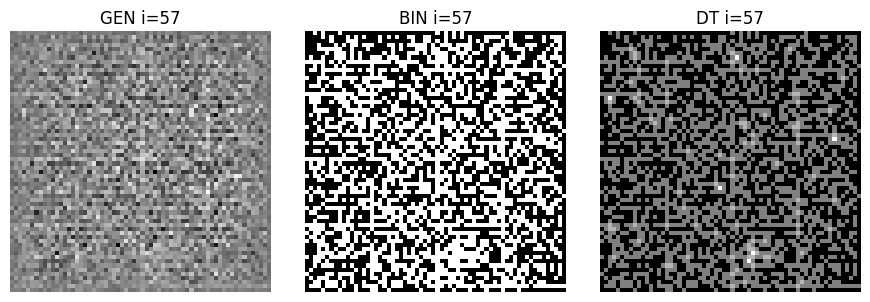

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.5390 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 49
Empty PD detected at sample 49 | dim=1 | Skipping padding and saving debug image...


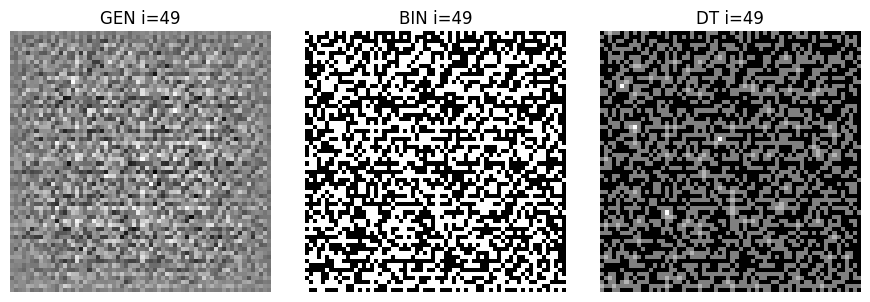

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[1/2000][0/1] D: 9.3932 G: 0.0313 T: 4.5355 W: 4.3117 Step: 1
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 136
Empty PD detected at sample 136 | dim=1 | Skipping padding and saving debug image...


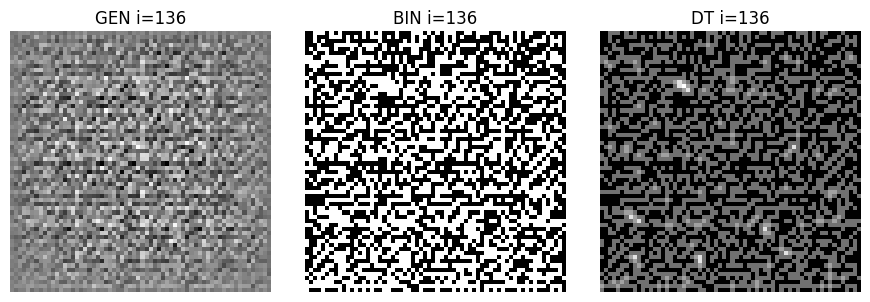

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.5944 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 134
Empty PD detected at sample 134 | dim=1 | Skipping padding and saving debug image...


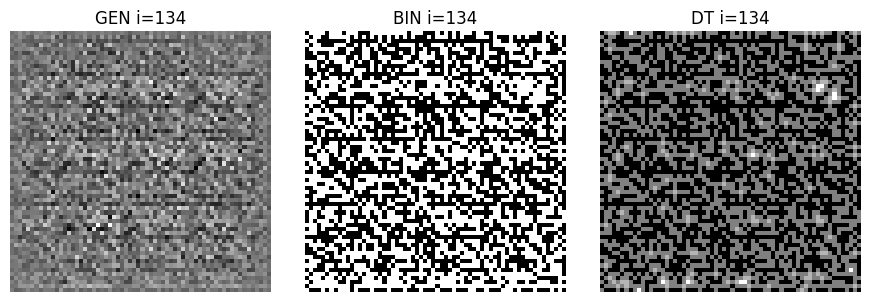

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.6262 seconds
[11/2000][0/1] D: 0.3755 G: 3.5787 T: 4.2469 W: 3.8855 Step: 11
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 80
Empty PD detected at sample 80 | dim=1 | Skipping padding and saving debug image...


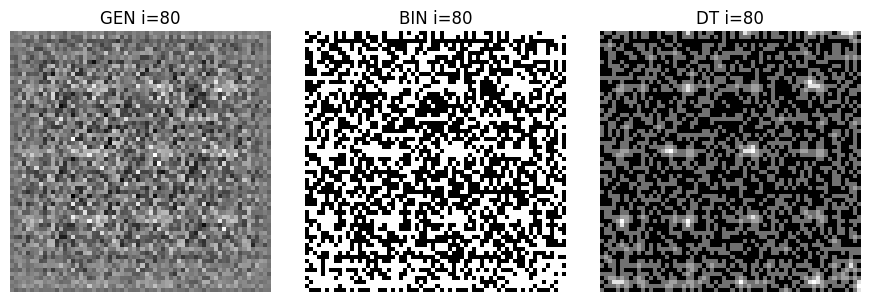

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.9333 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 35
Empty PD detected at sample 35 | dim=1 | Skipping padding and saving debug image...


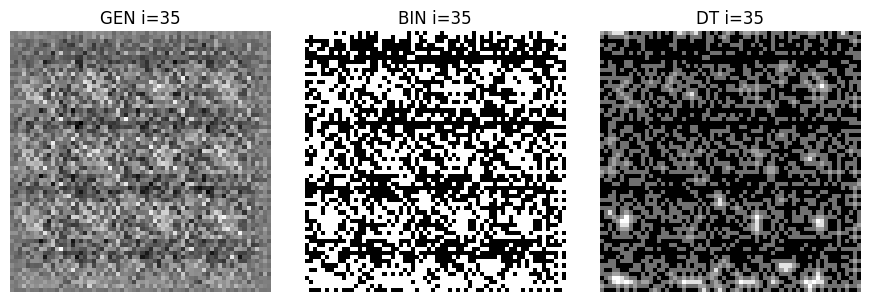

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.3582 seconds
[21/2000][0/1] D: -13.2297 G: 10.6772 T: 4.1661 W: 4.3018 Step: 21
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 30
Empty PD detected at sample 30 | dim=1 | Skipping padding and saving debug image...


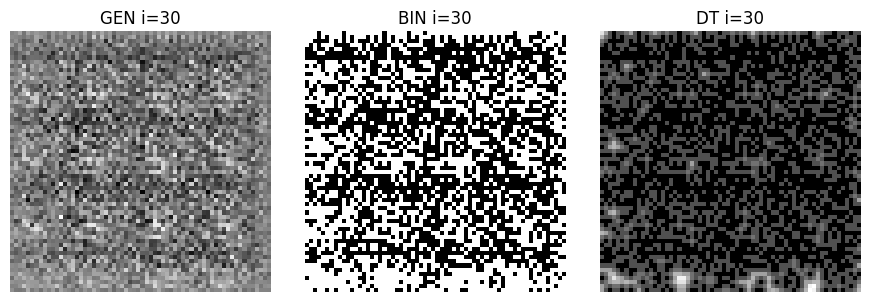

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.2038 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 98
Empty PD detected at sample 98 | dim=1 | Skipping padding and saving debug image...


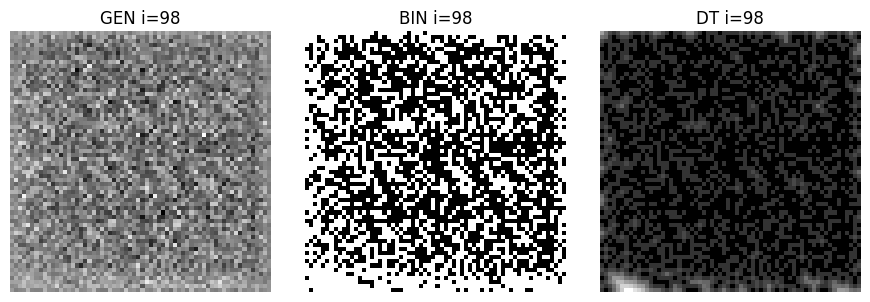

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.7453 seconds
[31/2000][0/1] D: -14.5389 G: 9.6301 T: 4.0576 W: 4.8636 Step: 31
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 216
Empty PD detected at sample 216 | dim=1 | Skipping padding and saving debug image...


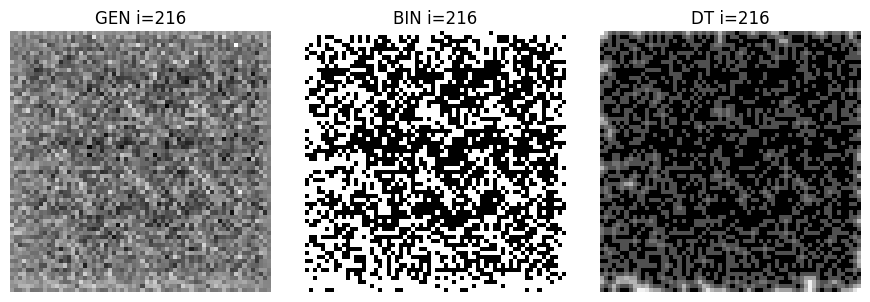

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.0509 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 289
Empty PD detected at sample 289 | dim=1 | Skipping padding and saving debug image...


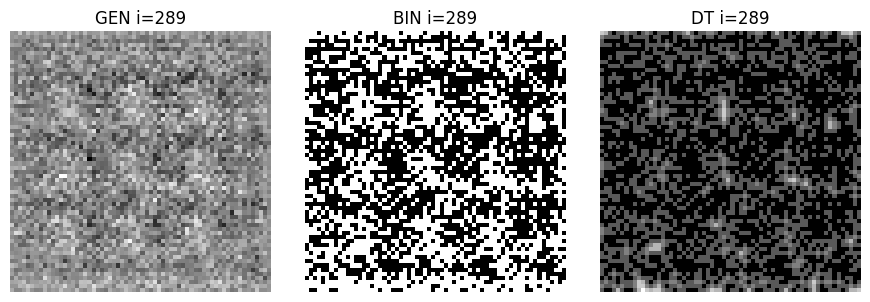

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.6251 seconds
[41/2000][0/1] D: -13.4289 G: 7.4277 T: 4.0799 W: 4.2508 Step: 41
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 68
Empty PD detected at sample 68 | dim=1 | Skipping padding and saving debug image...


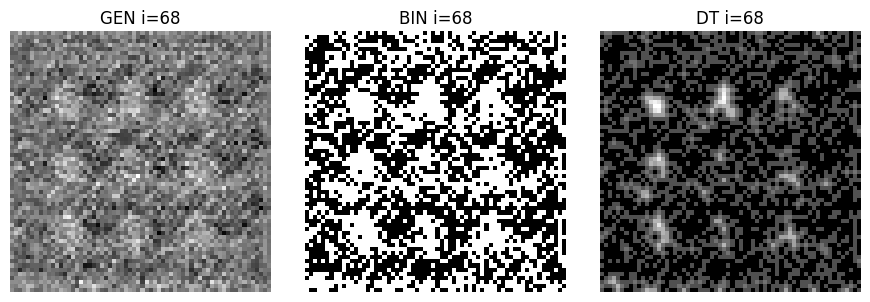

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.2088 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 38
Empty PD detected at sample 38 | dim=1 | Skipping padding and saving debug image...


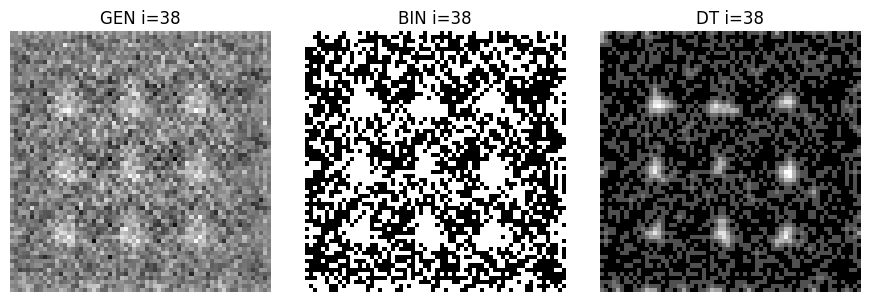

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.1389 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 55
Empty PD detected at sample 55 | dim=1 | Skipping padding and saving debug image...


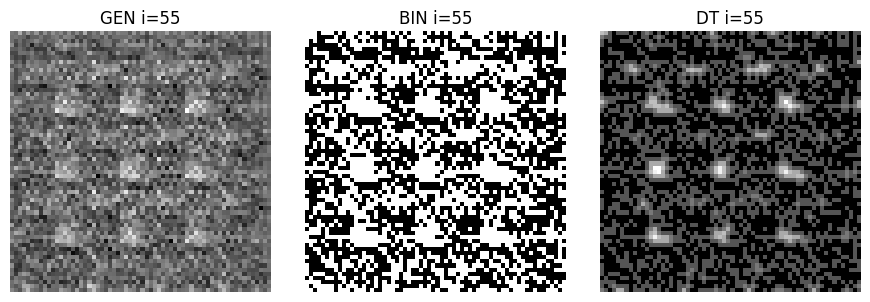

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[51/2000][0/1] D: -12.9061 G: 3.5391 T: 4.1695 W: 4.6919 Step: 51
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 261
Empty PD detected at sample 261 | dim=1 | Skipping padding and saving debug image...


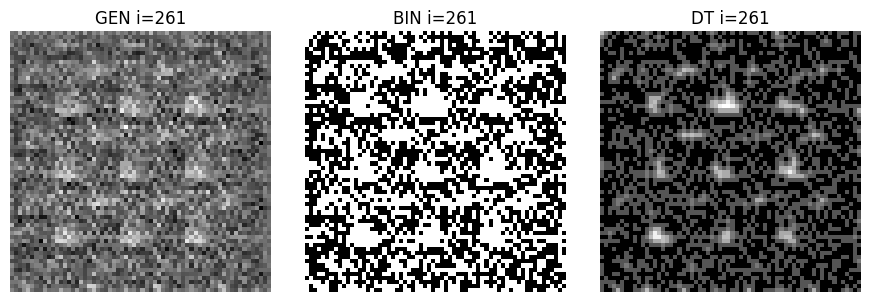

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.4371 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 291
Empty PD detected at sample 291 | dim=1 | Skipping padding and saving debug image...


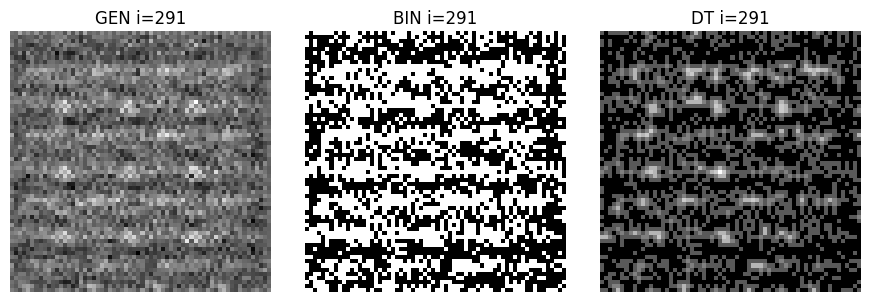

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.4661 seconds
[61/2000][0/1] D: -12.7842 G: 4.2229 T: 4.1555 W: 4.5438 Step: 61
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 243
Empty PD detected at sample 243 | dim=1 | Skipping padding and saving debug image...


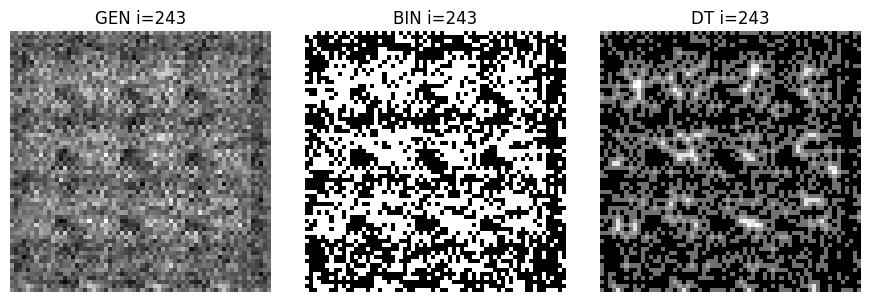

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 12.2146 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 280
Empty PD detected at sample 280 | dim=1 | Skipping padding and saving debug image...


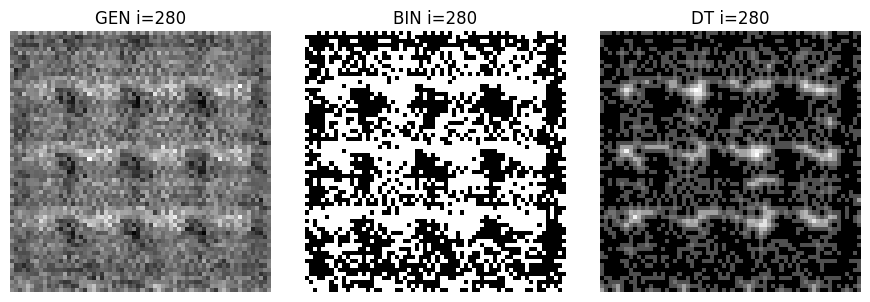

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.4753 seconds
[71/2000][0/1] D: -12.3102 G: 3.0806 T: 4.1635 W: 4.9091 Step: 71
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 277
Empty PD detected at sample 277 | dim=1 | Skipping padding and saving debug image...


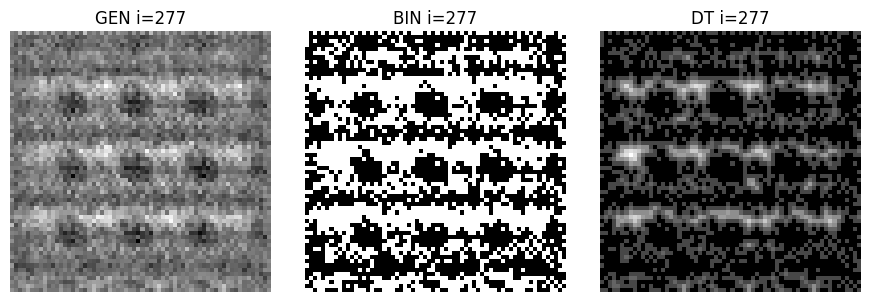

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.1541 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 201
Empty PD detected at sample 201 | dim=1 | Skipping padding and saving debug image...


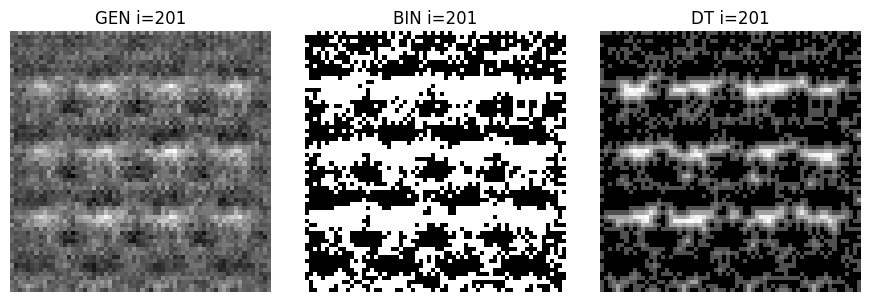

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.4007 seconds
[81/2000][0/1] D: -12.9366 G: 3.1834 T: 4.1936 W: 4.1212 Step: 81
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 78
Empty PD detected at sample 78 | dim=1 | Skipping padding and saving debug image...


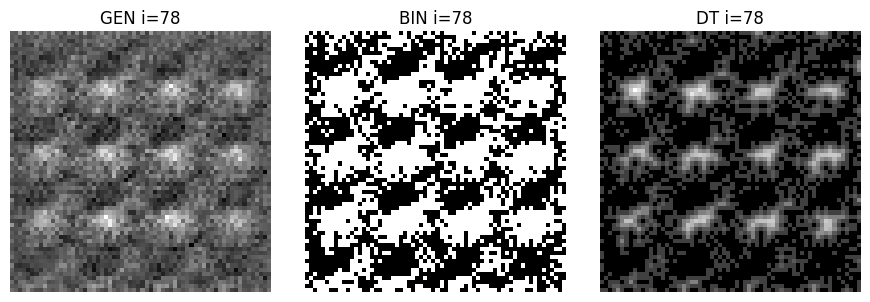

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.1954 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 219
Empty PD detected at sample 219 | dim=1 | Skipping padding and saving debug image...


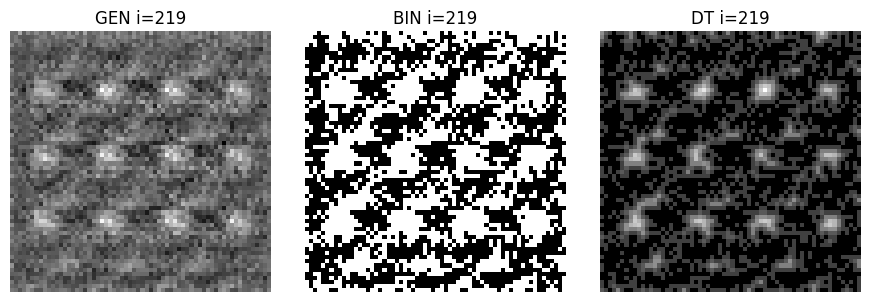

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.5182 seconds
[91/2000][0/1] D: -13.0950 G: 2.0656 T: 4.2201 W: 4.3071 Step: 91
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 312
Empty PD detected at sample 312 | dim=1 | Skipping padding and saving debug image...


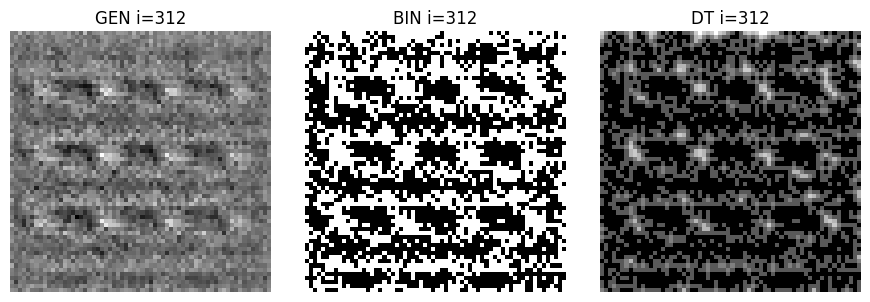

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.8154 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 297
Empty PD detected at sample 297 | dim=1 | Skipping padding and saving debug image...


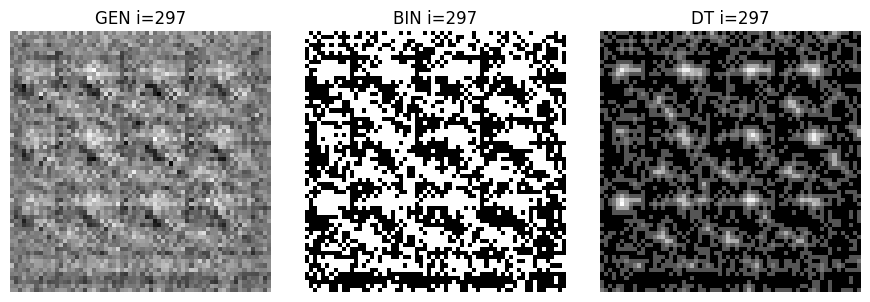

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.2752 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 154
Empty PD detected at sample 154 | dim=1 | Skipping padding and saving debug image...


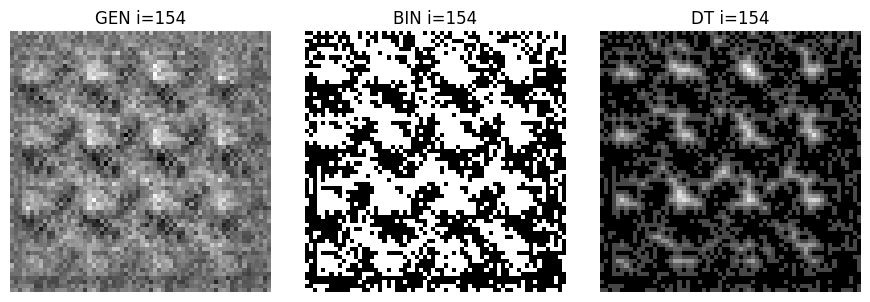

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[101/2000][0/1] D: -12.4432 G: 2.8052 T: 4.2159 W: 4.5142 Step: 101
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 43
Empty PD detected at sample 43 | dim=1 | Skipping padding and saving debug image...


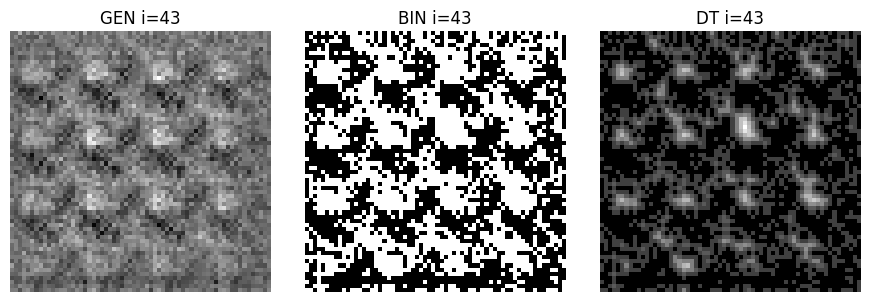

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.8346 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 209
Empty PD detected at sample 209 | dim=1 | Skipping padding and saving debug image...


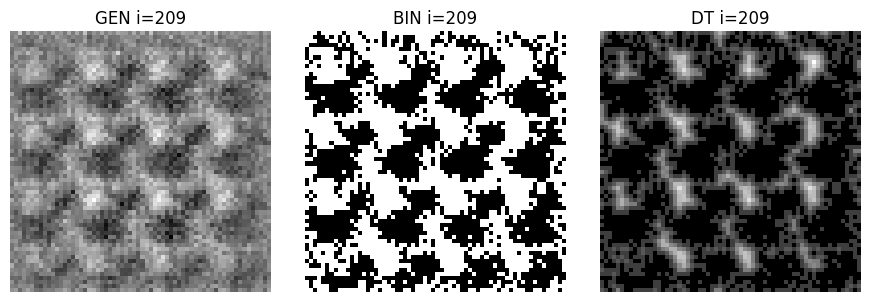

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.8496 seconds
[111/2000][0/1] D: -12.9071 G: 1.9512 T: 4.2178 W: 4.4618 Step: 111
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 256
Empty PD detected at sample 256 | dim=1 | Skipping padding and saving debug image...


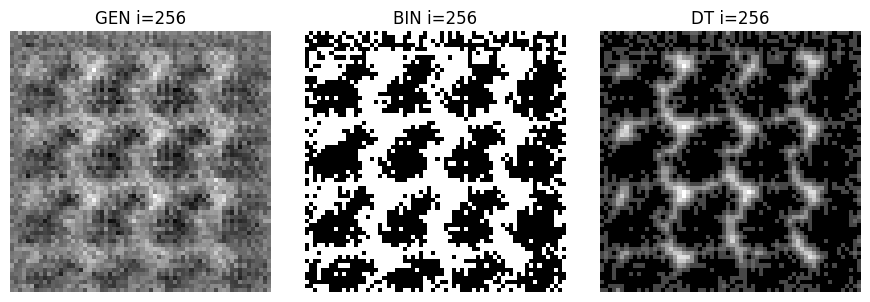

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.7527 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 53
Empty PD detected at sample 53 | dim=1 | Skipping padding and saving debug image...


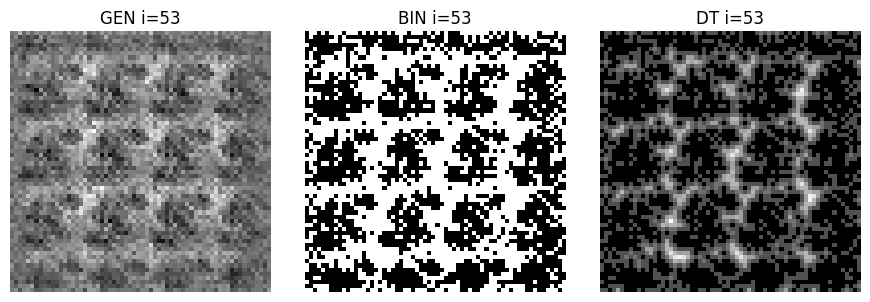

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.4119 seconds
[121/2000][0/1] D: -13.4454 G: 2.2225 T: 4.2255 W: 4.1592 Step: 121
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 147
Empty PD detected at sample 147 | dim=1 | Skipping padding and saving debug image...


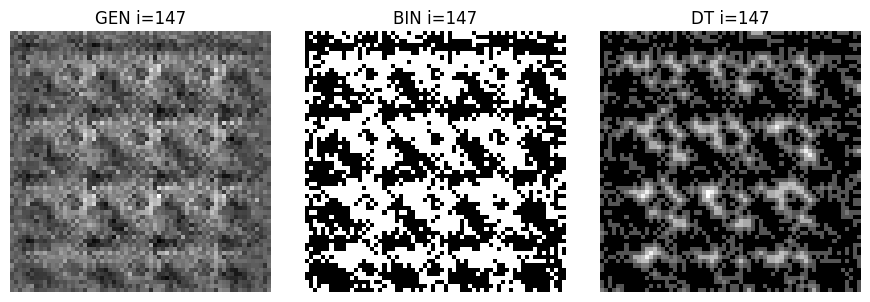

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.9365 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 35
Empty PD detected at sample 35 | dim=1 | Skipping padding and saving debug image...


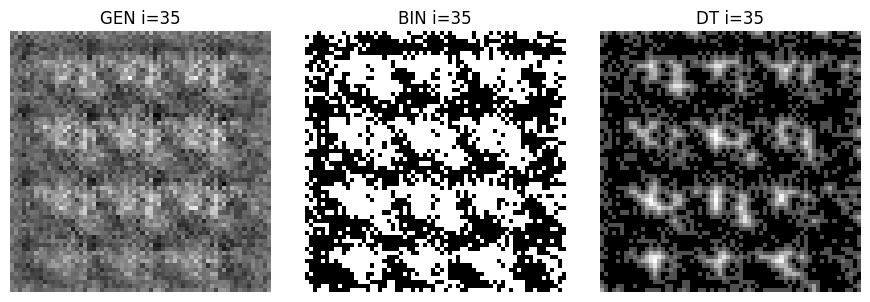

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.7737 seconds
[131/2000][0/1] D: -12.8069 G: 1.6847 T: 4.2214 W: 4.3020 Step: 131
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 197
Empty PD detected at sample 197 | dim=1 | Skipping padding and saving debug image...


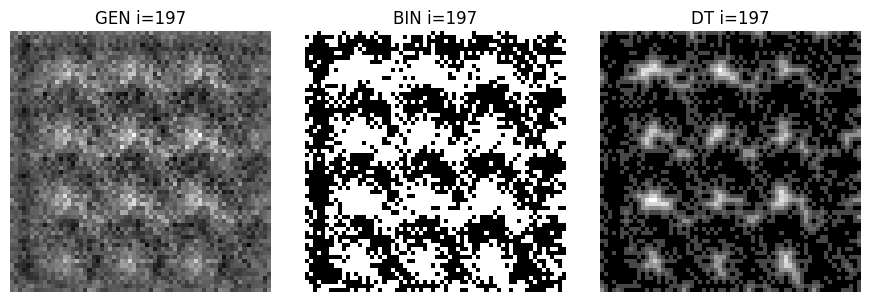

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.3252 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 323
Empty PD detected at sample 323 | dim=1 | Skipping padding and saving debug image...


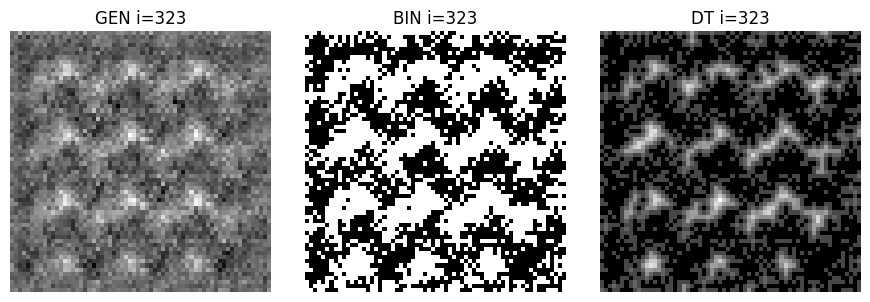

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.0185 seconds
[141/2000][0/1] D: -12.8923 G: 2.8056 T: 4.2037 W: 4.0376 Step: 141
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 298
Empty PD detected at sample 298 | dim=1 | Skipping padding and saving debug image...


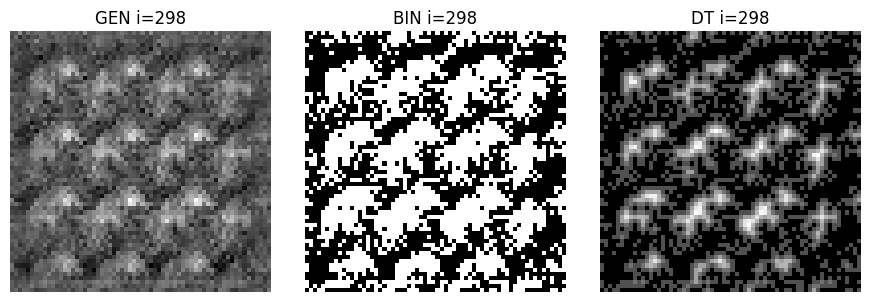

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.5267 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 202
Empty PD detected at sample 202 | dim=1 | Skipping padding and saving debug image...


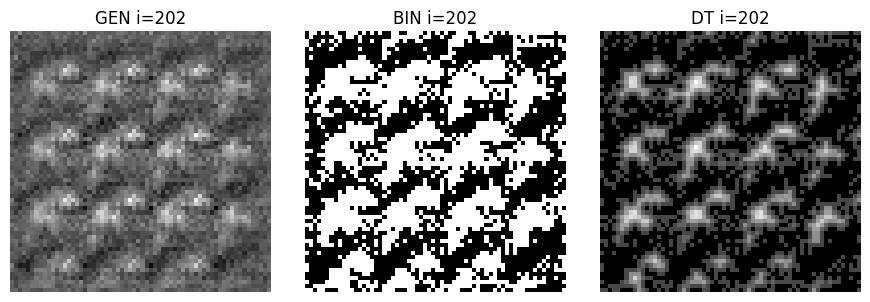

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.6396 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 271
Empty PD detected at sample 271 | dim=1 | Skipping padding and saving debug image...


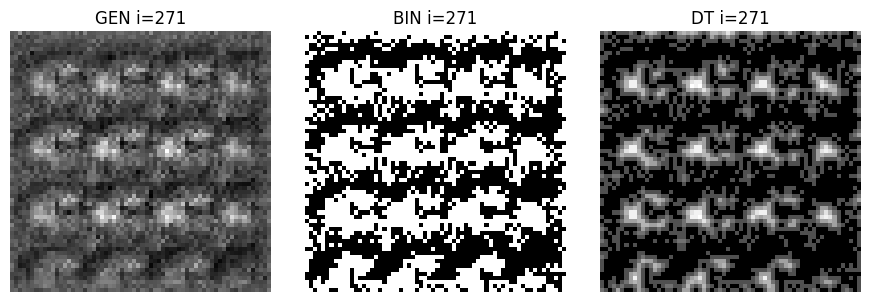

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[151/2000][0/1] D: -13.3828 G: -0.0987 T: 4.3162 W: 5.0569 Step: 151
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 317
Empty PD detected at sample 317 | dim=1 | Skipping padding and saving debug image...


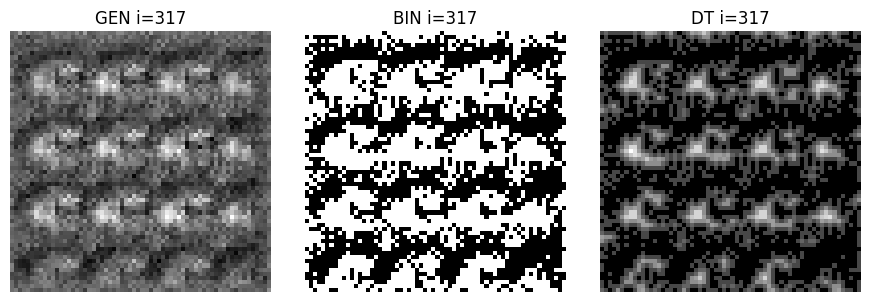

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.9873 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 16
Empty PD detected at sample 16 | dim=1 | Skipping padding and saving debug image...


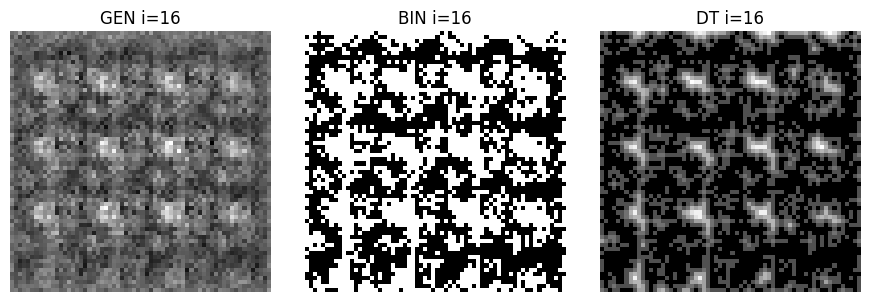

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.3442 seconds
[161/2000][0/1] D: -13.6426 G: 3.8120 T: 4.1783 W: 4.2969 Step: 161
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 168
Empty PD detected at sample 168 | dim=1 | Skipping padding and saving debug image...


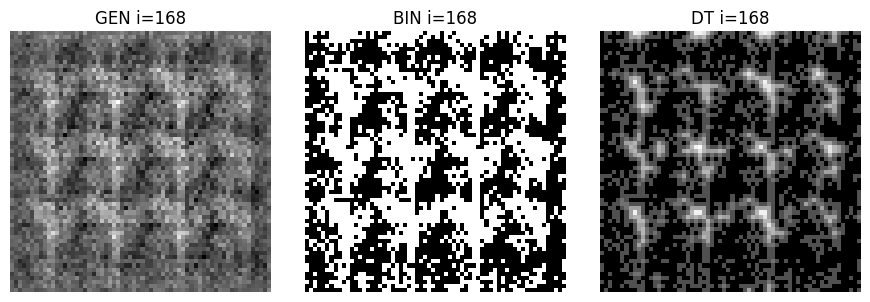

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.8080 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 257
Empty PD detected at sample 257 | dim=1 | Skipping padding and saving debug image...


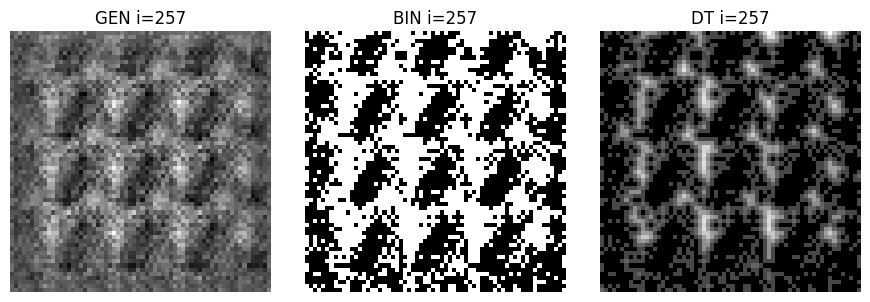

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.2369 seconds
[171/2000][0/1] D: -13.0764 G: 0.7323 T: 4.2781 W: 4.9747 Step: 171
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 258
Empty PD detected at sample 258 | dim=1 | Skipping padding and saving debug image...


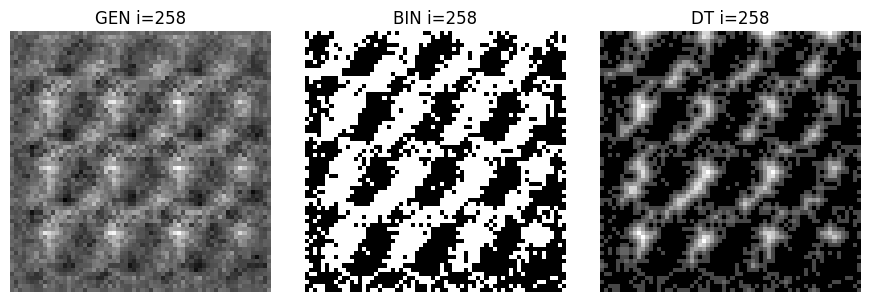

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.9317 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 287
Empty PD detected at sample 287 | dim=1 | Skipping padding and saving debug image...


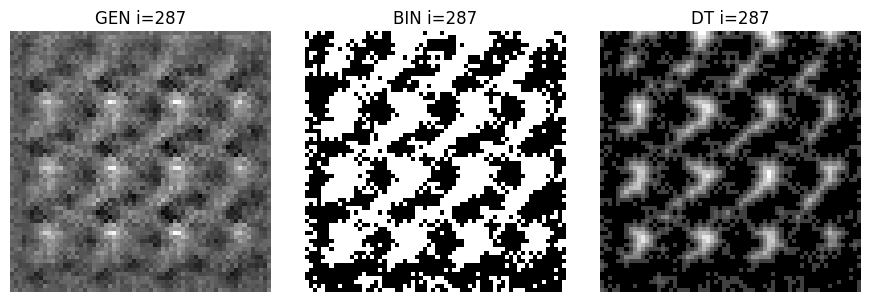

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.5220 seconds
[181/2000][0/1] D: -13.4682 G: 1.9479 T: 4.2473 W: 3.9012 Step: 181
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 136
Empty PD detected at sample 136 | dim=1 | Skipping padding and saving debug image...


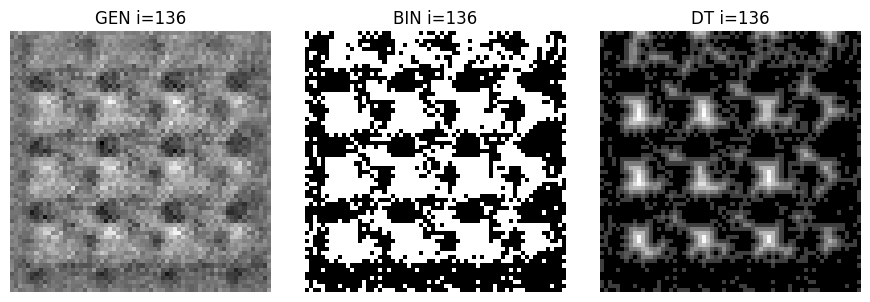

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.8236 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 41
Empty PD detected at sample 41 | dim=1 | Skipping padding and saving debug image...


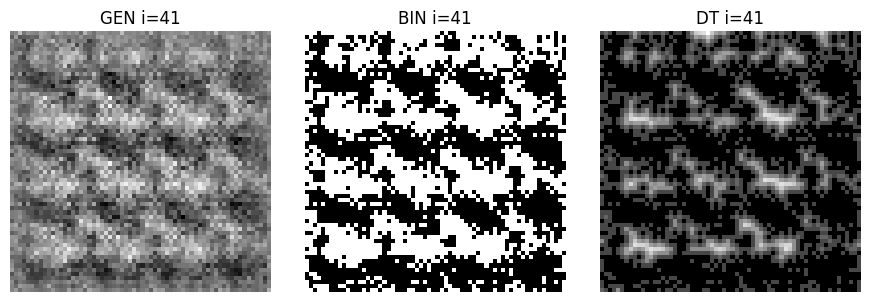

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.2522 seconds
[191/2000][0/1] D: -13.2713 G: 1.6937 T: 4.2273 W: 4.3141 Step: 191
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 220
Empty PD detected at sample 220 | dim=1 | Skipping padding and saving debug image...


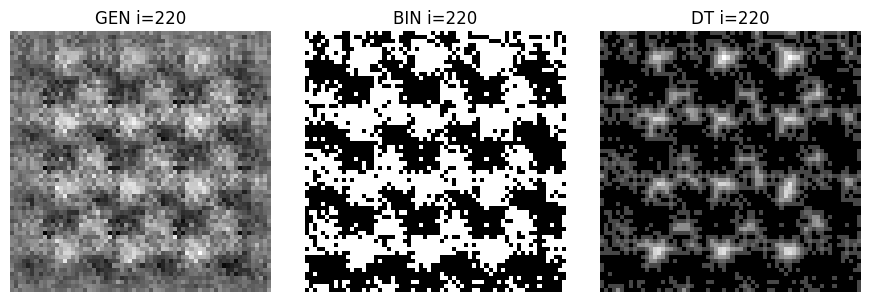

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.7712 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 223
Empty PD detected at sample 223 | dim=1 | Skipping padding and saving debug image...


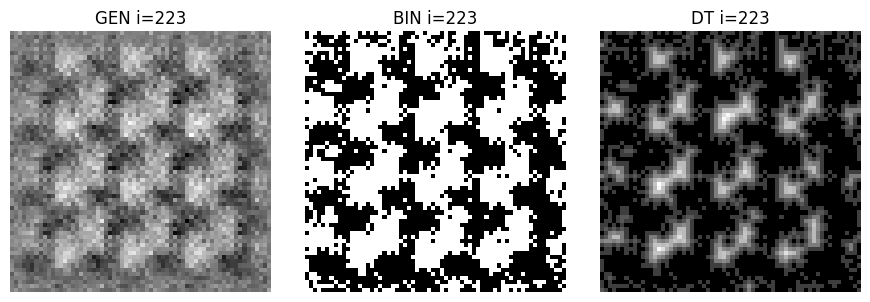

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.9170 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 288
Empty PD detected at sample 288 | dim=1 | Skipping padding and saving debug image...


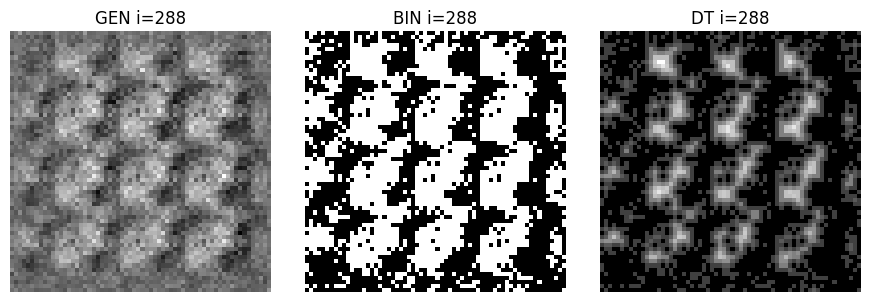

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[201/2000][0/1] D: -12.9111 G: 1.7570 T: 4.2377 W: 4.3864 Step: 201
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 259
Empty PD detected at sample 259 | dim=1 | Skipping padding and saving debug image...


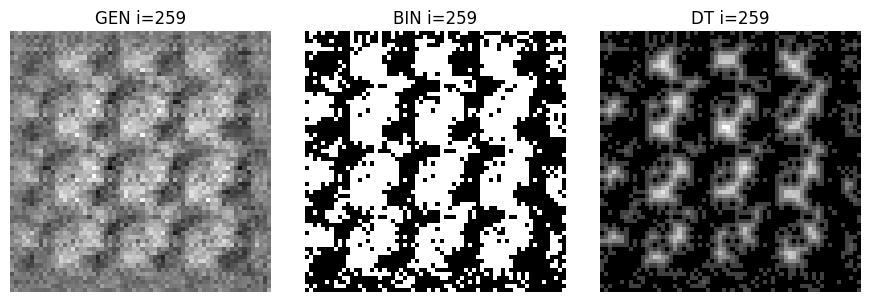

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.5744 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 306
Empty PD detected at sample 306 | dim=1 | Skipping padding and saving debug image...


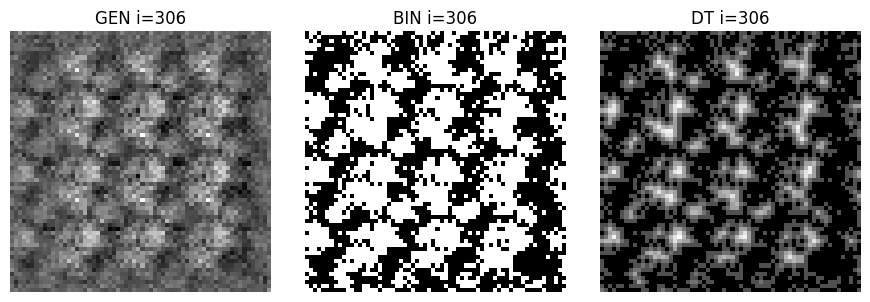

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 12.1465 seconds
[211/2000][0/1] D: -13.5446 G: 1.0143 T: 4.2613 W: 4.2949 Step: 211
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 109
Empty PD detected at sample 109 | dim=1 | Skipping padding and saving debug image...


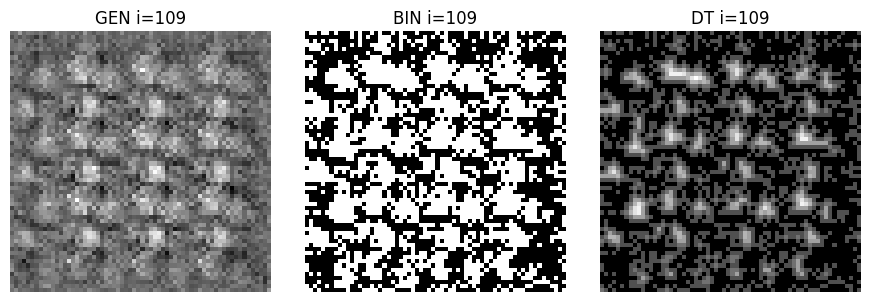

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.8671 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 119
Empty PD detected at sample 119 | dim=1 | Skipping padding and saving debug image...


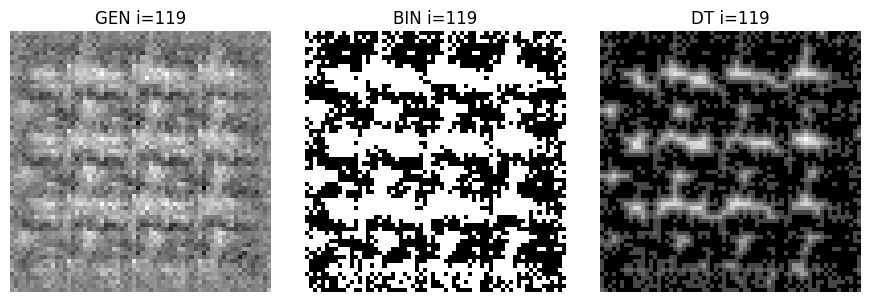

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.3082 seconds
[221/2000][0/1] D: -13.7215 G: 1.7795 T: 4.2261 W: 4.1180 Step: 221
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 223
Empty PD detected at sample 223 | dim=1 | Skipping padding and saving debug image...


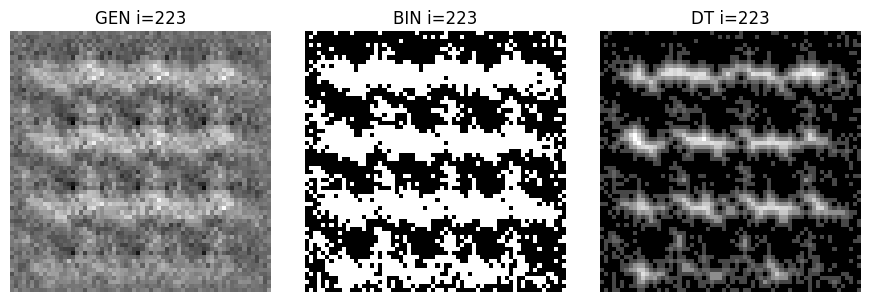

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.4982 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 76
Empty PD detected at sample 76 | dim=1 | Skipping padding and saving debug image...


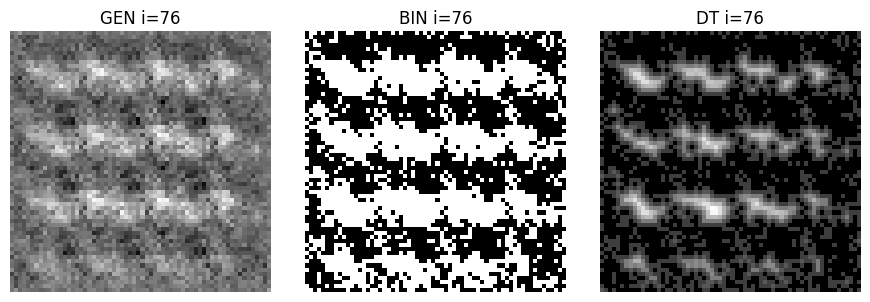

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.1063 seconds
[231/2000][0/1] D: -13.7586 G: 0.7923 T: 4.2551 W: 3.6424 Step: 231
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 95
Empty PD detected at sample 95 | dim=1 | Skipping padding and saving debug image...


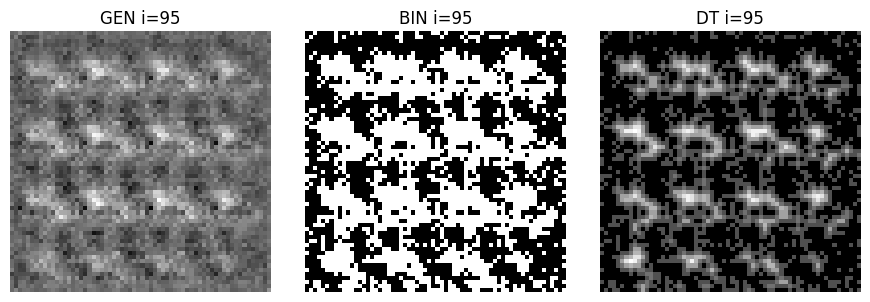

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.8026 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 93
Empty PD detected at sample 93 | dim=1 | Skipping padding and saving debug image...


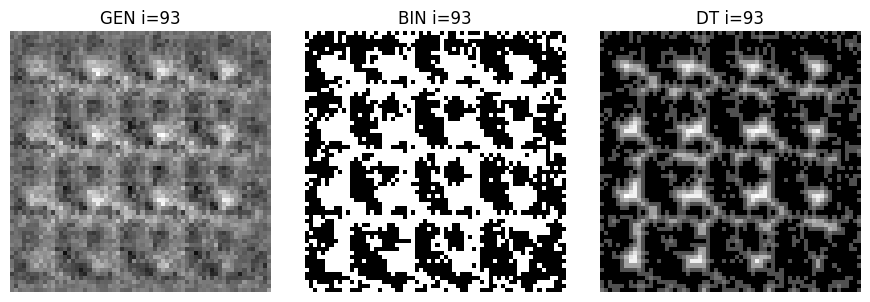

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.4359 seconds
[241/2000][0/1] D: -13.8104 G: 1.3047 T: 4.2171 W: 3.9916 Step: 241
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 136
Empty PD detected at sample 136 | dim=1 | Skipping padding and saving debug image...


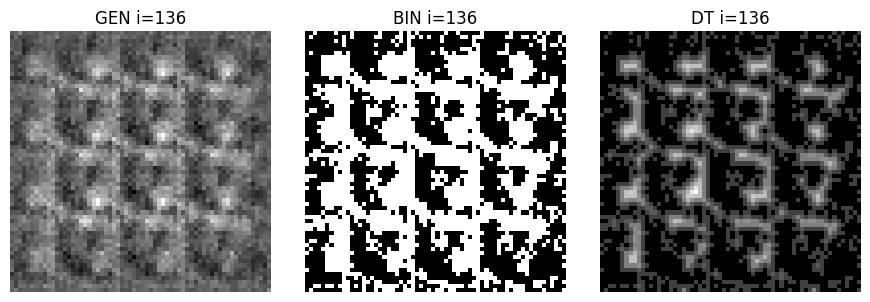

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.6517 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 73
Empty PD detected at sample 73 | dim=1 | Skipping padding and saving debug image...


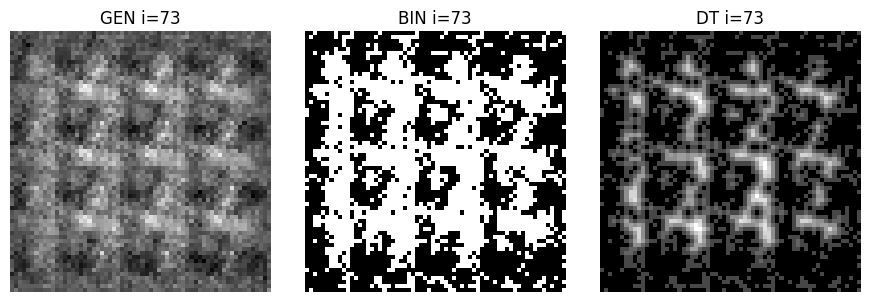

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 13.0287 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 60
Empty PD detected at sample 60 | dim=1 | Skipping padding and saving debug image...


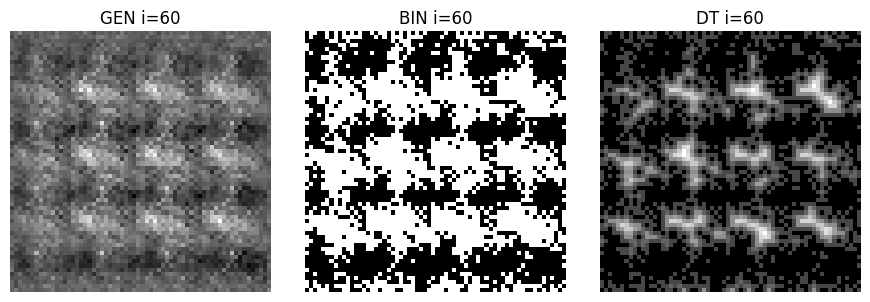

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[251/2000][0/1] D: -14.0330 G: 0.4018 T: 4.2817 W: 4.0895 Step: 251
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 184
Empty PD detected at sample 184 | dim=1 | Skipping padding and saving debug image...


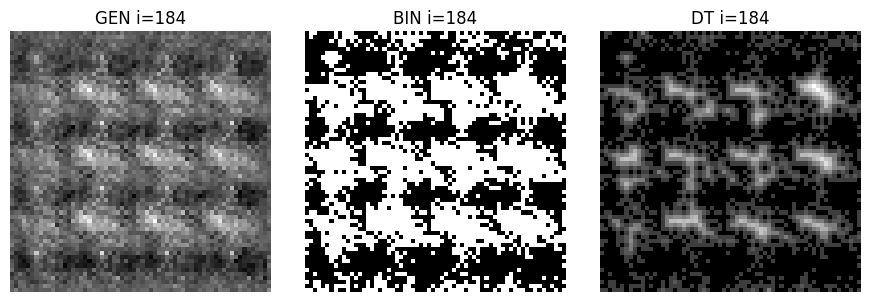

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.9349 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 78
Empty PD detected at sample 78 | dim=1 | Skipping padding and saving debug image...


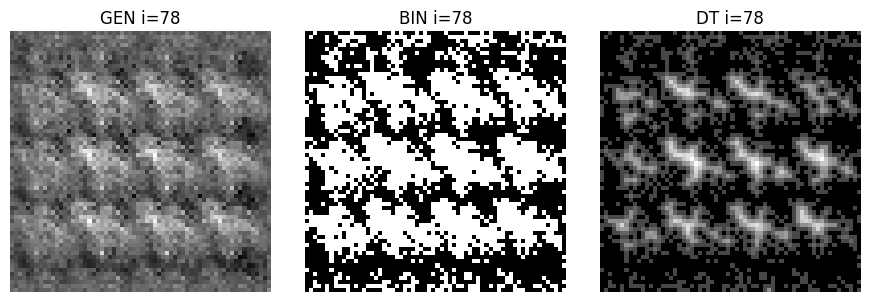

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.7208 seconds
[261/2000][0/1] D: -13.7410 G: 2.3153 T: 4.2461 W: 3.9080 Step: 261
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 23
Empty PD detected at sample 23 | dim=1 | Skipping padding and saving debug image...


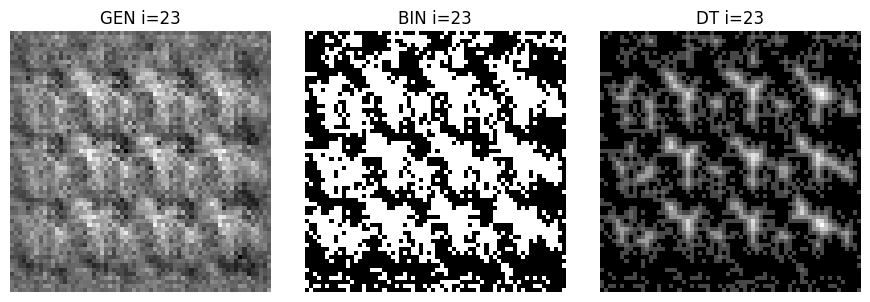

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.2205 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 66
Empty PD detected at sample 66 | dim=1 | Skipping padding and saving debug image...


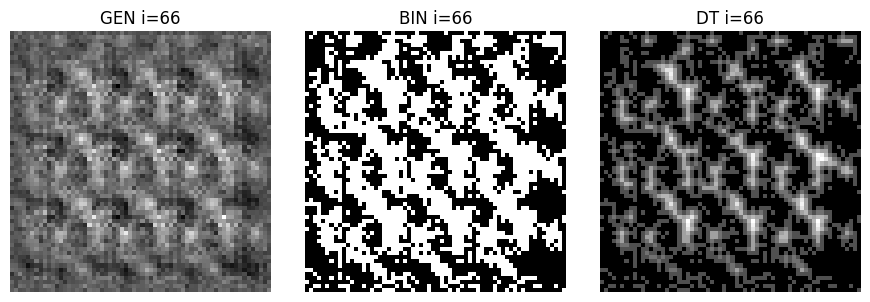

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.5212 seconds
[271/2000][0/1] D: -13.4561 G: 0.8966 T: 4.3190 W: 4.3619 Step: 271
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 234
Empty PD detected at sample 234 | dim=1 | Skipping padding and saving debug image...


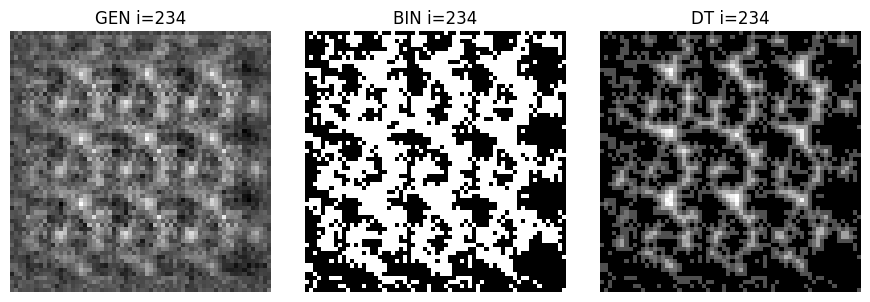

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 12.2620 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 281
Empty PD detected at sample 281 | dim=1 | Skipping padding and saving debug image...


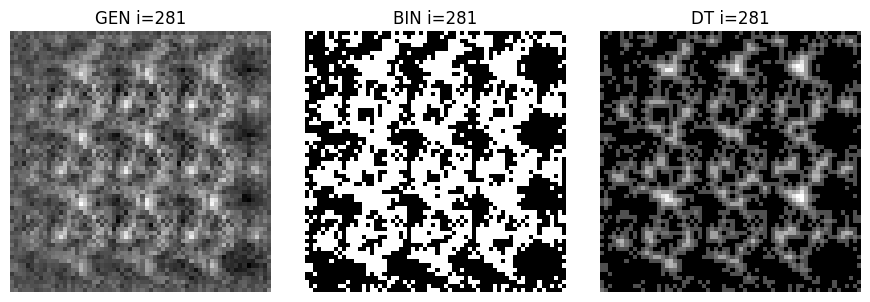

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.6157 seconds
[281/2000][0/1] D: -14.3045 G: -0.2074 T: 4.3169 W: 4.1244 Step: 281
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 83
Empty PD detected at sample 83 | dim=1 | Skipping padding and saving debug image...


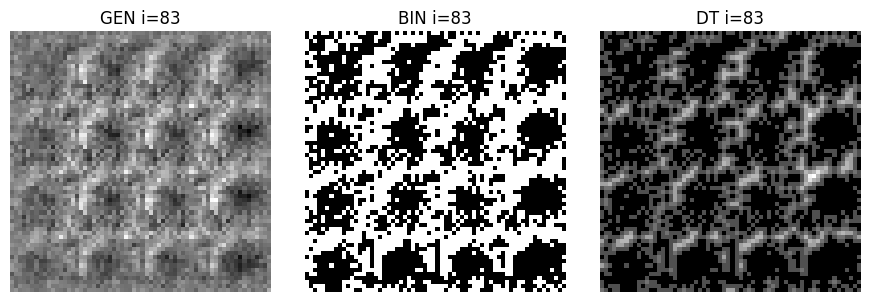

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.2530 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 75
Empty PD detected at sample 75 | dim=1 | Skipping padding and saving debug image...


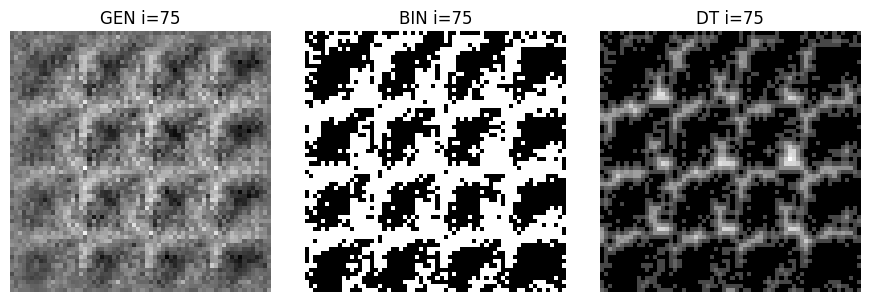

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.9933 seconds
[291/2000][0/1] D: -14.0511 G: 2.6024 T: 4.1988 W: 3.7767 Step: 291
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 312
Empty PD detected at sample 312 | dim=1 | Skipping padding and saving debug image...


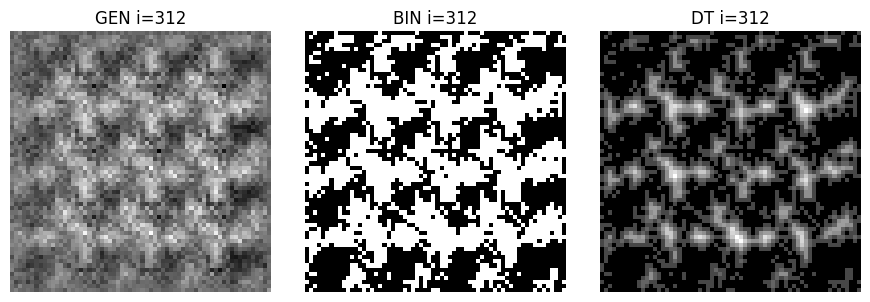

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.9526 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 287
Empty PD detected at sample 287 | dim=1 | Skipping padding and saving debug image...


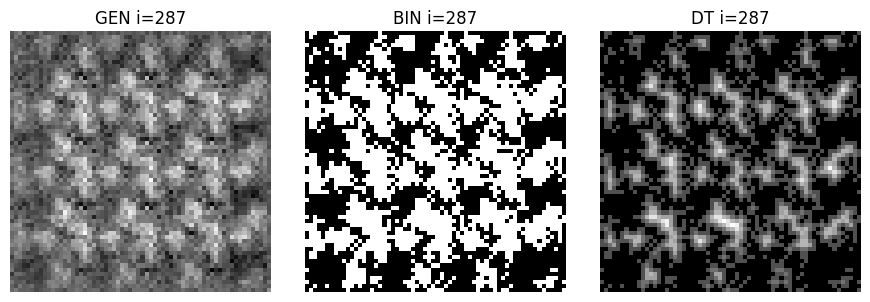

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.0106 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 19
Empty PD detected at sample 19 | dim=1 | Skipping padding and saving debug image...


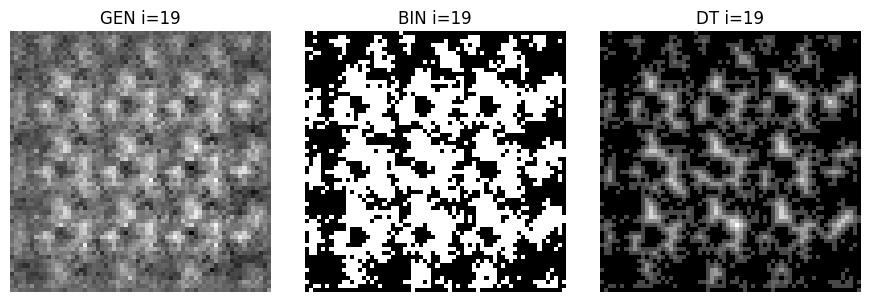

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[301/2000][0/1] D: -14.3974 G: 0.9738 T: 4.3038 W: 4.2607 Step: 301
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 151
Empty PD detected at sample 151 | dim=1 | Skipping padding and saving debug image...


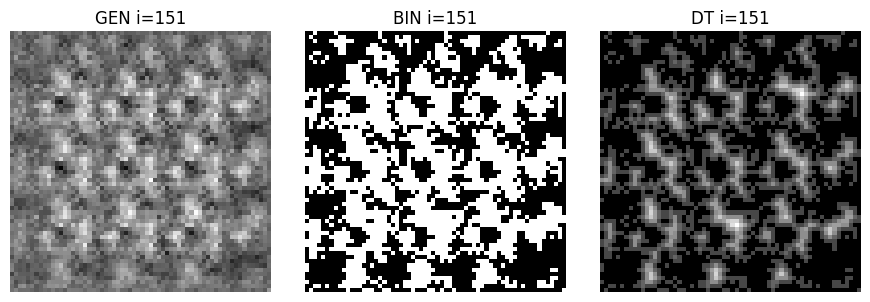

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.6917 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 157
Empty PD detected at sample 157 | dim=1 | Skipping padding and saving debug image...


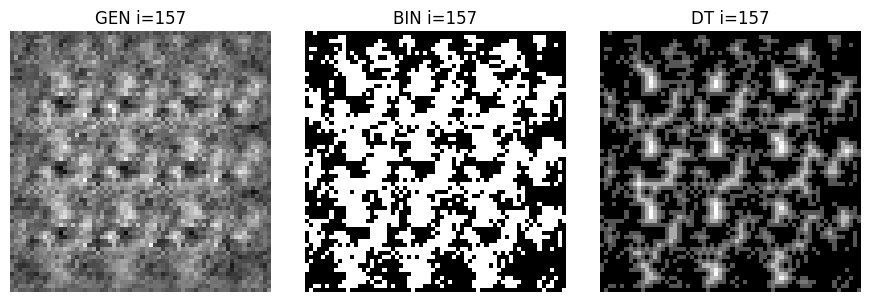

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.6907 seconds
[311/2000][0/1] D: -13.3724 G: -0.0786 T: 4.3380 W: 4.5479 Step: 311
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 31
Empty PD detected at sample 31 | dim=1 | Skipping padding and saving debug image...


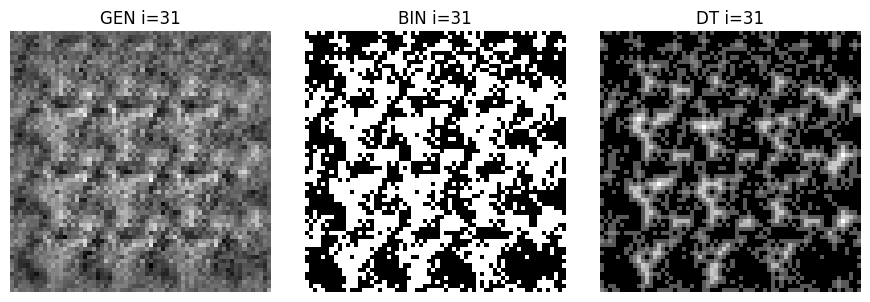

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.5692 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 111
Empty PD detected at sample 111 | dim=1 | Skipping padding and saving debug image...


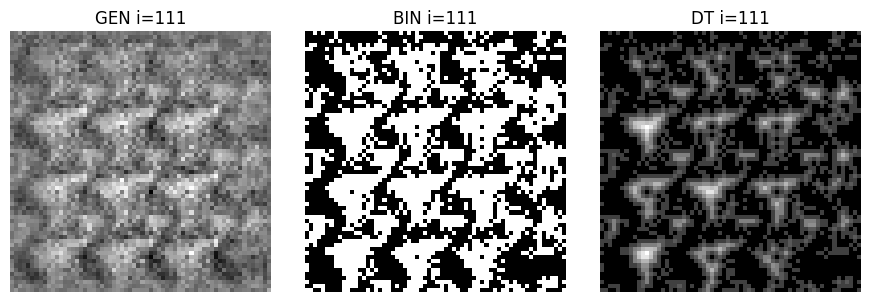

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.1112 seconds
[321/2000][0/1] D: -14.8675 G: 1.8944 T: 4.2239 W: 4.3018 Step: 321
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 1
Empty PD detected at sample 1 | dim=1 | Skipping padding and saving debug image...


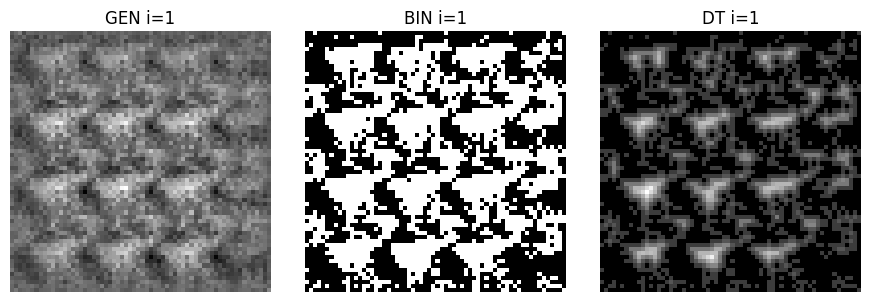

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.7323 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 119
Empty PD detected at sample 119 | dim=1 | Skipping padding and saving debug image...


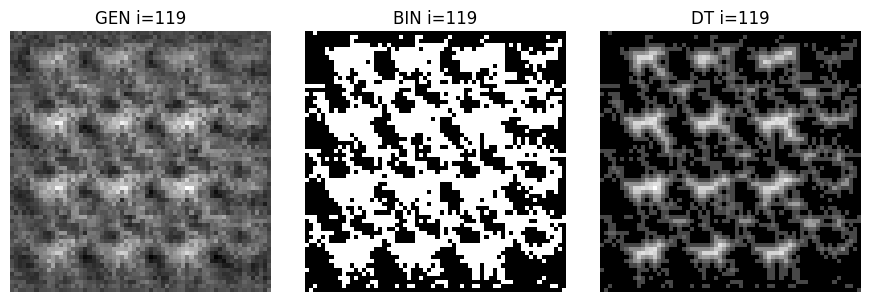

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.4507 seconds
[331/2000][0/1] D: -14.2338 G: 0.1847 T: 4.3352 W: 4.1182 Step: 331
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 163
Empty PD detected at sample 163 | dim=1 | Skipping padding and saving debug image...


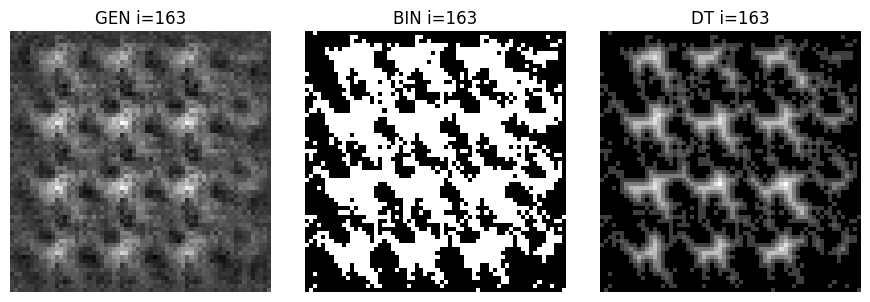

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.7252 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 309
Empty PD detected at sample 309 | dim=1 | Skipping padding and saving debug image...


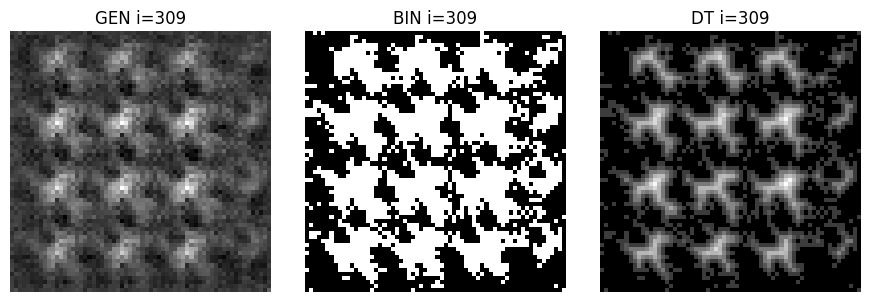

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.0441 seconds
[341/2000][0/1] D: -15.2052 G: 0.0269 T: 4.3436 W: 4.2278 Step: 341
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 238
Empty PD detected at sample 238 | dim=1 | Skipping padding and saving debug image...


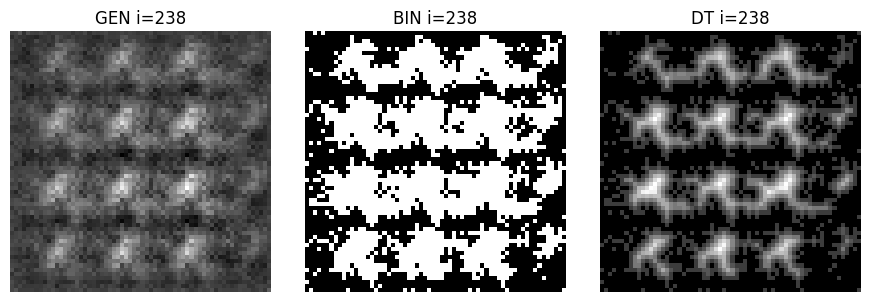

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.1117 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 86
Empty PD detected at sample 86 | dim=1 | Skipping padding and saving debug image...


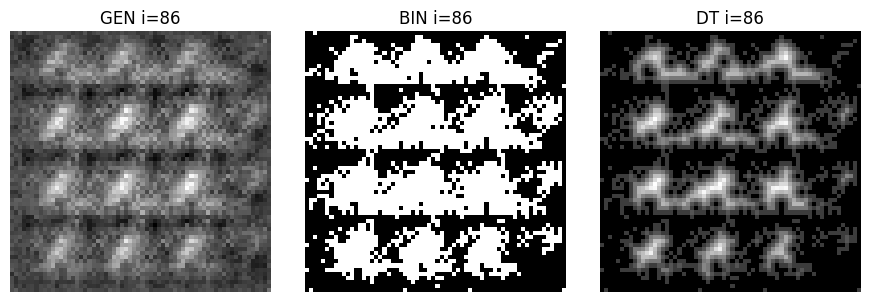

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.9538 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 210
Empty PD detected at sample 210 | dim=1 | Skipping padding and saving debug image...


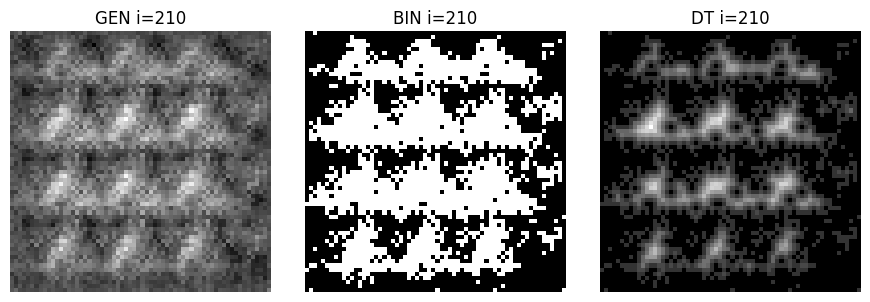

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[351/2000][0/1] D: -14.7978 G: 1.2649 T: 4.3081 W: 3.8456 Step: 351
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 207
Empty PD detected at sample 207 | dim=1 | Skipping padding and saving debug image...


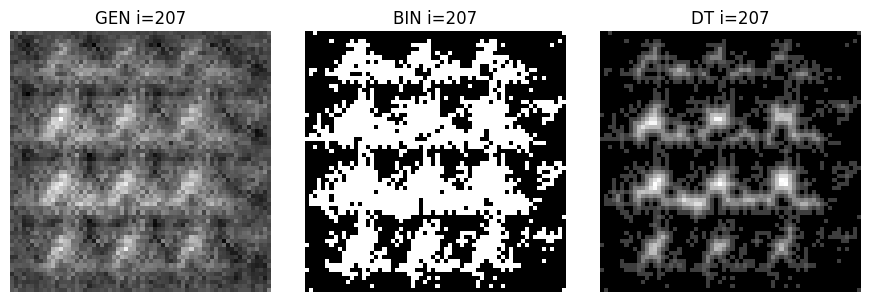

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 12.9373 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 203
Empty PD detected at sample 203 | dim=1 | Skipping padding and saving debug image...


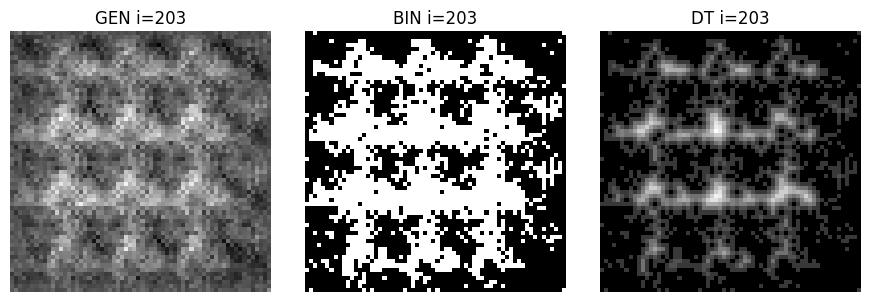

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 12.5398 seconds
[361/2000][0/1] D: -14.1349 G: 0.6225 T: 4.3176 W: 4.1331 Step: 361
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 283
Empty PD detected at sample 283 | dim=1 | Skipping padding and saving debug image...


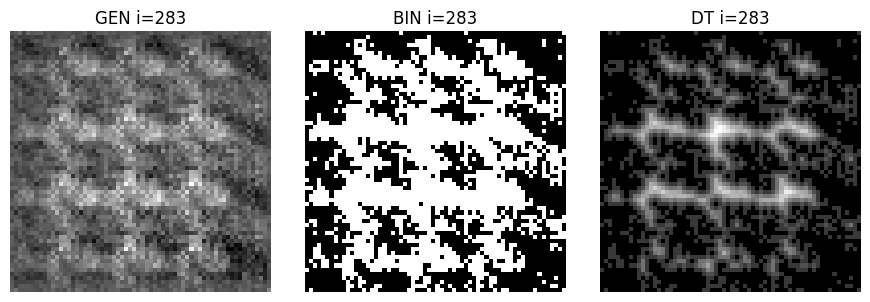

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 12.1507 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 52
Empty PD detected at sample 52 | dim=1 | Skipping padding and saving debug image...


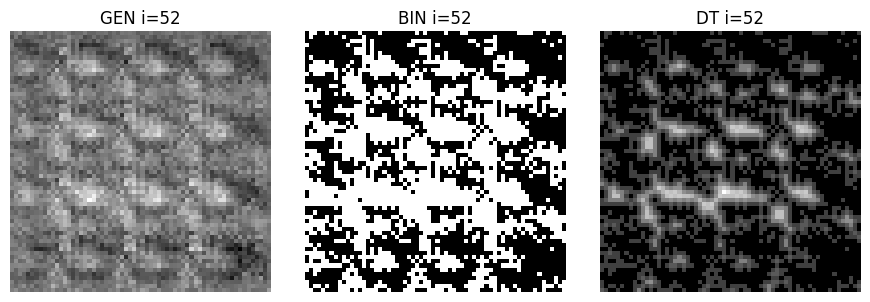

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.3618 seconds
[371/2000][0/1] D: -13.5952 G: 0.5631 T: 4.2286 W: 4.2717 Step: 371
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 39
Empty PD detected at sample 39 | dim=1 | Skipping padding and saving debug image...


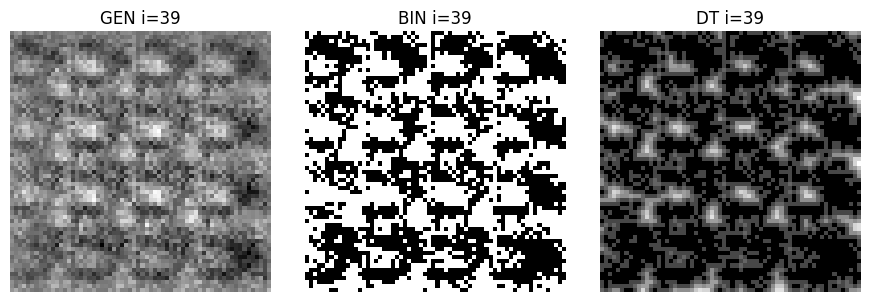

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.6186 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 251
Empty PD detected at sample 251 | dim=1 | Skipping padding and saving debug image...


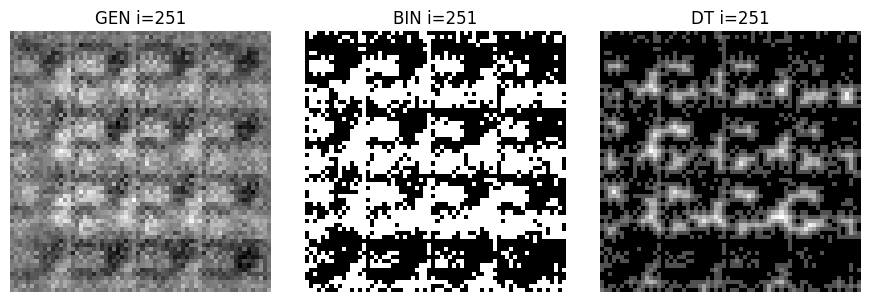

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.6737 seconds
[381/2000][0/1] D: -13.6258 G: 3.8064 T: 4.1702 W: 4.1613 Step: 381
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 306
Empty PD detected at sample 306 | dim=1 | Skipping padding and saving debug image...


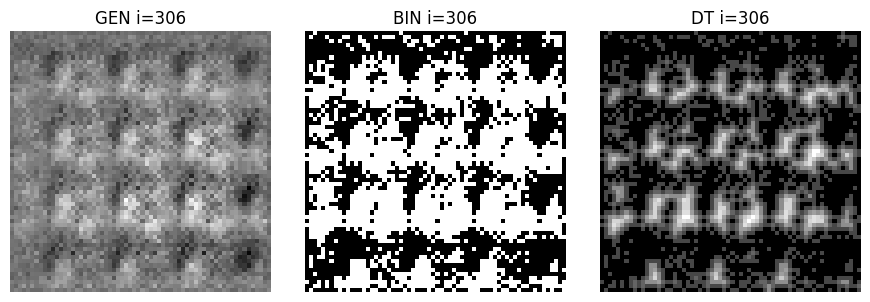

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.7501 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 294
Empty PD detected at sample 294 | dim=1 | Skipping padding and saving debug image...


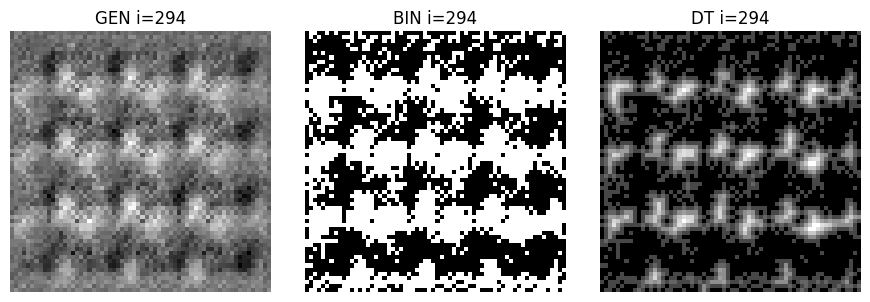

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.9798 seconds
[391/2000][0/1] D: -14.1046 G: -0.7230 T: 4.3400 W: 4.7634 Step: 391
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 11
Empty PD detected at sample 11 | dim=1 | Skipping padding and saving debug image...


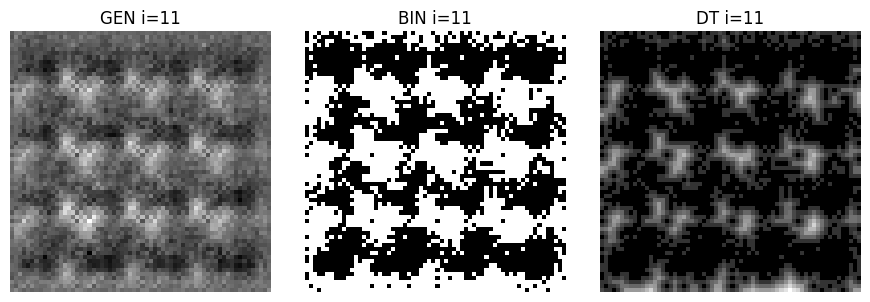

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.2226 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 295
Empty PD detected at sample 295 | dim=1 | Skipping padding and saving debug image...


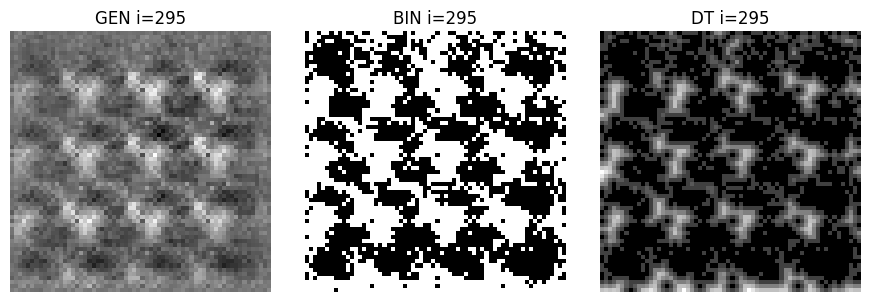

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.7828 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 191
Empty PD detected at sample 191 | dim=1 | Skipping padding and saving debug image...


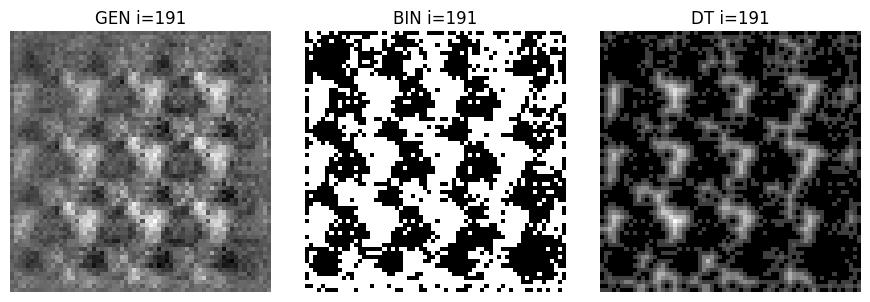

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[401/2000][0/1] D: -14.6706 G: 2.5887 T: 4.2276 W: 3.7946 Step: 401
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 251
Empty PD detected at sample 251 | dim=1 | Skipping padding and saving debug image...


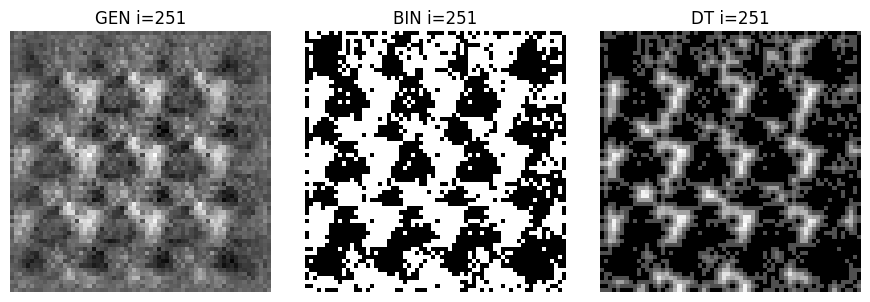

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.0455 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 126
Empty PD detected at sample 126 | dim=1 | Skipping padding and saving debug image...


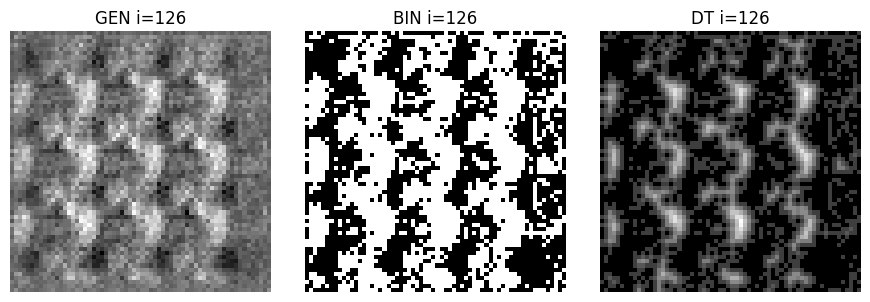

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.9887 seconds
[411/2000][0/1] D: -14.0894 G: 0.1782 T: 4.3239 W: 4.1300 Step: 411
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 48
Empty PD detected at sample 48 | dim=1 | Skipping padding and saving debug image...


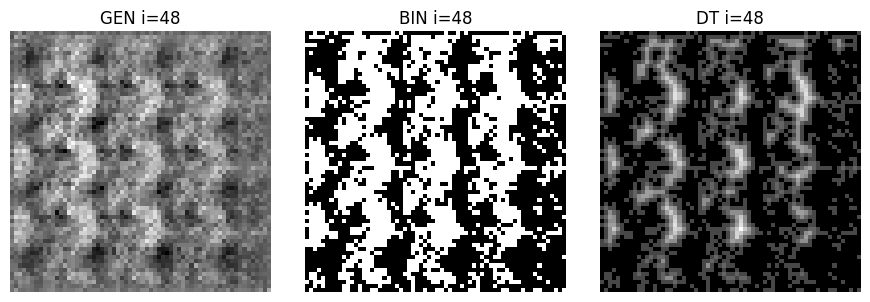

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.3542 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 47
Empty PD detected at sample 47 | dim=1 | Skipping padding and saving debug image...


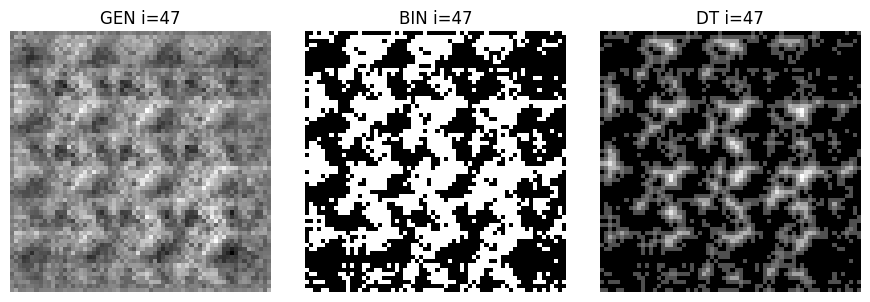

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.4089 seconds
[421/2000][0/1] D: -13.7787 G: 0.1793 T: 4.2765 W: 4.3439 Step: 421
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 67
Empty PD detected at sample 67 | dim=1 | Skipping padding and saving debug image...


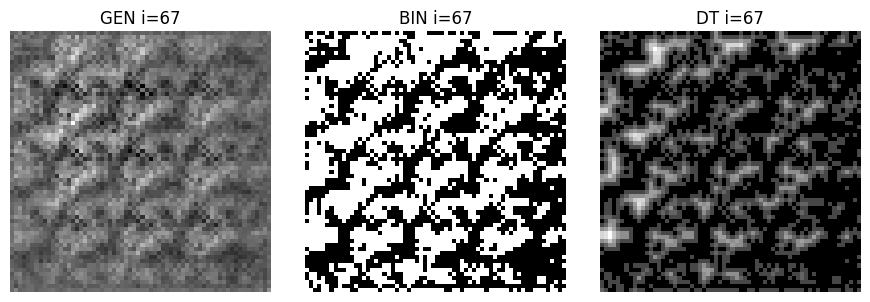

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.7783 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 196
Empty PD detected at sample 196 | dim=1 | Skipping padding and saving debug image...


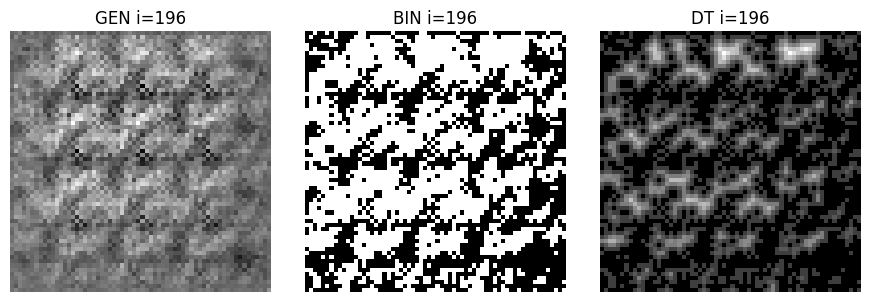

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.8801 seconds
[431/2000][0/1] D: -13.4104 G: 1.6567 T: 4.2227 W: 4.3234 Step: 431
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 71
Empty PD detected at sample 71 | dim=1 | Skipping padding and saving debug image...


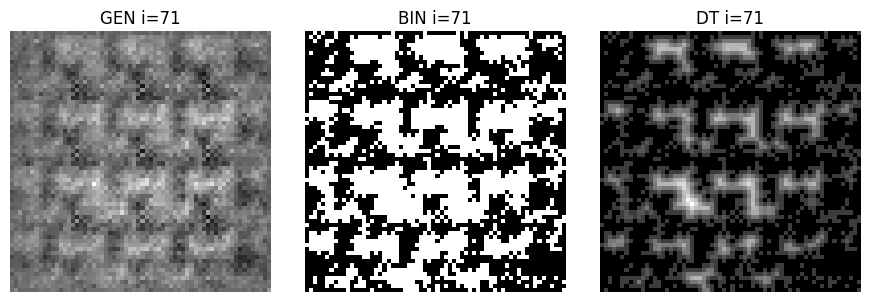

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.2496 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 198
Empty PD detected at sample 198 | dim=1 | Skipping padding and saving debug image...


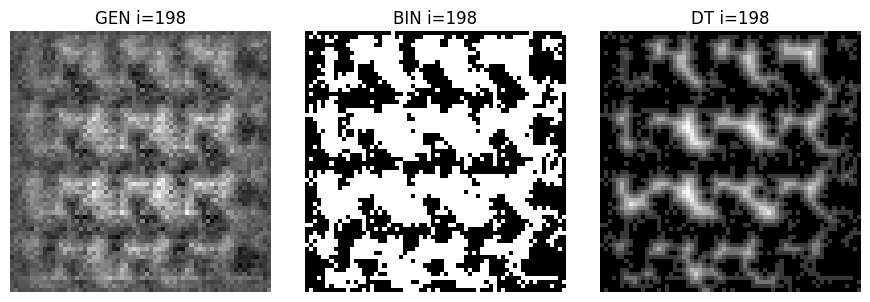

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.4698 seconds
[441/2000][0/1] D: -13.5286 G: -0.0418 T: 4.3094 W: 3.4772 Step: 441
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 261
Empty PD detected at sample 261 | dim=1 | Skipping padding and saving debug image...


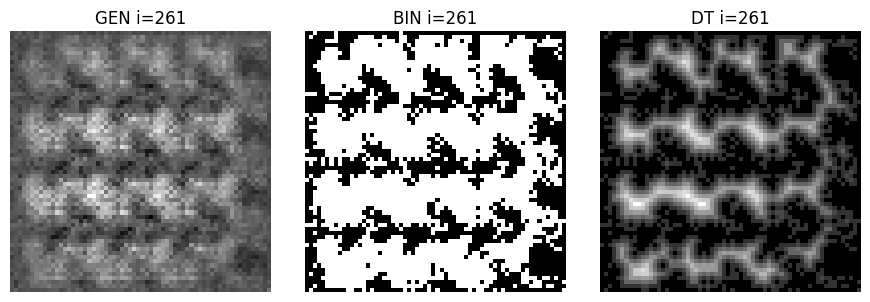

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.7477 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 190
Empty PD detected at sample 190 | dim=1 | Skipping padding and saving debug image...


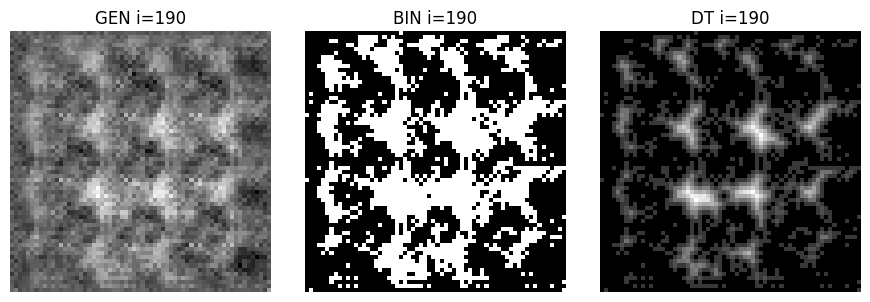

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 12.2675 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 125
Empty PD detected at sample 125 | dim=1 | Skipping padding and saving debug image...


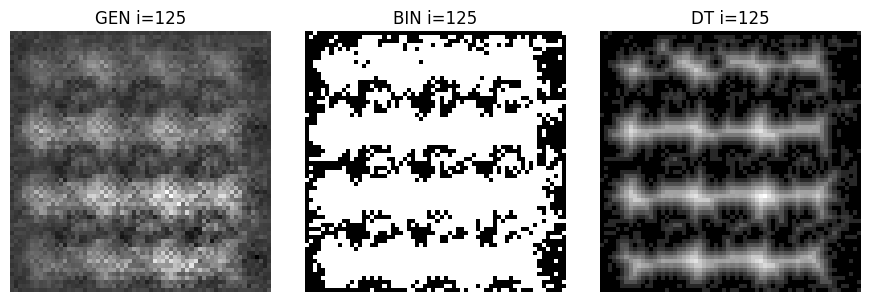

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[451/2000][0/1] D: -13.2782 G: -1.4395 T: 4.3417 W: 3.5429 Step: 451
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 102
Empty PD detected at sample 102 | dim=1 | Skipping padding and saving debug image...


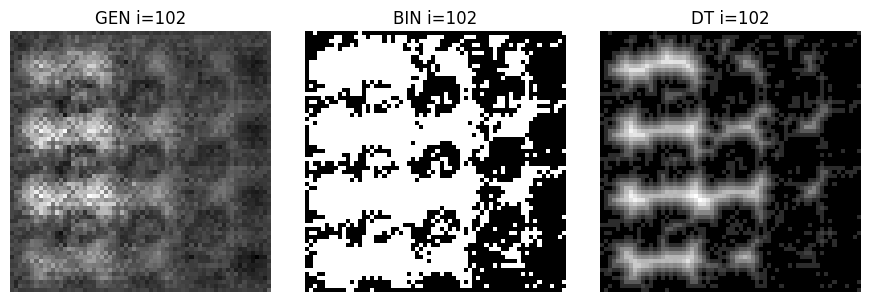

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 12.6098 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 72
Empty PD detected at sample 72 | dim=1 | Skipping padding and saving debug image...


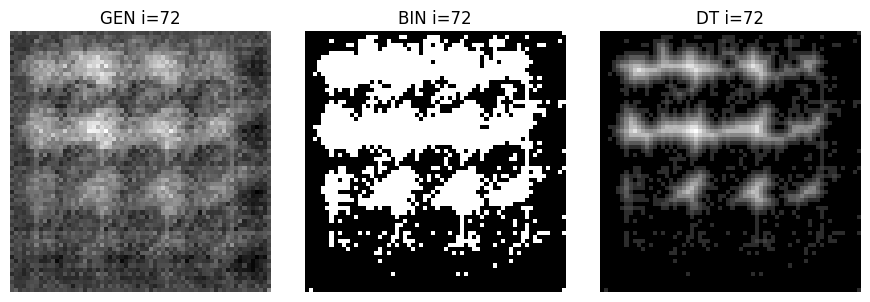

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 13.7565 seconds
[461/2000][0/1] D: -12.0306 G: -1.2154 T: 4.3147 W: 4.1260 Step: 461
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 299
Empty PD detected at sample 299 | dim=1 | Skipping padding and saving debug image...


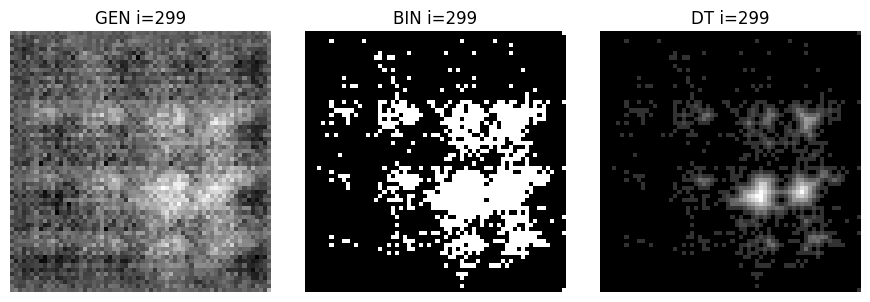

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 14.4234 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 15
Empty PD detected at sample 15 | dim=1 | Skipping padding and saving debug image...


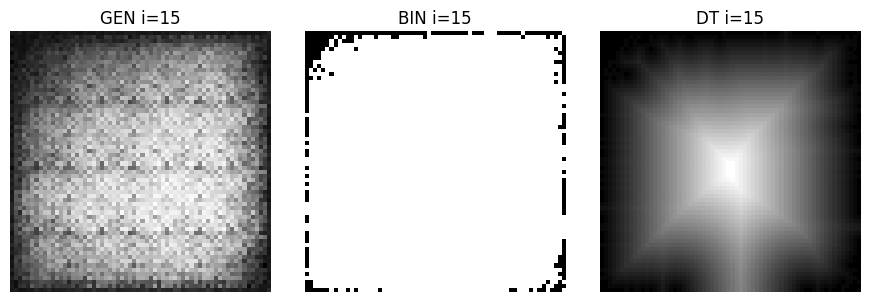

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 12.9210 seconds
[471/2000][0/1] D: -10.3955 G: 1.3394 T: 4.3216 W: 4.1680 Step: 471
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 293
Empty PD detected at sample 293 | dim=1 | Skipping padding and saving debug image...


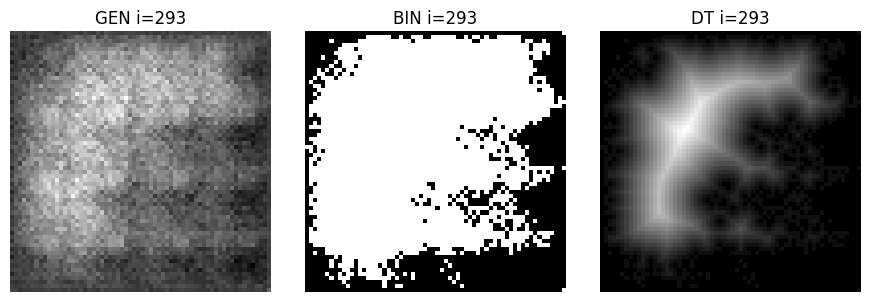

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 12.6715 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 322
Empty PD detected at sample 322 | dim=1 | Skipping padding and saving debug image...


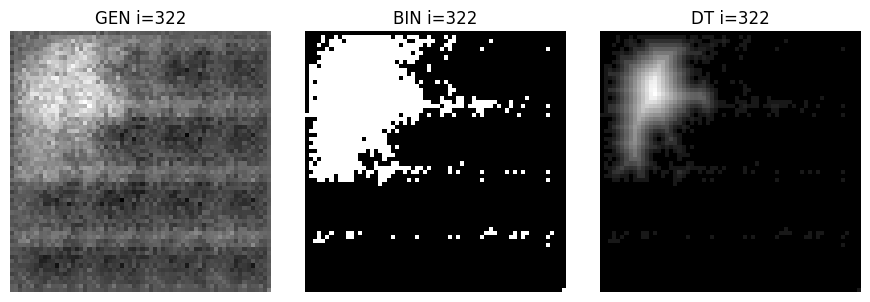

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 12.8689 seconds
[481/2000][0/1] D: -11.0638 G: 2.2000 T: 4.4138 W: 4.3400 Step: 481
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 198
Empty PD detected at sample 198 | dim=1 | Skipping padding and saving debug image...


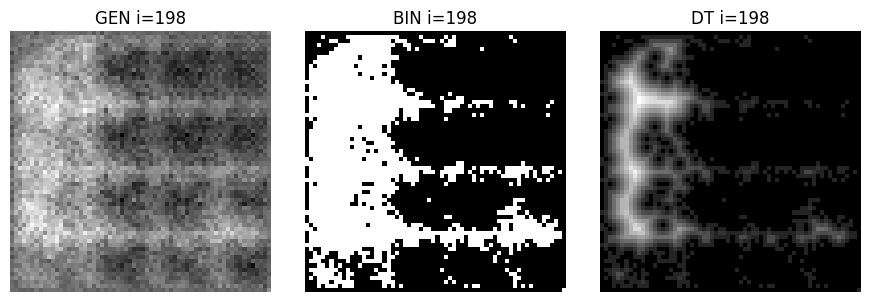

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.8852 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 66
Empty PD detected at sample 66 | dim=1 | Skipping padding and saving debug image...


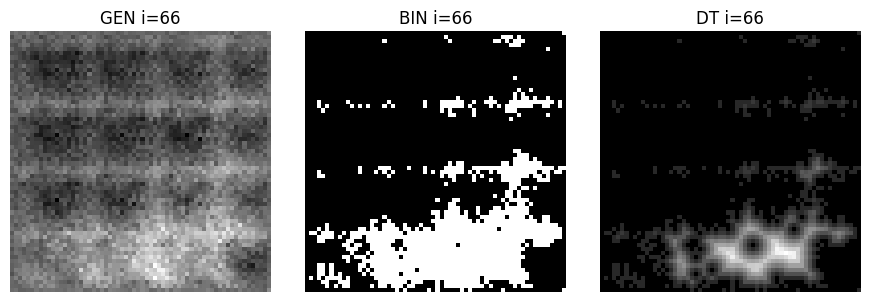

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.1102 seconds
[491/2000][0/1] D: -10.7655 G: -0.3368 T: 4.3929 W: 4.0565 Step: 491
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 65
Empty PD detected at sample 65 | dim=1 | Skipping padding and saving debug image...


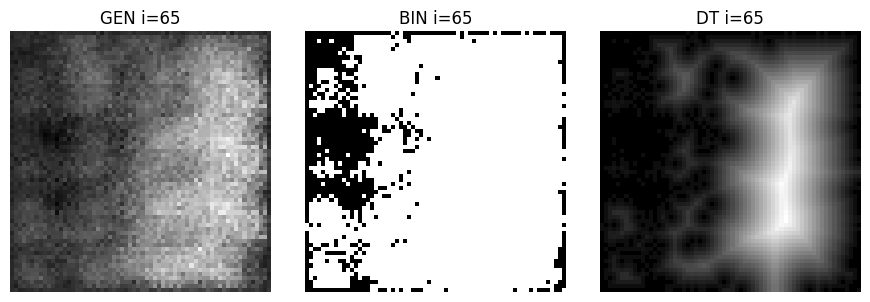

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.5853 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 131
Empty PD detected at sample 131 | dim=1 | Skipping padding and saving debug image...


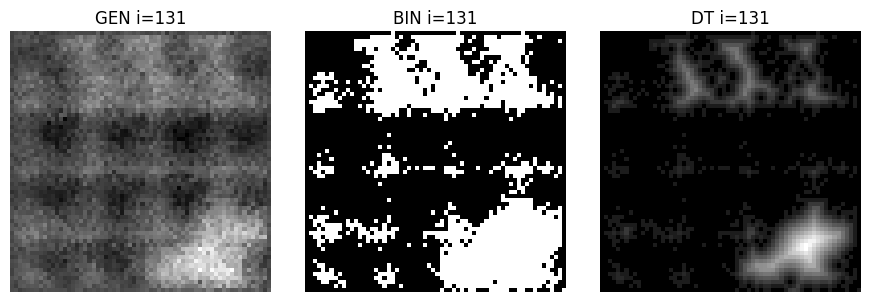

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.2155 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 173
Empty PD detected at sample 173 | dim=1 | Skipping padding and saving debug image...


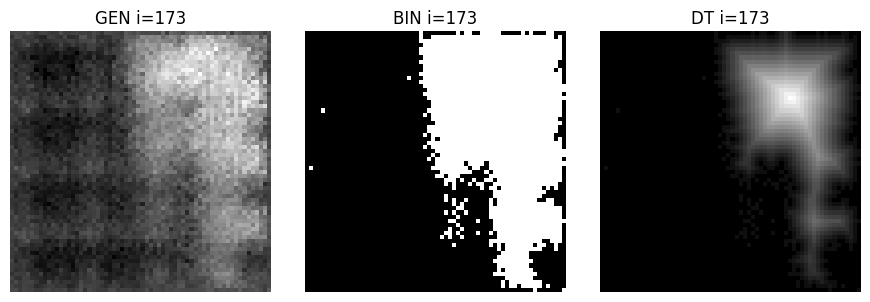

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[501/2000][0/1] D: -10.3874 G: 0.2402 T: 4.4280 W: 3.6660 Step: 501
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 150
Empty PD detected at sample 150 | dim=1 | Skipping padding and saving debug image...


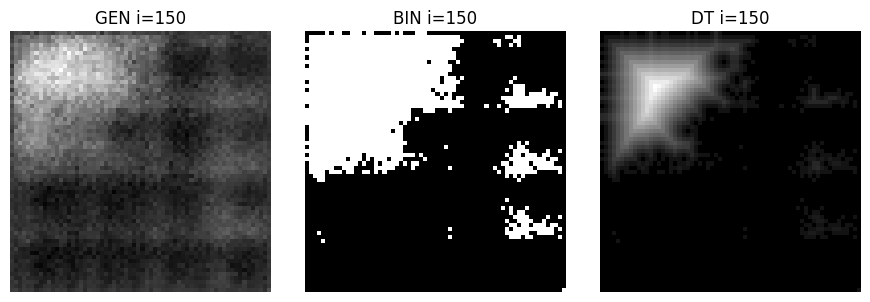

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 8.8469 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 288
Empty PD detected at sample 288 | dim=1 | Skipping padding and saving debug image...


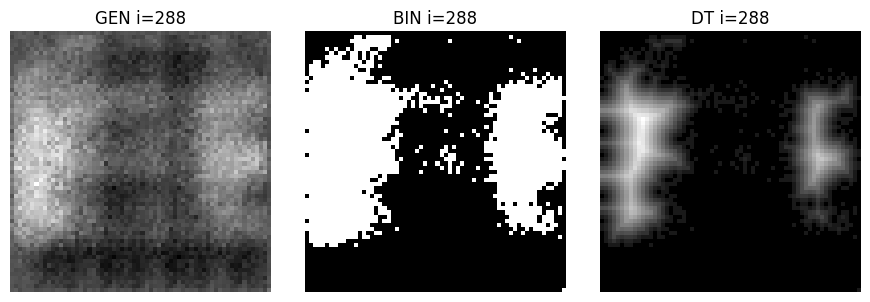

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 8.0394 seconds
[511/2000][0/1] D: -9.3604 G: -0.2703 T: 4.3995 W: 2.6345 Step: 511
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 64
Empty PD detected at sample 64 | dim=1 | Skipping padding and saving debug image...


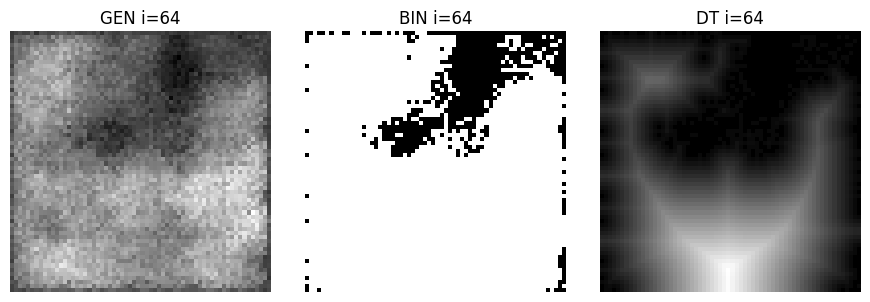

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 8.1717 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 54
Empty PD detected at sample 54 | dim=1 | Skipping padding and saving debug image...


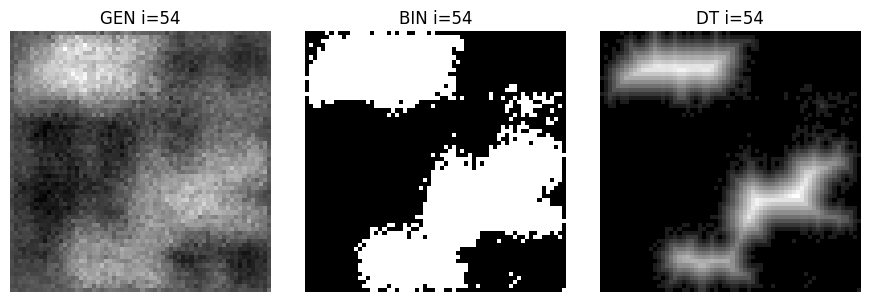

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 8.3875 seconds
[521/2000][0/1] D: -8.9250 G: 0.0922 T: 4.3799 W: 3.3156 Step: 521
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 50
Empty PD detected at sample 50 | dim=1 | Skipping padding and saving debug image...


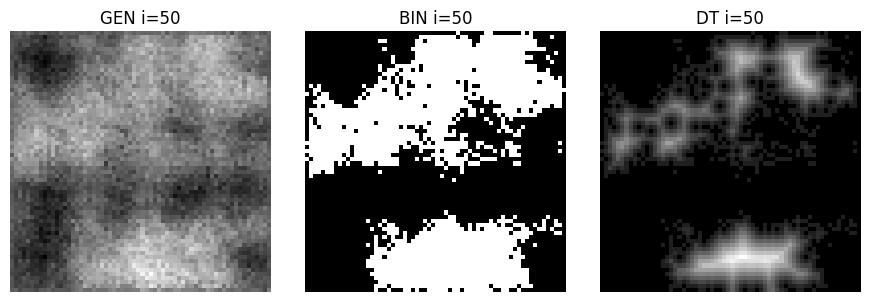

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.9273 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 233
Empty PD detected at sample 233 | dim=1 | Skipping padding and saving debug image...


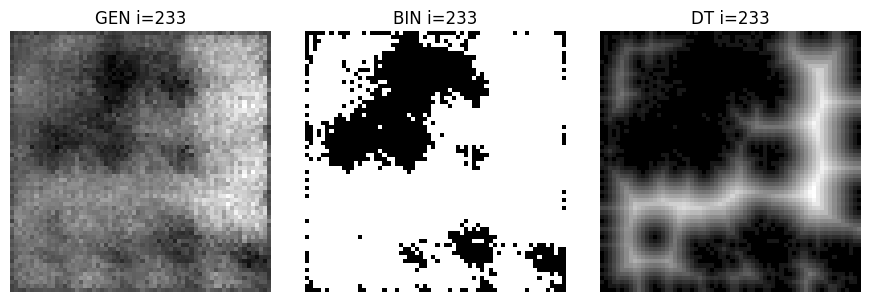

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.6193 seconds
[531/2000][0/1] D: -8.1608 G: -0.9445 T: 4.3826 W: 3.0007 Step: 531
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 105
Empty PD detected at sample 105 | dim=1 | Skipping padding and saving debug image...


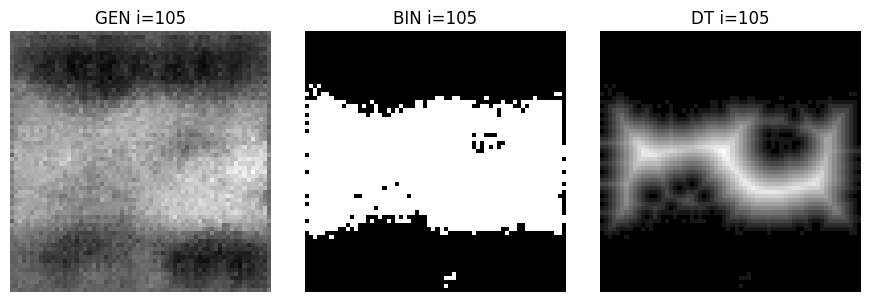

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.7200 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 152
Empty PD detected at sample 152 | dim=1 | Skipping padding and saving debug image...


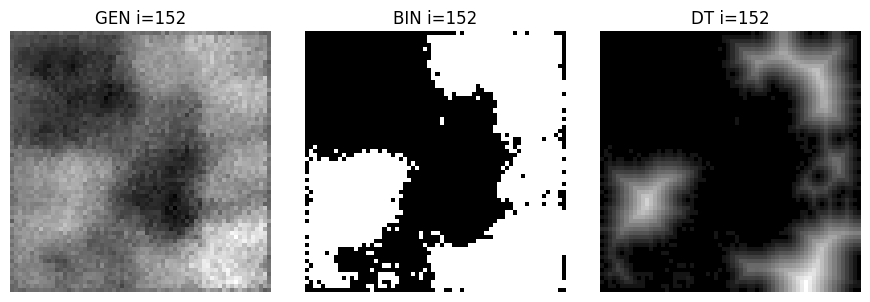

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.6677 seconds
[541/2000][0/1] D: -7.6086 G: -0.0629 T: 4.3660 W: 2.7948 Step: 541
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 243
Empty PD detected at sample 243 | dim=1 | Skipping padding and saving debug image...


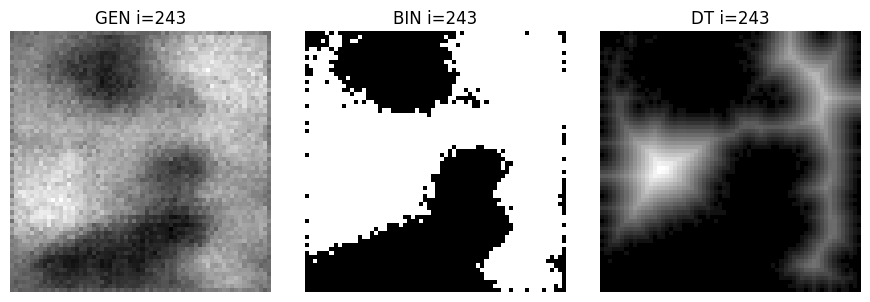

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.7731 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 36
Empty PD detected at sample 36 | dim=1 | Skipping padding and saving debug image...


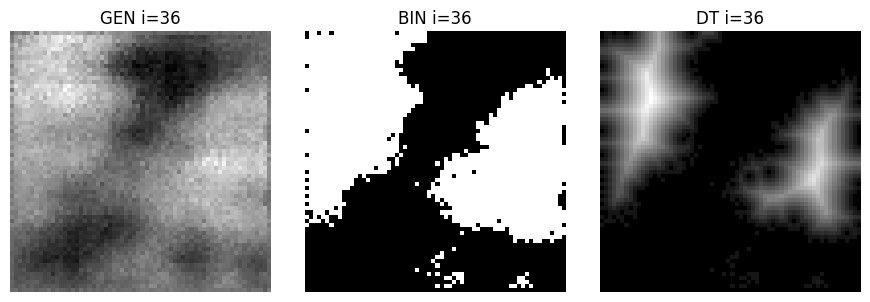

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.6976 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 295
Empty PD detected at sample 295 | dim=1 | Skipping padding and saving debug image...


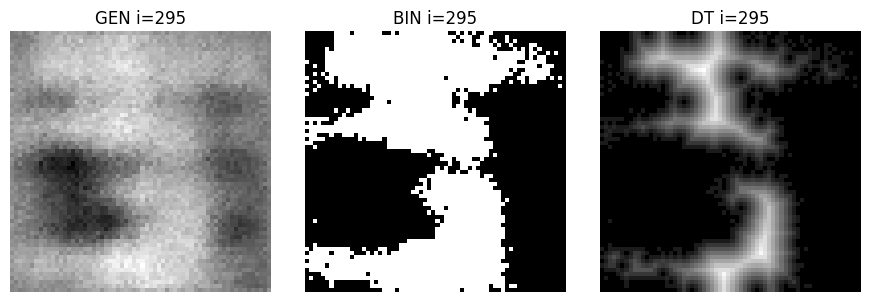

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[551/2000][0/1] D: -6.3246 G: -0.1240 T: 4.3532 W: 2.4227 Step: 551
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 23
Empty PD detected at sample 23 | dim=1 | Skipping padding and saving debug image...


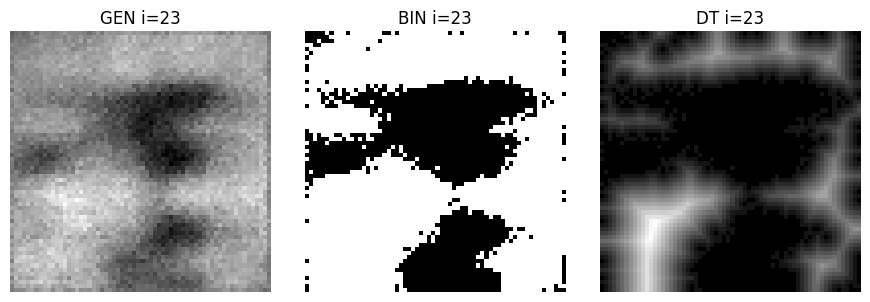

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.8871 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 24
Empty PD detected at sample 24 | dim=1 | Skipping padding and saving debug image...


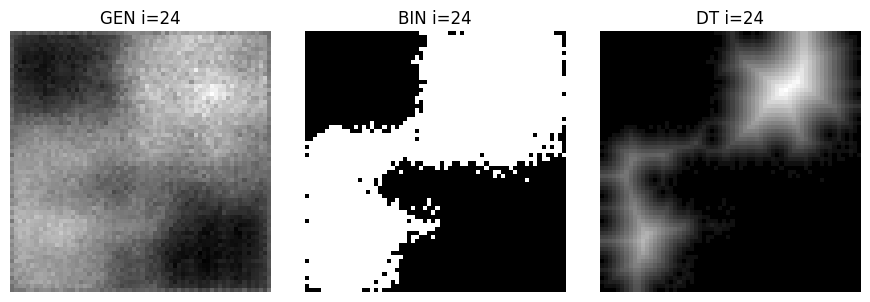

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.8484 seconds
[561/2000][0/1] D: -5.1784 G: 1.3571 T: 4.3157 W: 2.3041 Step: 561
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 254
Empty PD detected at sample 254 | dim=1 | Skipping padding and saving debug image...


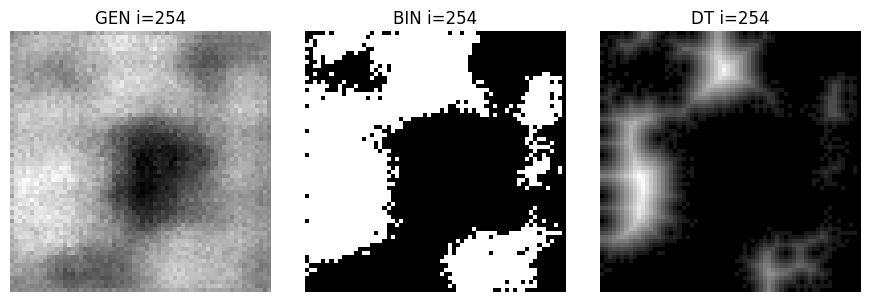

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.3767 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 237
Empty PD detected at sample 237 | dim=1 | Skipping padding and saving debug image...


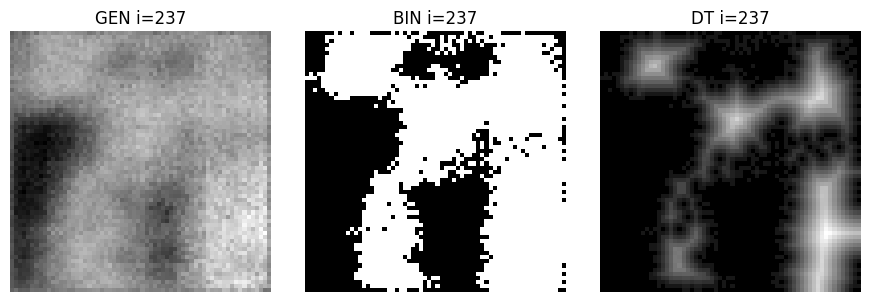

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.6509 seconds
[571/2000][0/1] D: -4.3135 G: 0.0976 T: 4.3300 W: 2.0471 Step: 571
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 57
Empty PD detected at sample 57 | dim=1 | Skipping padding and saving debug image...


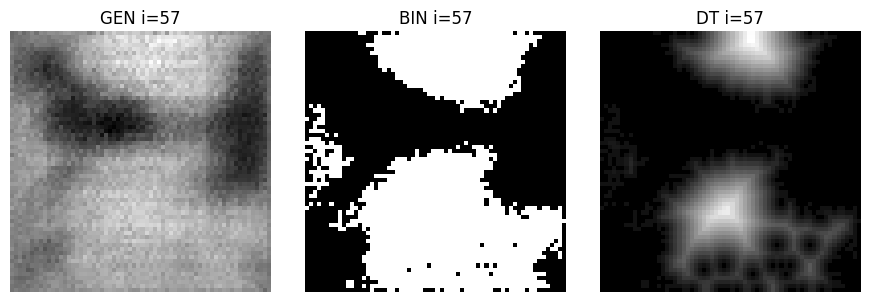

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.4923 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 316
Empty PD detected at sample 316 | dim=1 | Skipping padding and saving debug image...


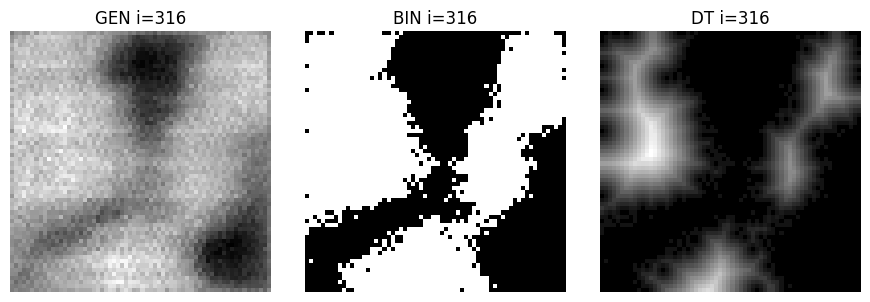

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.4119 seconds
[581/2000][0/1] D: -4.9740 G: 0.8808 T: 4.3004 W: 2.1035 Step: 581
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 293
Empty PD detected at sample 293 | dim=1 | Skipping padding and saving debug image...


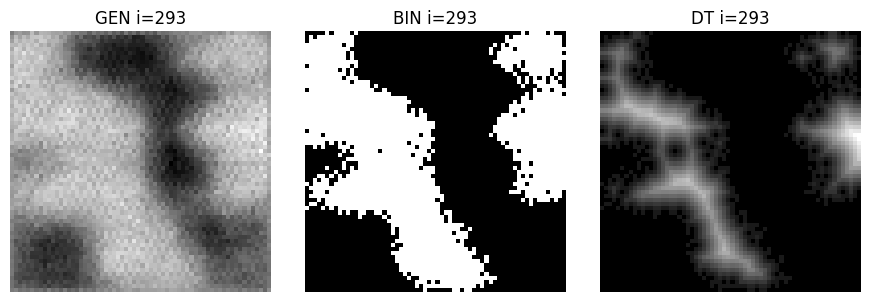

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.8630 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 307
Empty PD detected at sample 307 | dim=1 | Skipping padding and saving debug image...


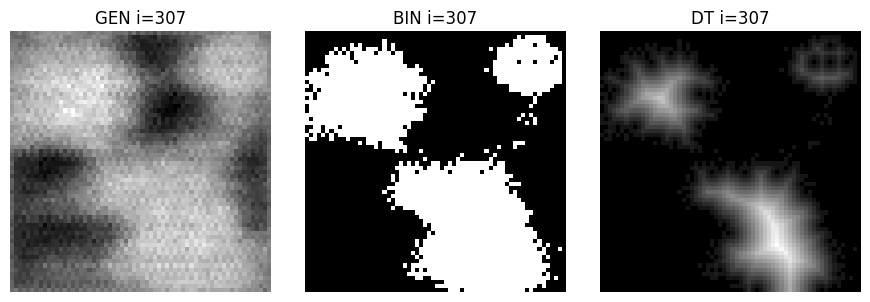

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.8911 seconds
[591/2000][0/1] D: -4.7567 G: 0.0776 T: 4.3246 W: 2.4109 Step: 591
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 23
Empty PD detected at sample 23 | dim=1 | Skipping padding and saving debug image...


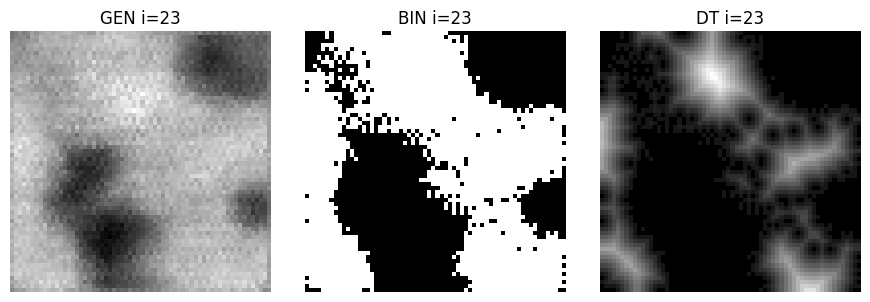

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.7083 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 150
Empty PD detected at sample 150 | dim=1 | Skipping padding and saving debug image...


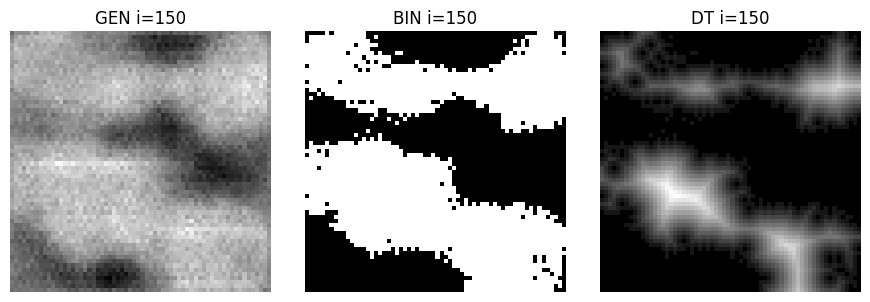

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.5993 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 216
Empty PD detected at sample 216 | dim=1 | Skipping padding and saving debug image...


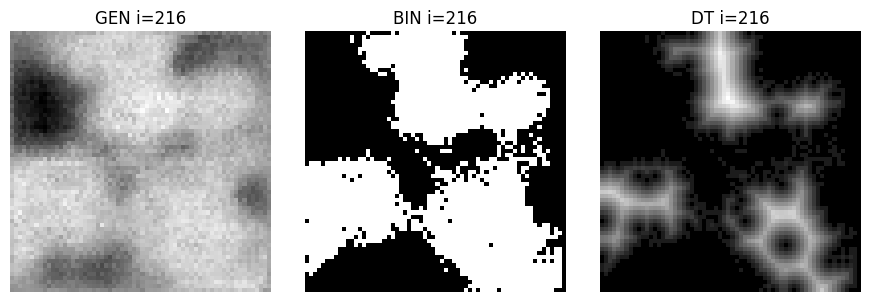

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[601/2000][0/1] D: -4.8731 G: 1.7644 T: 4.3077 W: 2.4671 Step: 601
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 282
Empty PD detected at sample 282 | dim=1 | Skipping padding and saving debug image...


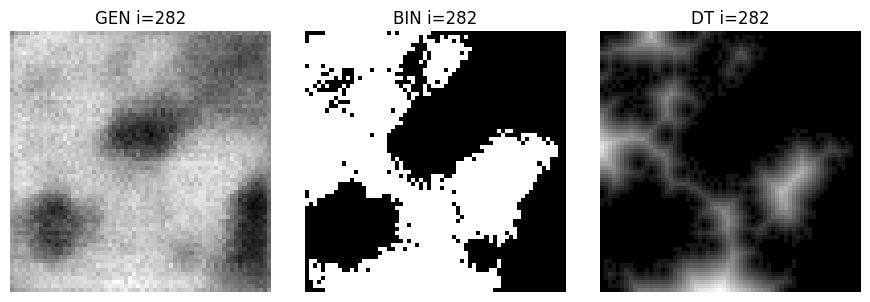

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.5768 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 2
Empty PD detected at sample 2 | dim=1 | Skipping padding and saving debug image...


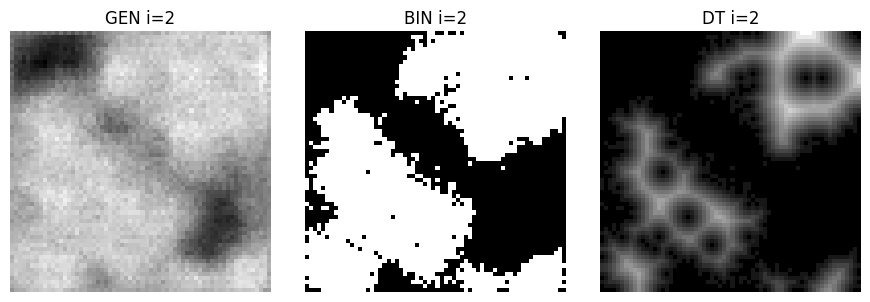

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.6031 seconds
[611/2000][0/1] D: -4.6267 G: -1.1744 T: 4.3456 W: 2.9430 Step: 611
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 169
Empty PD detected at sample 169 | dim=1 | Skipping padding and saving debug image...


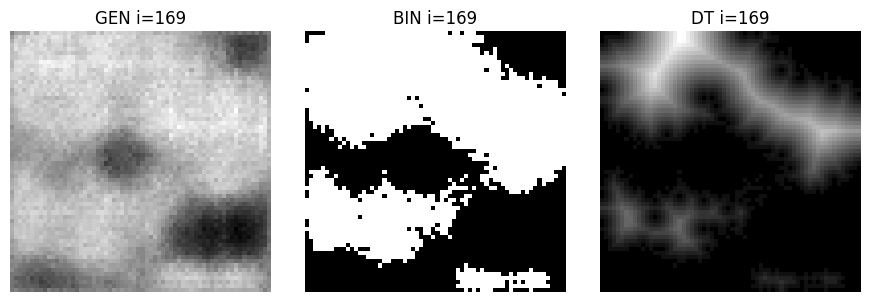

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.2669 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 164
Empty PD detected at sample 164 | dim=1 | Skipping padding and saving debug image...


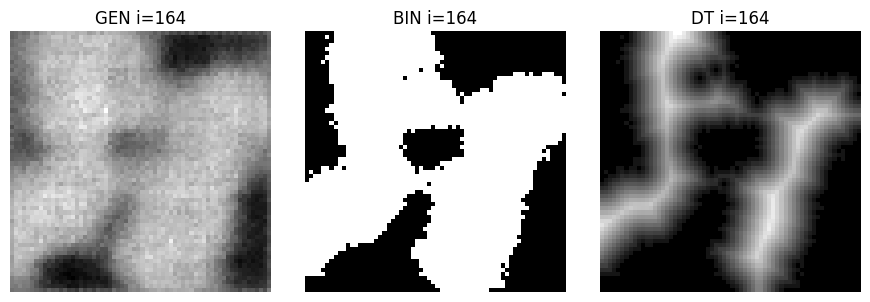

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.0611 seconds
[621/2000][0/1] D: -3.6807 G: 2.6826 T: 4.2731 W: 1.4717 Step: 621
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 198
Empty PD detected at sample 198 | dim=1 | Skipping padding and saving debug image...


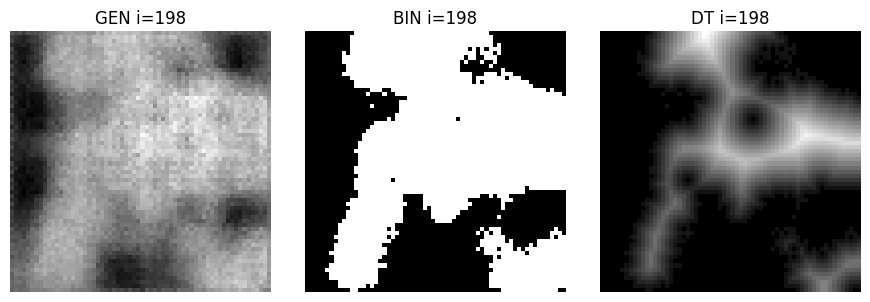

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.0819 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 279
Empty PD detected at sample 279 | dim=1 | Skipping padding and saving debug image...


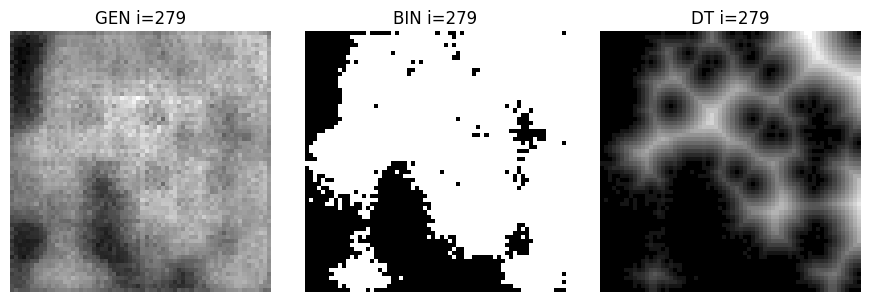

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.1900 seconds
[631/2000][0/1] D: -4.7960 G: 3.4622 T: 4.2878 W: 1.5010 Step: 631
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 290
Empty PD detected at sample 290 | dim=1 | Skipping padding and saving debug image...


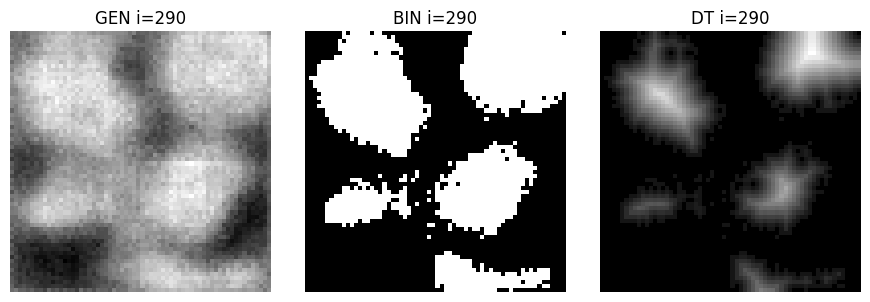

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.1941 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 219
Empty PD detected at sample 219 | dim=1 | Skipping padding and saving debug image...


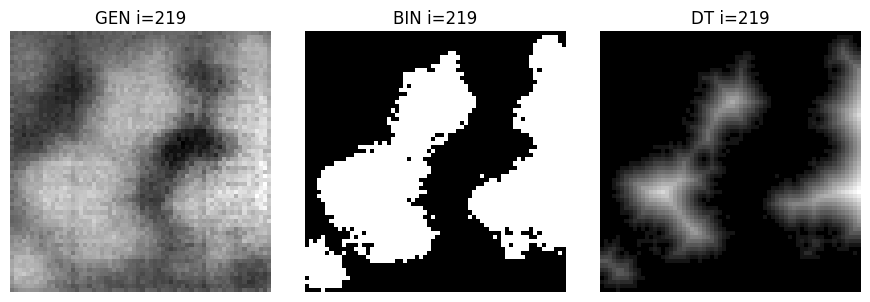

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.1222 seconds
[641/2000][0/1] D: -4.3749 G: -1.5408 T: 4.3813 W: 1.5964 Step: 641
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 15
Empty PD detected at sample 15 | dim=1 | Skipping padding and saving debug image...


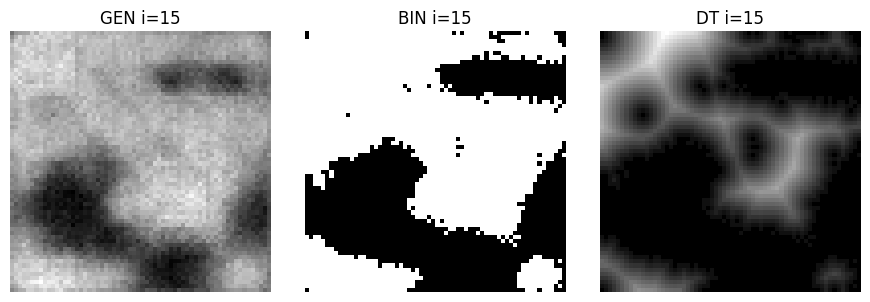

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.0447 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 81
Empty PD detected at sample 81 | dim=1 | Skipping padding and saving debug image...


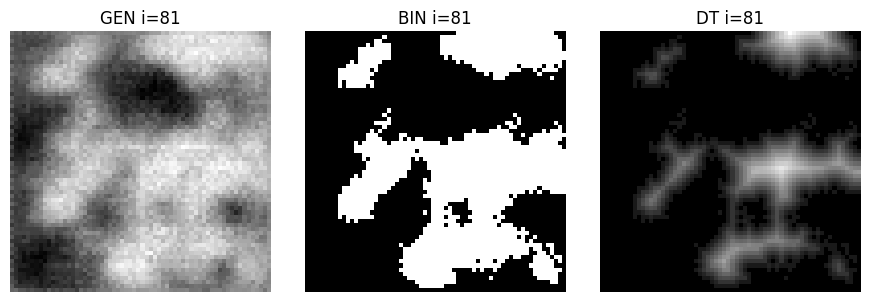

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9140 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 193
Empty PD detected at sample 193 | dim=1 | Skipping padding and saving debug image...


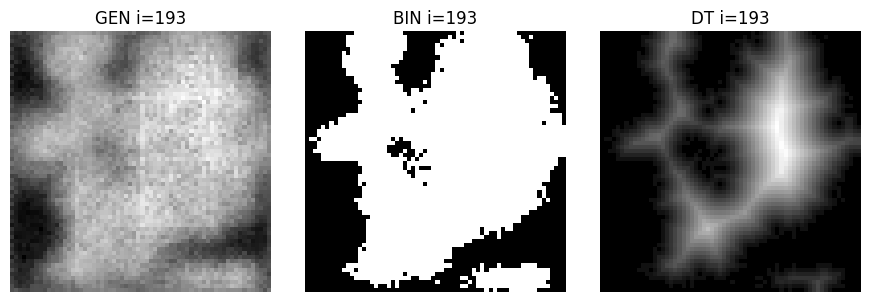

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[651/2000][0/1] D: -4.0595 G: 1.3525 T: 4.3137 W: 1.5746 Step: 651
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 245
Empty PD detected at sample 245 | dim=1 | Skipping padding and saving debug image...


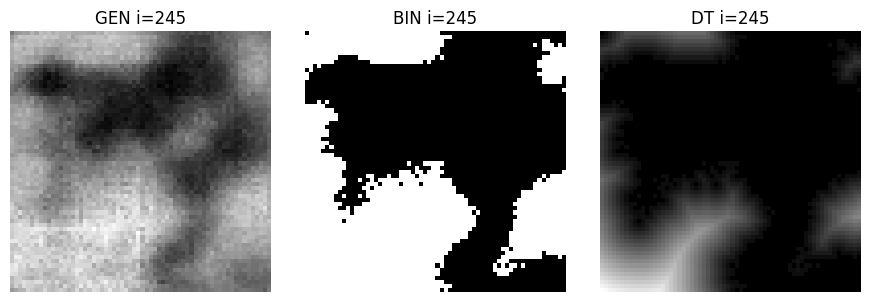

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9201 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 87
Empty PD detected at sample 87 | dim=1 | Skipping padding and saving debug image...


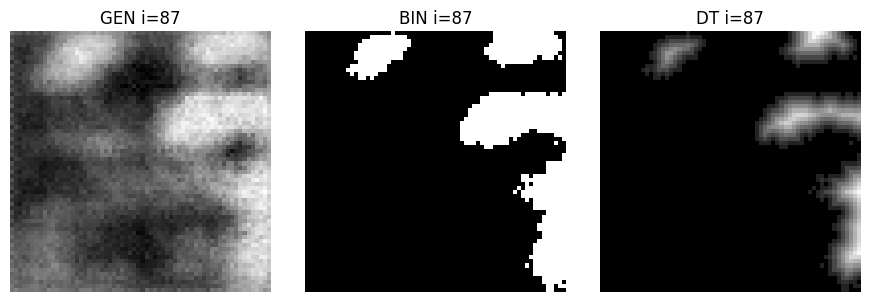

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9900 seconds
[661/2000][0/1] D: -3.5933 G: 0.5941 T: 4.3407 W: 1.3418 Step: 661
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 272
Empty PD detected at sample 272 | dim=1 | Skipping padding and saving debug image...


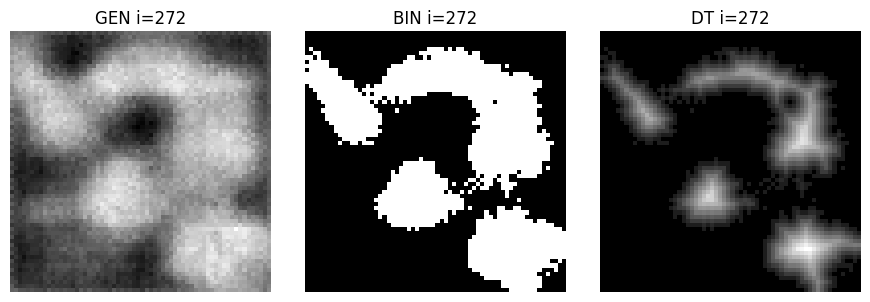

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.0363 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 96
Empty PD detected at sample 96 | dim=1 | Skipping padding and saving debug image...


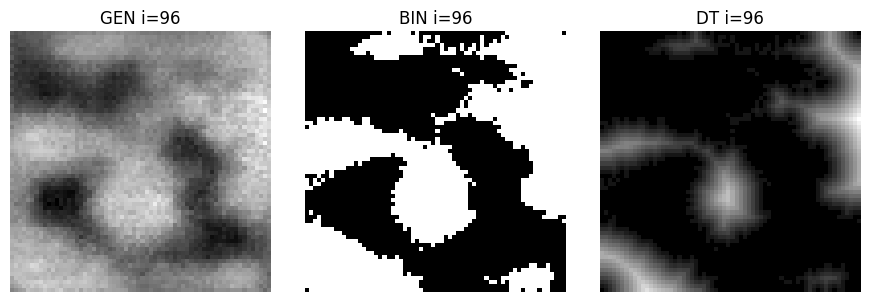

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9081 seconds
[671/2000][0/1] D: -3.6713 G: 0.4409 T: 4.3288 W: 1.2236 Step: 671
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 284
Empty PD detected at sample 284 | dim=1 | Skipping padding and saving debug image...


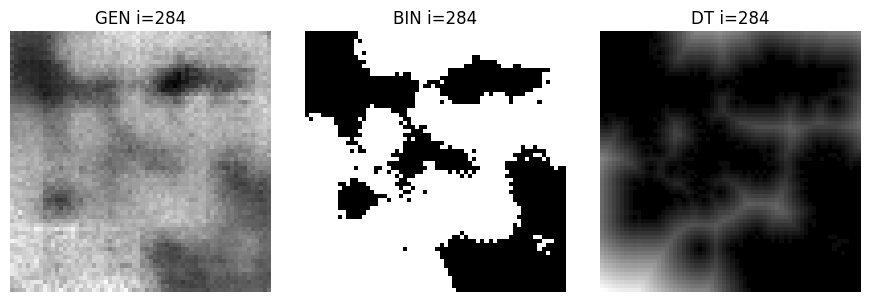

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9037 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 40
Empty PD detected at sample 40 | dim=1 | Skipping padding and saving debug image...


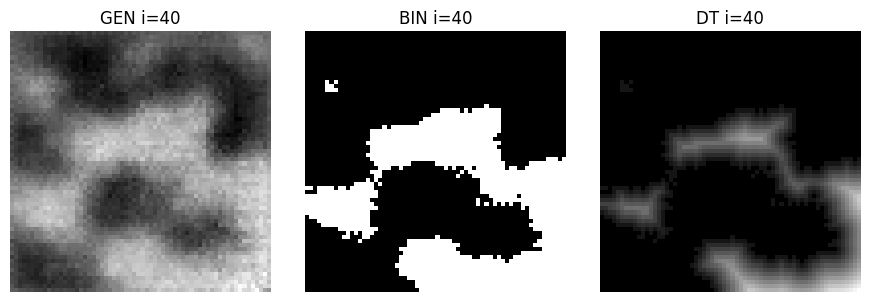

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9449 seconds
[681/2000][0/1] D: -3.4921 G: 1.3102 T: 4.3289 W: 1.5089 Step: 681
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 202
Empty PD detected at sample 202 | dim=1 | Skipping padding and saving debug image...


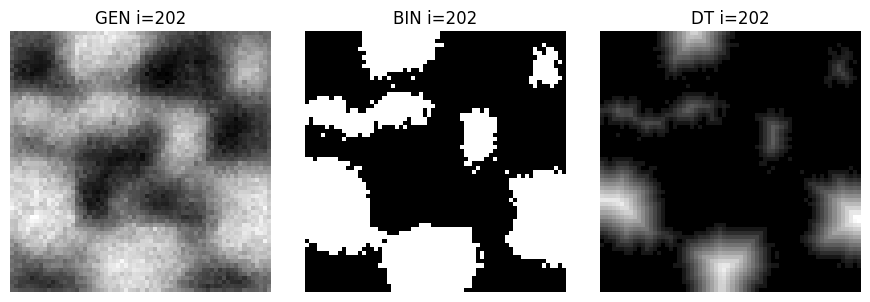

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9781 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 131
Empty PD detected at sample 131 | dim=1 | Skipping padding and saving debug image...


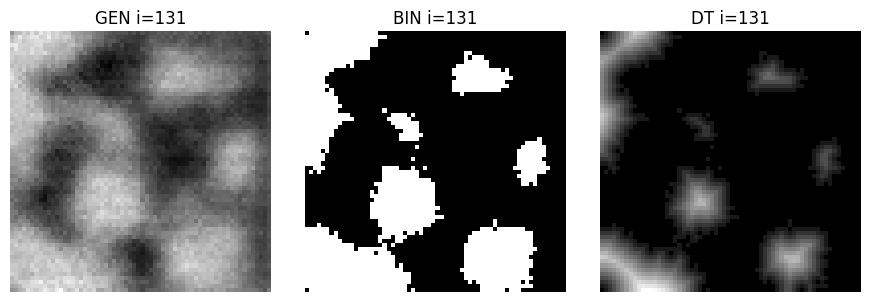

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8614 seconds
[691/2000][0/1] D: -3.5644 G: 0.3747 T: 4.3317 W: 1.1948 Step: 691
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 175
Empty PD detected at sample 175 | dim=1 | Skipping padding and saving debug image...


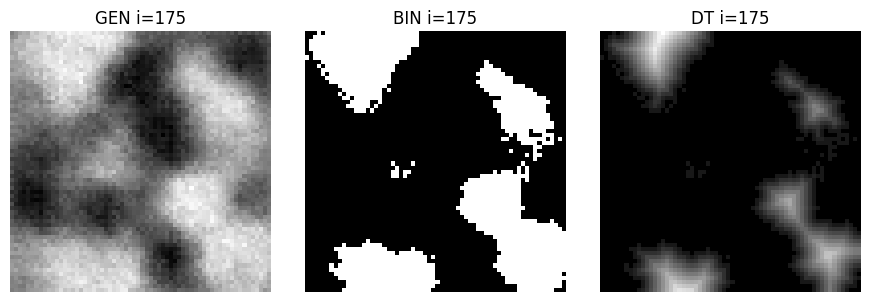

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8611 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 190
Empty PD detected at sample 190 | dim=1 | Skipping padding and saving debug image...


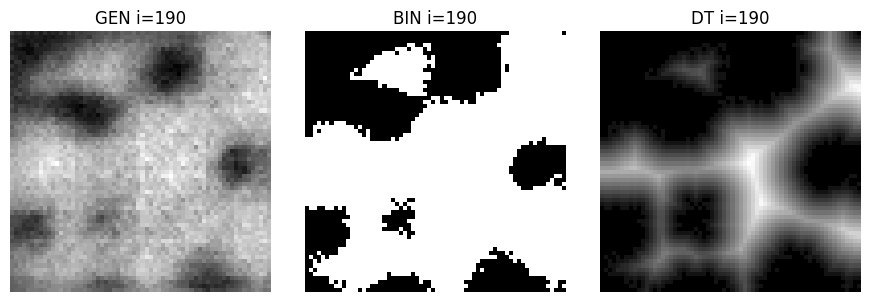

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9051 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 51
Empty PD detected at sample 51 | dim=1 | Skipping padding and saving debug image...


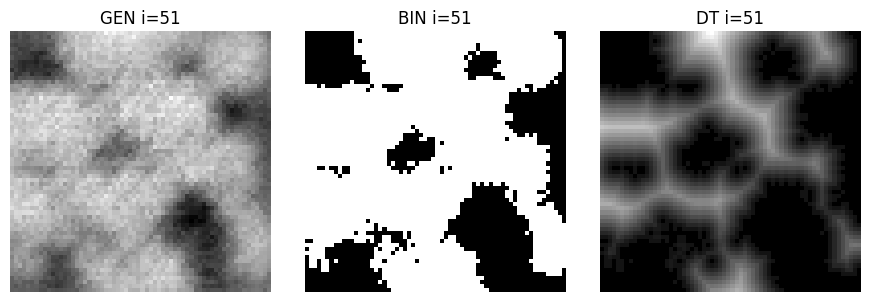

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[701/2000][0/1] D: -3.5186 G: 0.2038 T: 4.3277 W: 1.1340 Step: 701
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 195
Empty PD detected at sample 195 | dim=1 | Skipping padding and saving debug image...


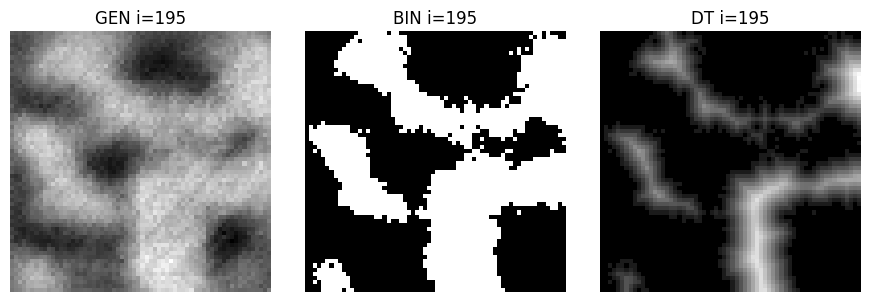

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9036 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 285
Empty PD detected at sample 285 | dim=1 | Skipping padding and saving debug image...


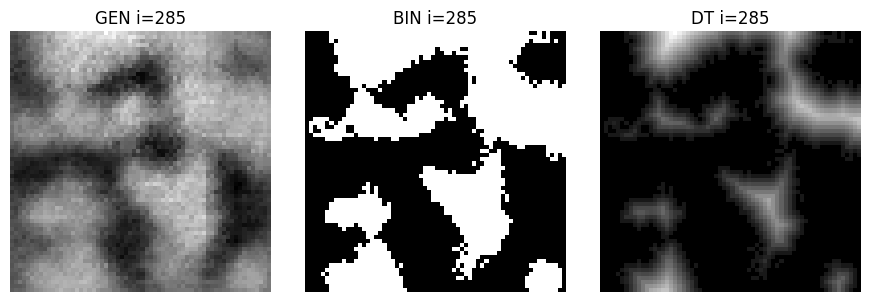

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9206 seconds
[711/2000][0/1] D: -3.6886 G: 0.7035 T: 4.3234 W: 1.2583 Step: 711
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 36
Empty PD detected at sample 36 | dim=1 | Skipping padding and saving debug image...


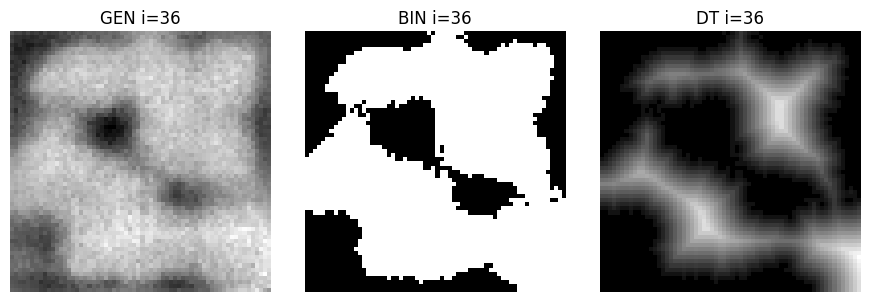

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8611 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 203
Empty PD detected at sample 203 | dim=1 | Skipping padding and saving debug image...


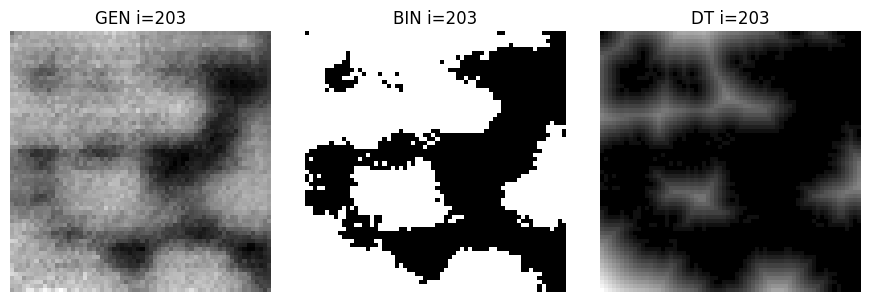

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9453 seconds
[721/2000][0/1] D: -3.5495 G: 0.4964 T: 4.3309 W: 1.3849 Step: 721
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 233
Empty PD detected at sample 233 | dim=1 | Skipping padding and saving debug image...


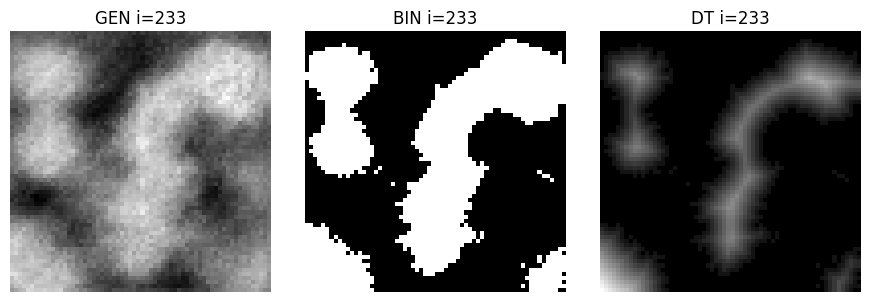

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9237 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 149
Empty PD detected at sample 149 | dim=1 | Skipping padding and saving debug image...


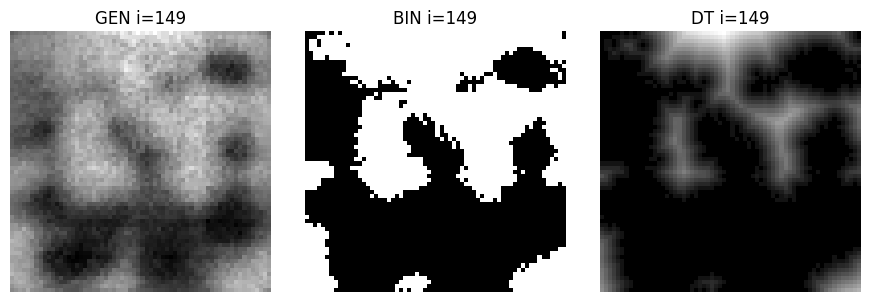

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8963 seconds
[731/2000][0/1] D: -3.7895 G: 0.7121 T: 4.3150 W: 1.2121 Step: 731
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 233
Empty PD detected at sample 233 | dim=1 | Skipping padding and saving debug image...


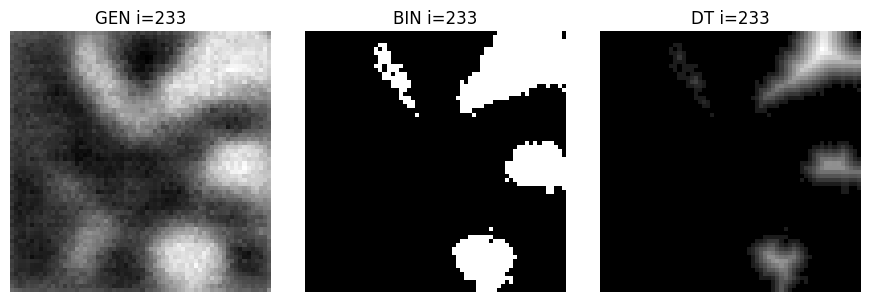

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9257 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 41
Empty PD detected at sample 41 | dim=1 | Skipping padding and saving debug image...


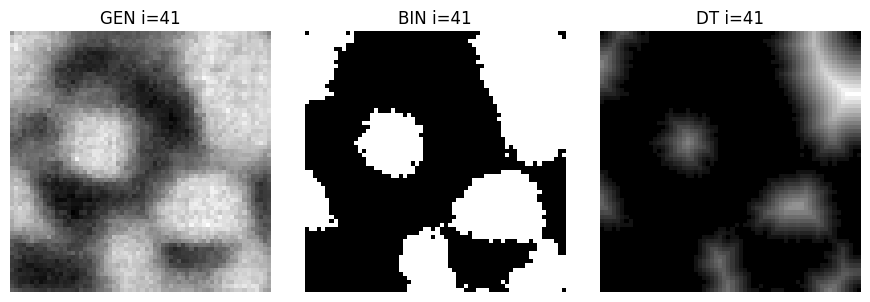

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8633 seconds
[741/2000][0/1] D: -3.7179 G: 0.1547 T: 4.3069 W: 1.1466 Step: 741
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 246
Empty PD detected at sample 246 | dim=1 | Skipping padding and saving debug image...


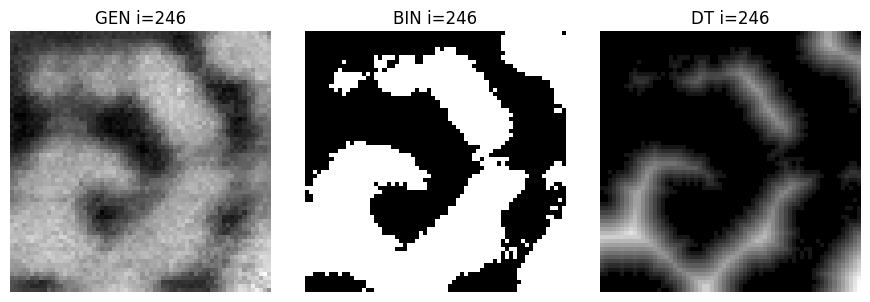

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8775 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 320
Empty PD detected at sample 320 | dim=1 | Skipping padding and saving debug image...


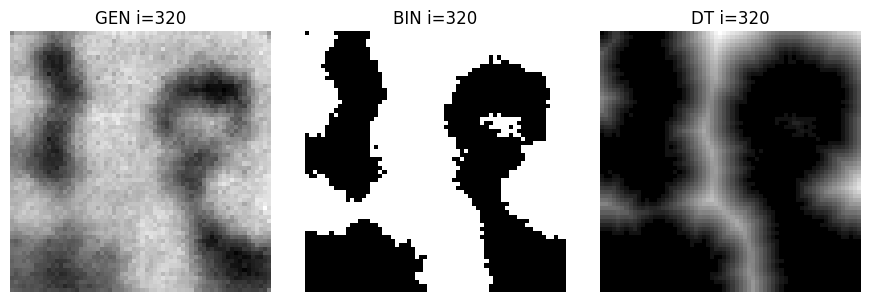

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8763 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 306
Empty PD detected at sample 306 | dim=1 | Skipping padding and saving debug image...


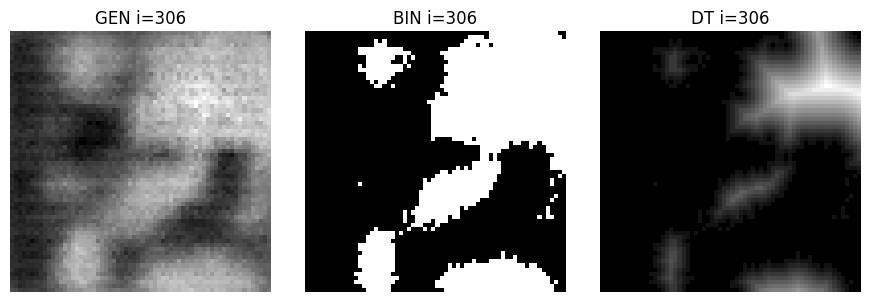

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[751/2000][0/1] D: -3.7601 G: 2.0990 T: 4.3107 W: 1.3148 Step: 751
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 209
Empty PD detected at sample 209 | dim=1 | Skipping padding and saving debug image...


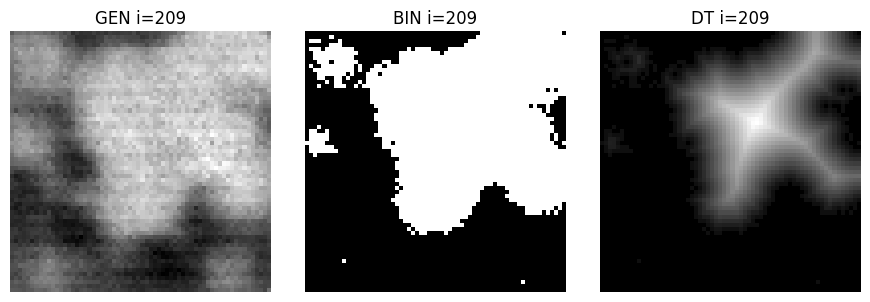

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9067 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 31
Empty PD detected at sample 31 | dim=1 | Skipping padding and saving debug image...


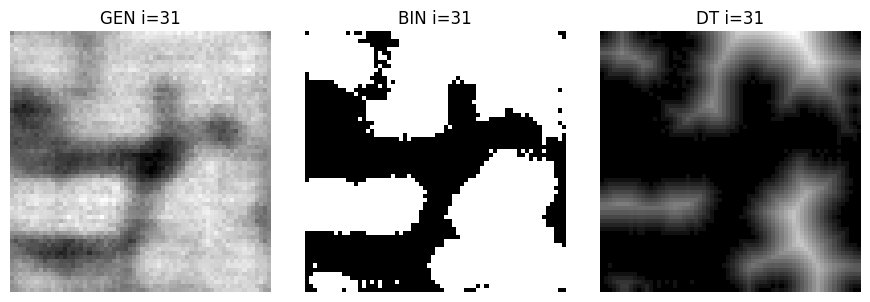

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8062 seconds
[761/2000][0/1] D: -0.9275 G: -4.4194 T: 4.2939 W: 1.3011 Step: 761
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 53
Empty PD detected at sample 53 | dim=1 | Skipping padding and saving debug image...


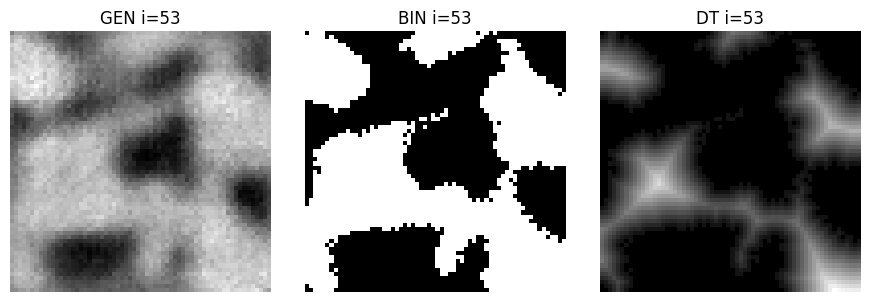

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.7554 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 305
Empty PD detected at sample 305 | dim=1 | Skipping padding and saving debug image...


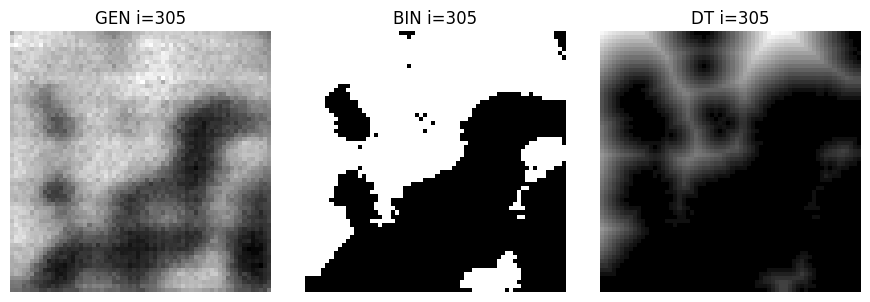

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9684 seconds
[771/2000][0/1] D: -2.7245 G: 6.6155 T: 4.2219 W: 1.2434 Step: 771
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 166
Empty PD detected at sample 166 | dim=1 | Skipping padding and saving debug image...


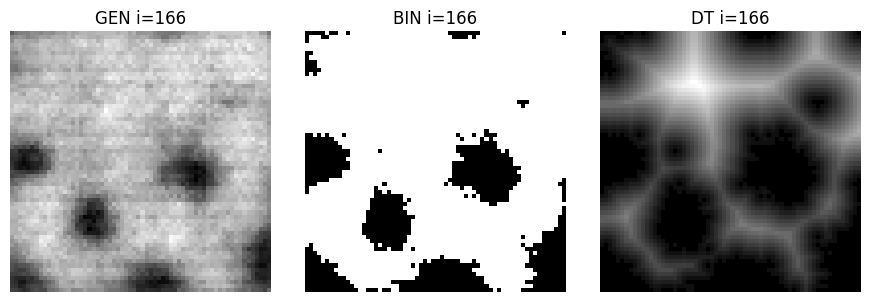

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9737 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 78
Empty PD detected at sample 78 | dim=1 | Skipping padding and saving debug image...


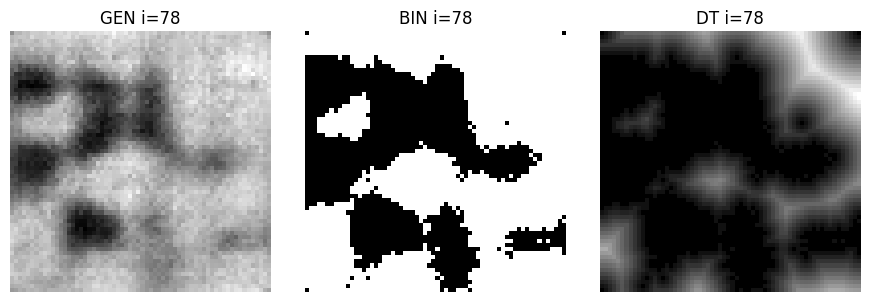

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9066 seconds
[781/2000][0/1] D: -3.0417 G: 3.5141 T: 4.3127 W: 1.5211 Step: 781
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 268
Empty PD detected at sample 268 | dim=1 | Skipping padding and saving debug image...


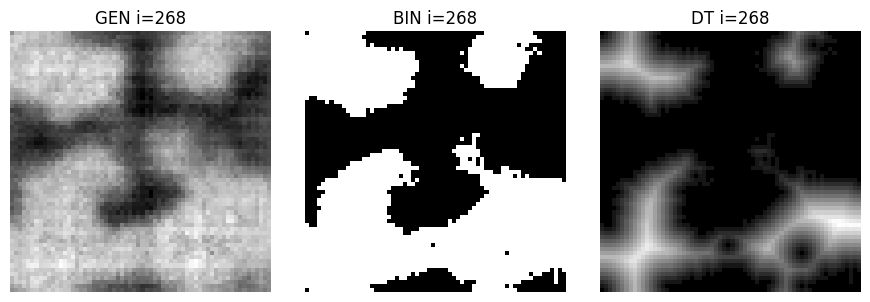

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9316 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 57
Empty PD detected at sample 57 | dim=1 | Skipping padding and saving debug image...


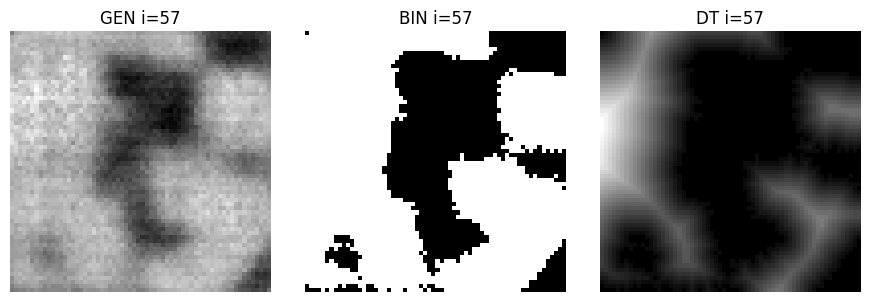

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8223 seconds
[791/2000][0/1] D: -3.0781 G: -1.3167 T: 4.3101 W: 1.2680 Step: 791
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 145
Empty PD detected at sample 145 | dim=1 | Skipping padding and saving debug image...


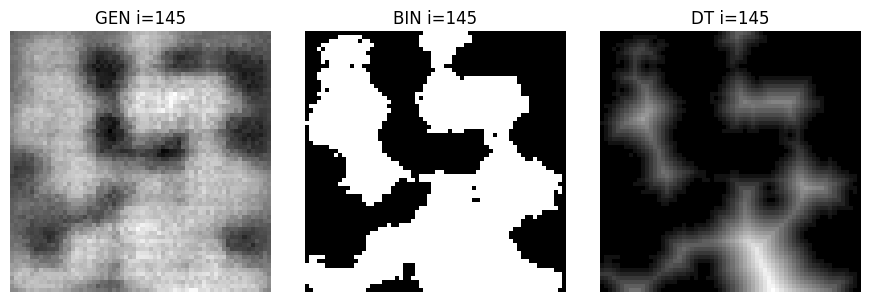

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8505 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 170
Empty PD detected at sample 170 | dim=1 | Skipping padding and saving debug image...


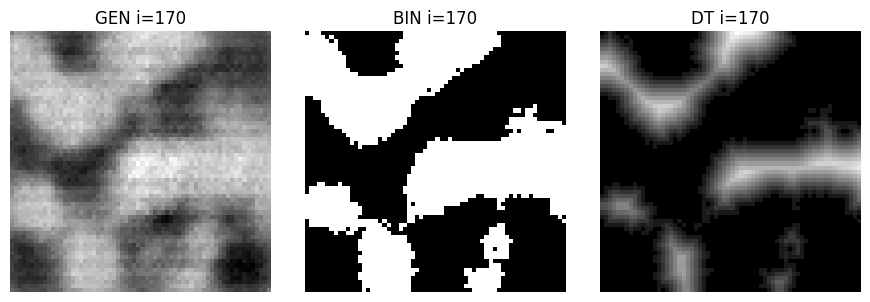

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8567 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 159
Empty PD detected at sample 159 | dim=1 | Skipping padding and saving debug image...


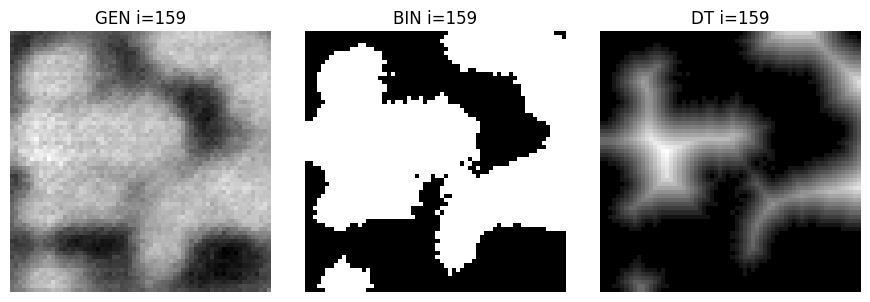

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[801/2000][0/1] D: -3.2849 G: 2.1397 T: 4.3285 W: 1.0881 Step: 801
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 54
Empty PD detected at sample 54 | dim=1 | Skipping padding and saving debug image...


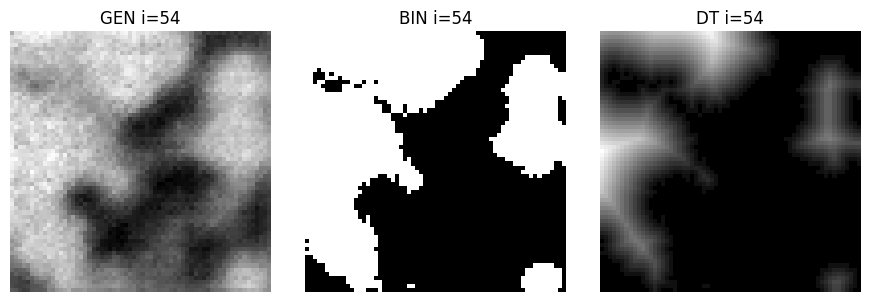

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8152 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 104
Empty PD detected at sample 104 | dim=1 | Skipping padding and saving debug image...


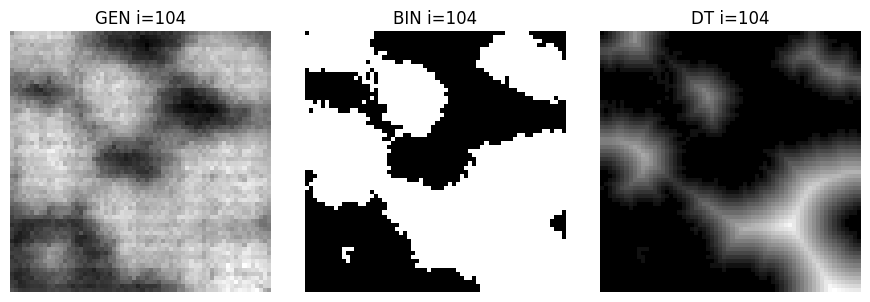

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9342 seconds
[811/2000][0/1] D: -3.0461 G: 1.7305 T: 4.3004 W: 1.3566 Step: 811
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 264
Empty PD detected at sample 264 | dim=1 | Skipping padding and saving debug image...


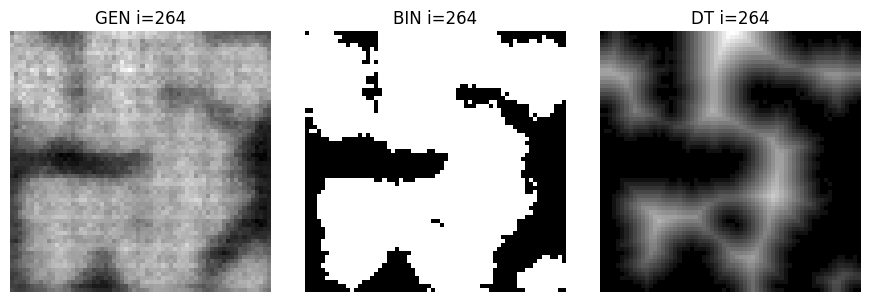

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9236 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 302
Empty PD detected at sample 302 | dim=1 | Skipping padding and saving debug image...


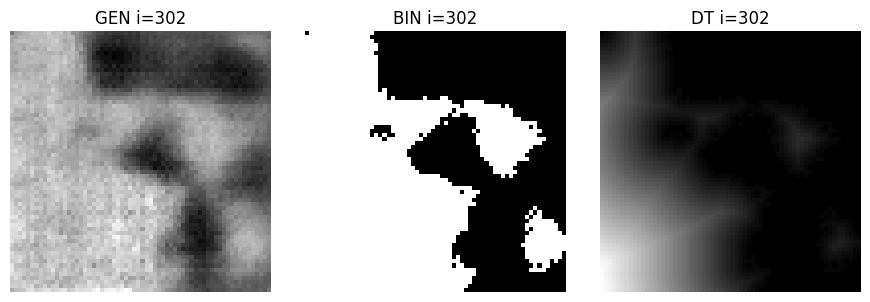

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8594 seconds
[821/2000][0/1] D: -3.3254 G: -0.4679 T: 4.3263 W: 1.4013 Step: 821
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 147
Empty PD detected at sample 147 | dim=1 | Skipping padding and saving debug image...


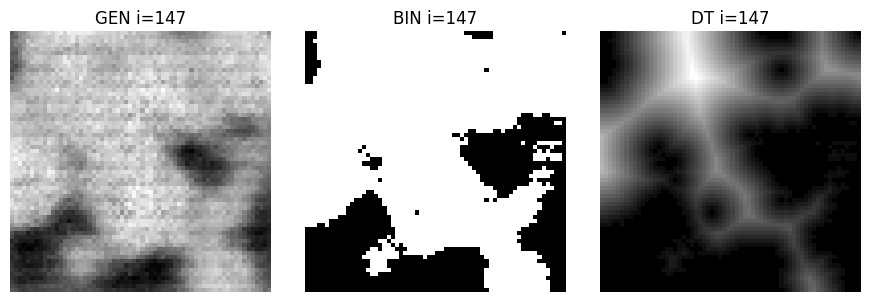

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9101 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 106
Empty PD detected at sample 106 | dim=1 | Skipping padding and saving debug image...


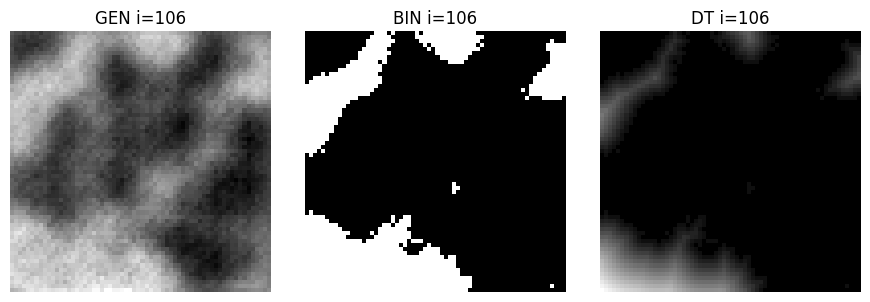

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8220 seconds
[831/2000][0/1] D: -3.2710 G: 0.4301 T: 4.3310 W: 1.2262 Step: 831
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 218
Empty PD detected at sample 218 | dim=1 | Skipping padding and saving debug image...


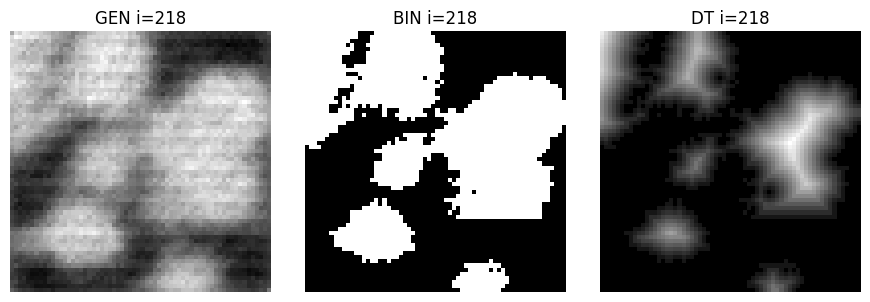

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8212 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 254
Empty PD detected at sample 254 | dim=1 | Skipping padding and saving debug image...


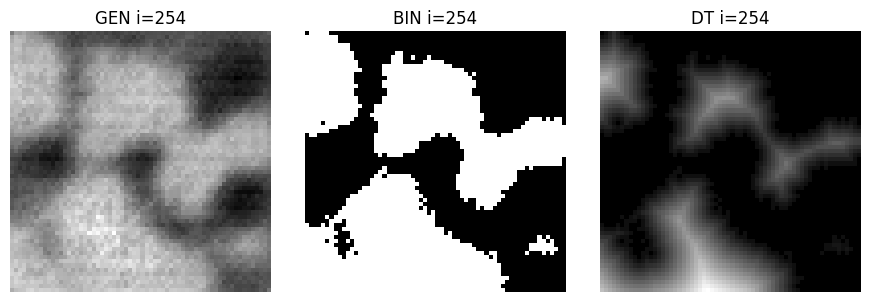

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8108 seconds
[841/2000][0/1] D: -3.4262 G: 1.6101 T: 4.3131 W: 1.2468 Step: 841
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 259
Empty PD detected at sample 259 | dim=1 | Skipping padding and saving debug image...


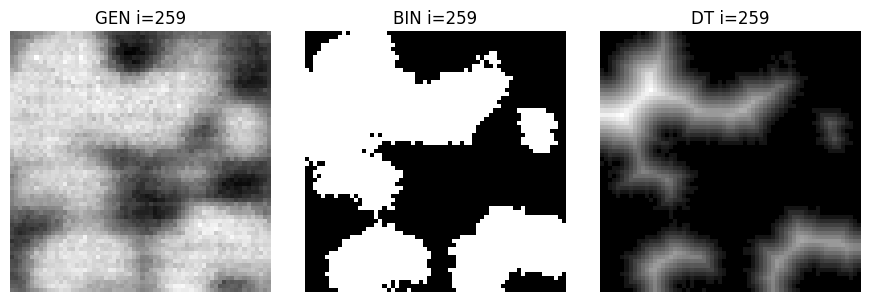

Empty PD detected at sample 322 | dim=1 | Skipping padding and saving debug image...
Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9622 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 274
Empty PD detected at sample 274 | dim=1 | Skipping padding and saving debug image...


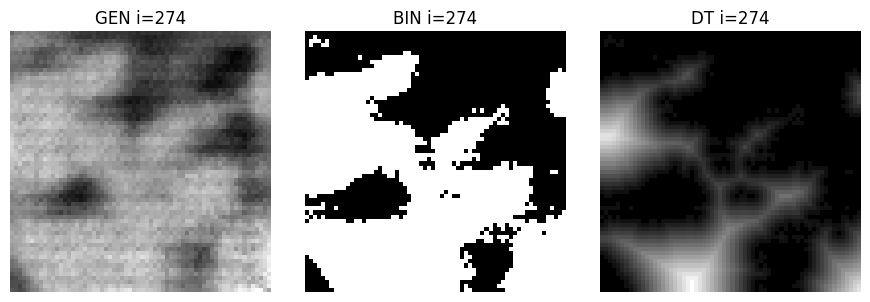

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9027 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 268
Empty PD detected at sample 268 | dim=1 | Skipping padding and saving debug image...


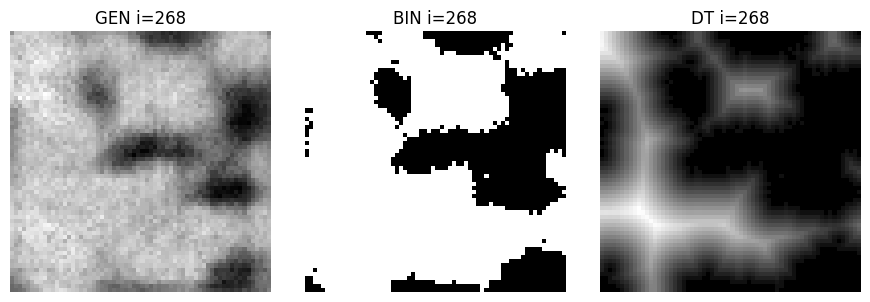

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[851/2000][0/1] D: -3.2691 G: 0.0775 T: 4.3283 W: 1.4412 Step: 851
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 44
Empty PD detected at sample 44 | dim=1 | Skipping padding and saving debug image...


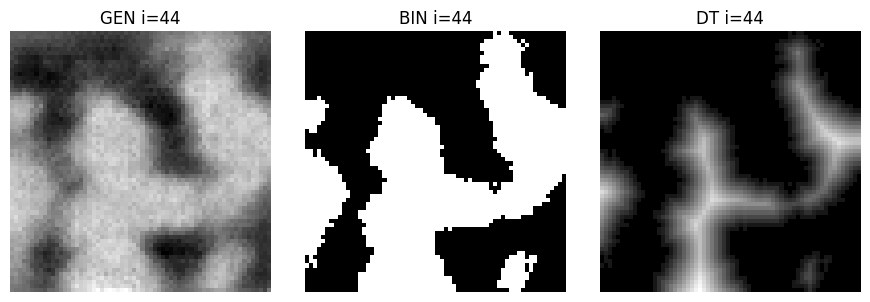

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.7784 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Empty PD detected at sample 139 | dim=1 | Skipping padding and saving debug image...
Sanity Check Plot random example for i = 163
Empty PD detected at sample 163 | dim=1 | Skipping padding and saving debug image...


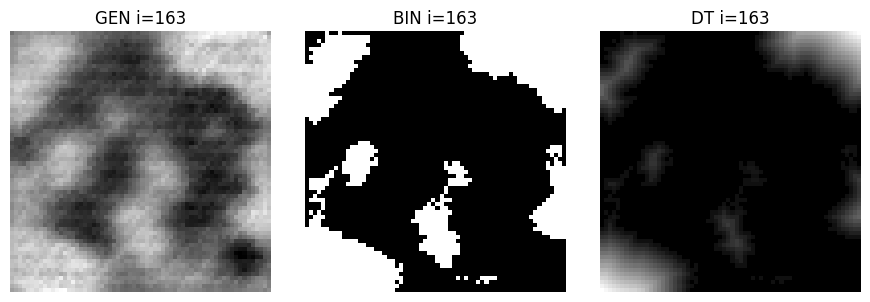

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8766 seconds
[861/2000][0/1] D: -3.3017 G: -0.0984 T: 4.3221 W: 1.1852 Step: 861
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 40
Empty PD detected at sample 40 | dim=1 | Skipping padding and saving debug image...


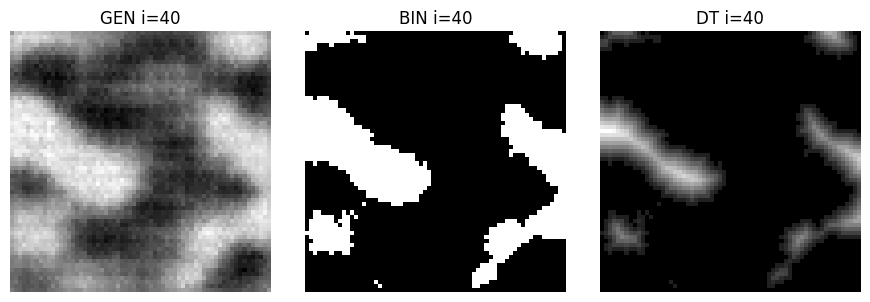

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8274 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 294
Empty PD detected at sample 294 | dim=1 | Skipping padding and saving debug image...


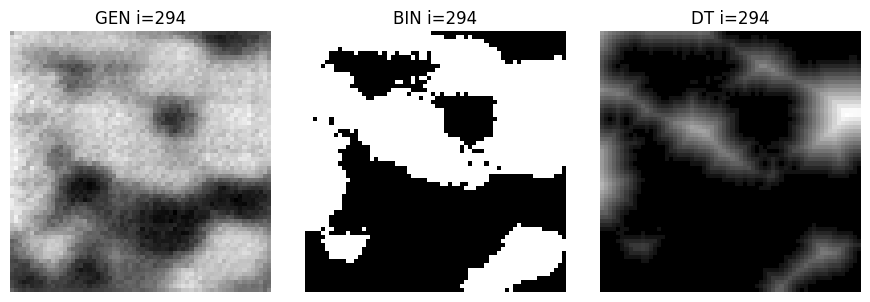

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.7832 seconds
[871/2000][0/1] D: -3.3129 G: 0.6748 T: 4.3129 W: 1.0996 Step: 871
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 293
Empty PD detected at sample 293 | dim=1 | Skipping padding and saving debug image...


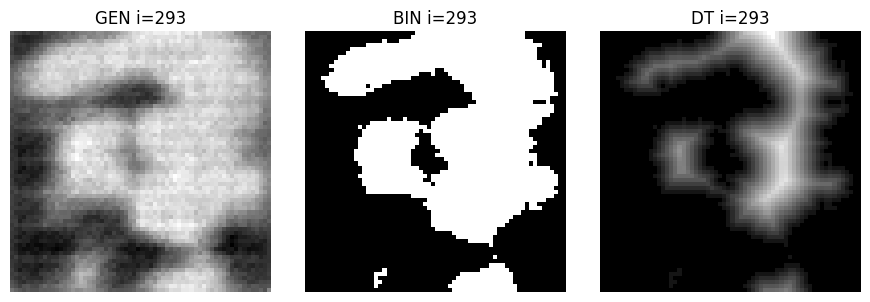

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8571 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 295
Empty PD detected at sample 295 | dim=1 | Skipping padding and saving debug image...


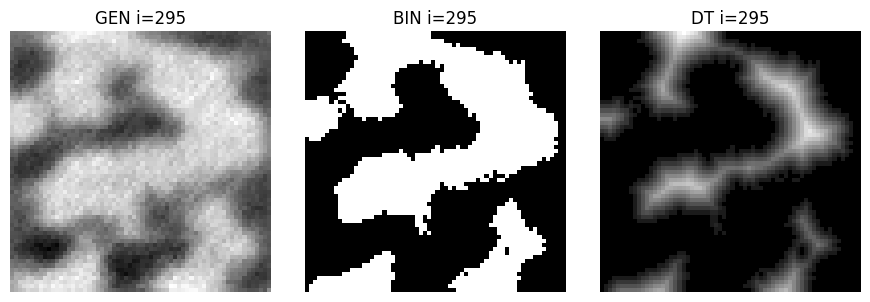

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8755 seconds
[881/2000][0/1] D: -3.3518 G: -0.0488 T: 4.3318 W: 1.3044 Step: 881
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 162
Empty PD detected at sample 162 | dim=1 | Skipping padding and saving debug image...


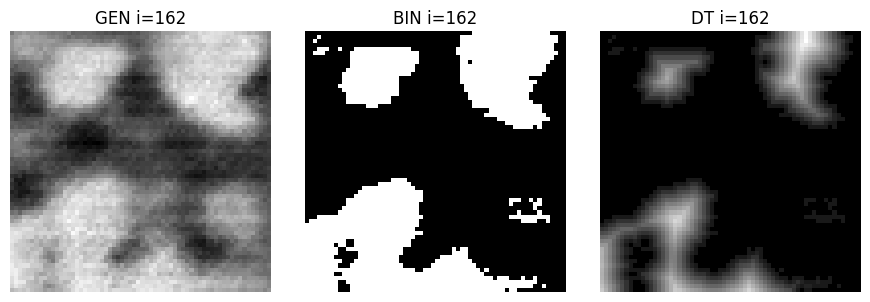

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8221 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 232
Empty PD detected at sample 232 | dim=1 | Skipping padding and saving debug image...


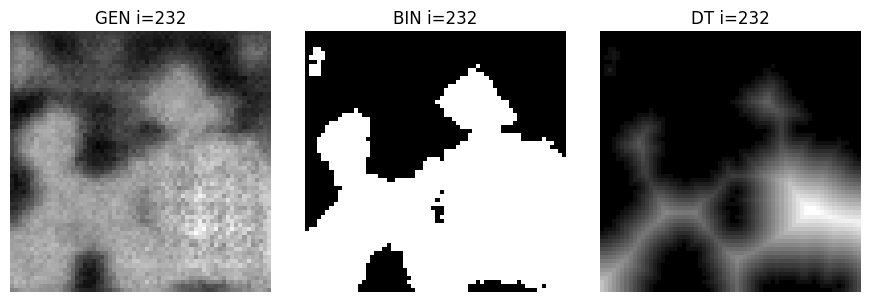

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9313 seconds
[891/2000][0/1] D: -3.3898 G: 0.5088 T: 4.3211 W: 1.1305 Step: 891
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 40
Empty PD detected at sample 40 | dim=1 | Skipping padding and saving debug image...


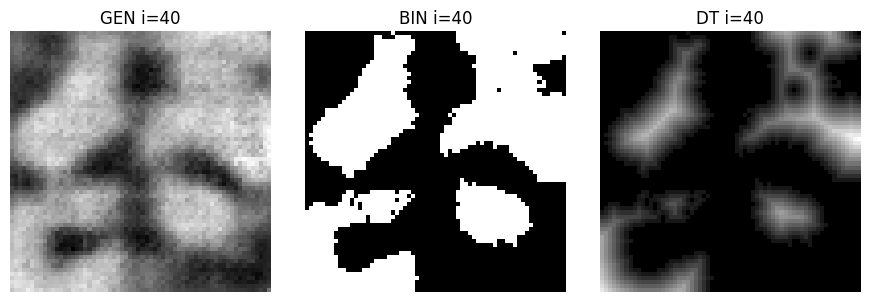

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9296 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 322
Empty PD detected at sample 322 | dim=1 | Skipping padding and saving debug image...


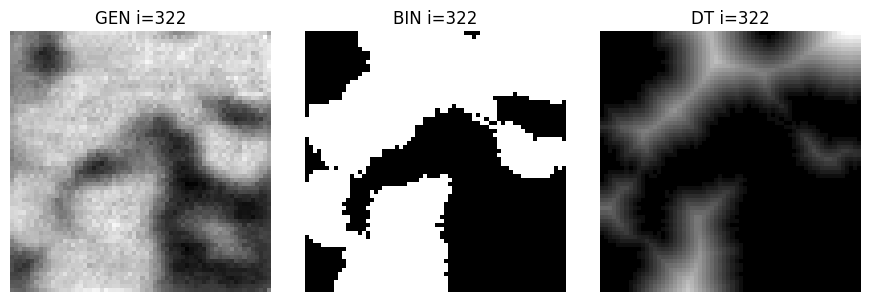

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8374 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 270
Empty PD detected at sample 270 | dim=1 | Skipping padding and saving debug image...


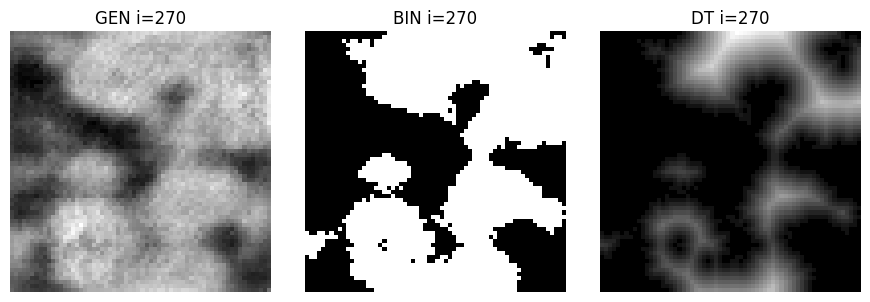

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[901/2000][0/1] D: -3.4375 G: 0.8858 T: 4.3202 W: 1.2404 Step: 901
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 6
Empty PD detected at sample 6 | dim=1 | Skipping padding and saving debug image...


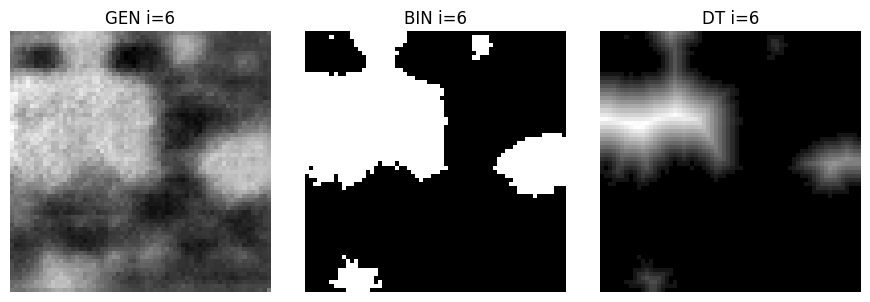

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8370 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 6
Empty PD detected at sample 6 | dim=1 | Skipping padding and saving debug image...


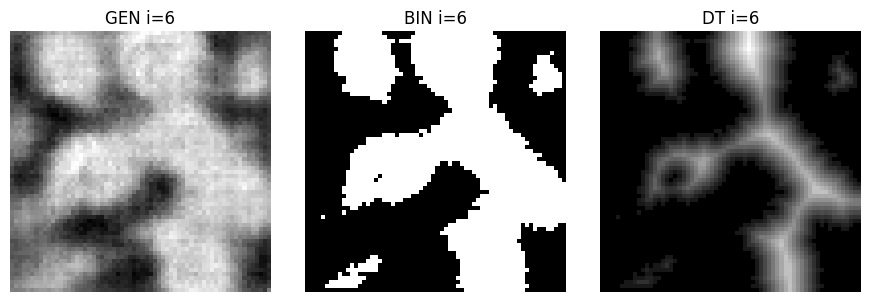

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8683 seconds
[911/2000][0/1] D: -3.4892 G: -0.9338 T: 4.3330 W: 1.3336 Step: 911
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 232
Empty PD detected at sample 232 | dim=1 | Skipping padding and saving debug image...


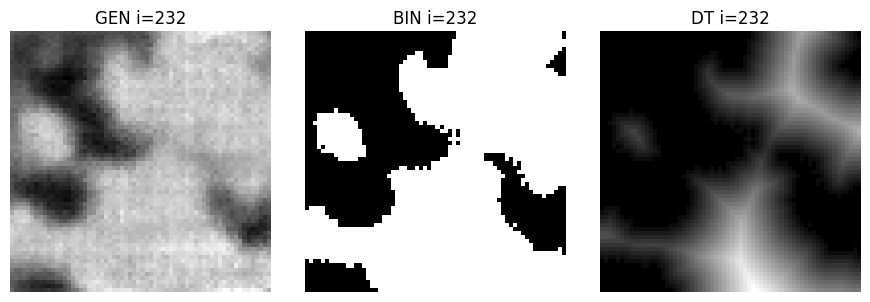

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.7974 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 128
Empty PD detected at sample 128 | dim=1 | Skipping padding and saving debug image...


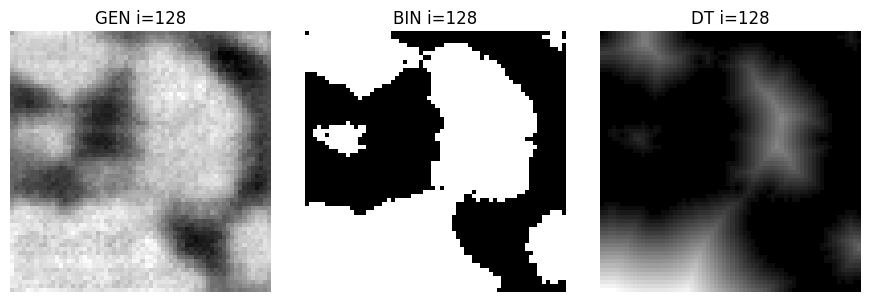

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.7852 seconds
[921/2000][0/1] D: -3.5038 G: 2.2915 T: 4.2967 W: 1.3005 Step: 921
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 323
Empty PD detected at sample 323 | dim=1 | Skipping padding and saving debug image...


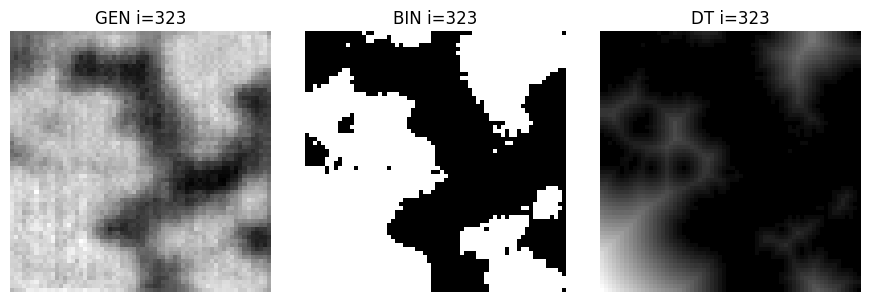

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8838 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 255
Empty PD detected at sample 255 | dim=1 | Skipping padding and saving debug image...


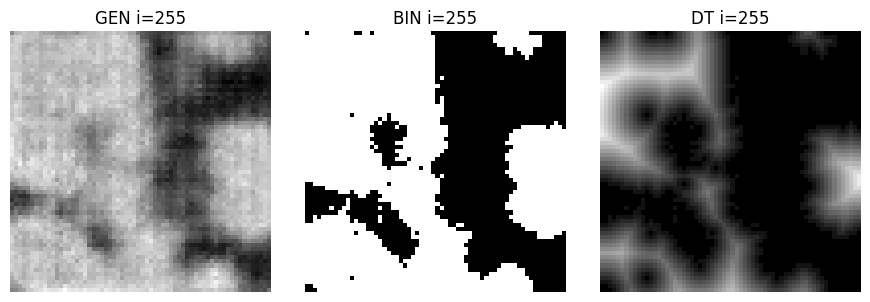

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 7.0631 seconds
[931/2000][0/1] D: -3.3322 G: -1.9090 T: 4.3757 W: 1.3619 Step: 931
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 233
Empty PD detected at sample 233 | dim=1 | Skipping padding and saving debug image...


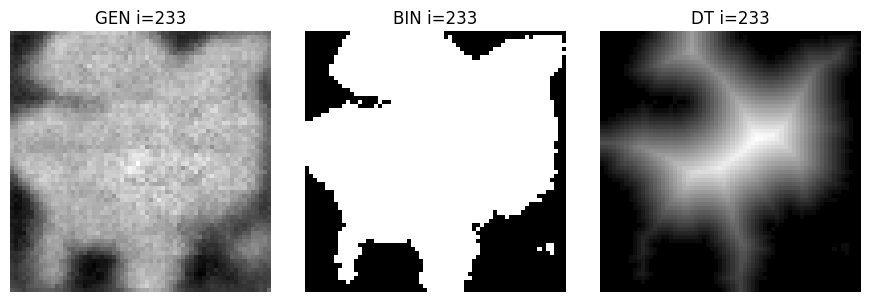

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8278 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 224
Empty PD detected at sample 224 | dim=1 | Skipping padding and saving debug image...


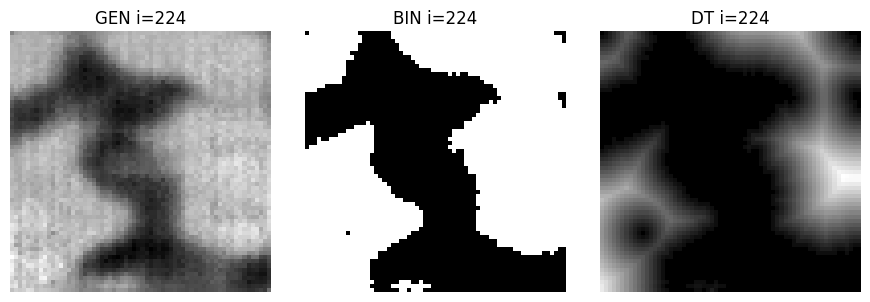

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.7639 seconds
[941/2000][0/1] D: -2.8841 G: 2.7029 T: 4.2916 W: 1.1731 Step: 941
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 92
Empty PD detected at sample 92 | dim=1 | Skipping padding and saving debug image...


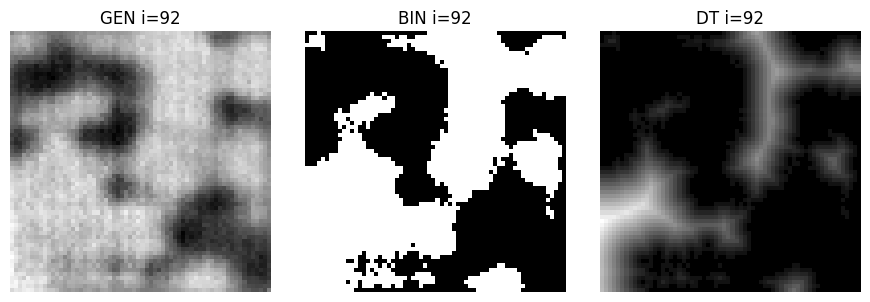

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.7691 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 27
Empty PD detected at sample 27 | dim=1 | Skipping padding and saving debug image...


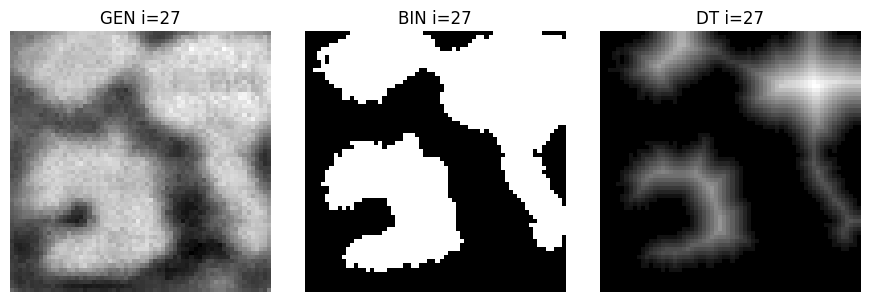

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8199 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 102
Empty PD detected at sample 102 | dim=1 | Skipping padding and saving debug image...


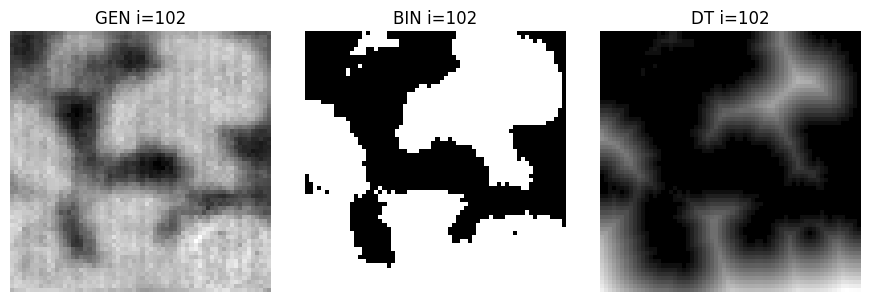

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[951/2000][0/1] D: -3.5169 G: 1.1476 T: 4.3287 W: 1.1071 Step: 951
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 175
Empty PD detected at sample 175 | dim=1 | Skipping padding and saving debug image...


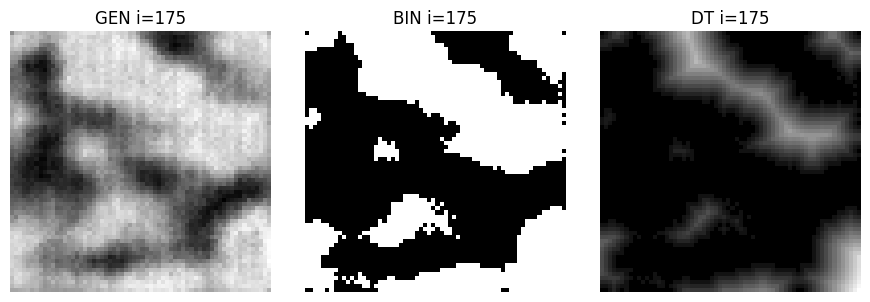

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.9957 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 240
Empty PD detected at sample 240 | dim=1 | Skipping padding and saving debug image...


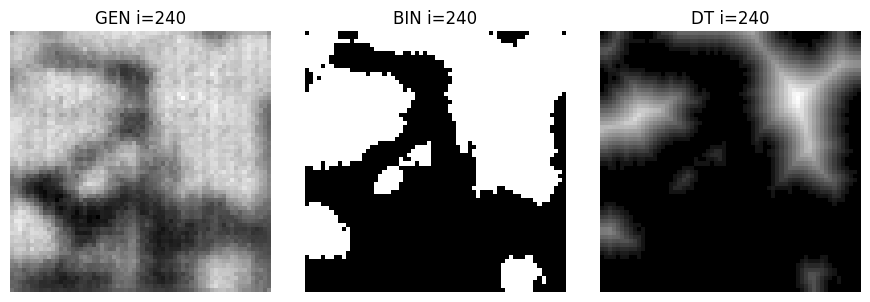

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8550 seconds
[961/2000][0/1] D: -3.6911 G: -0.6348 T: 4.3227 W: 1.3107 Step: 961
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 189
Empty PD detected at sample 189 | dim=1 | Skipping padding and saving debug image...


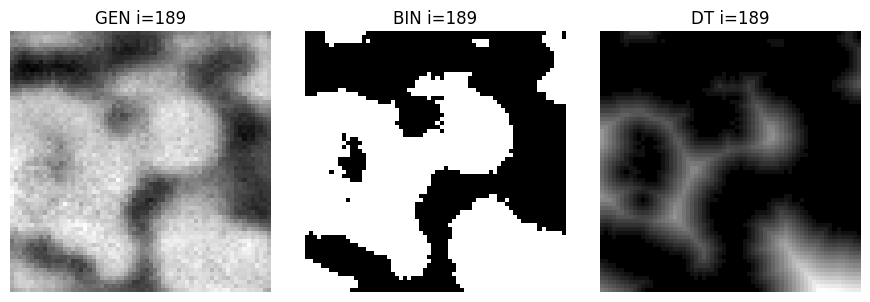

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.7909 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 34
Empty PD detected at sample 34 | dim=1 | Skipping padding and saving debug image...


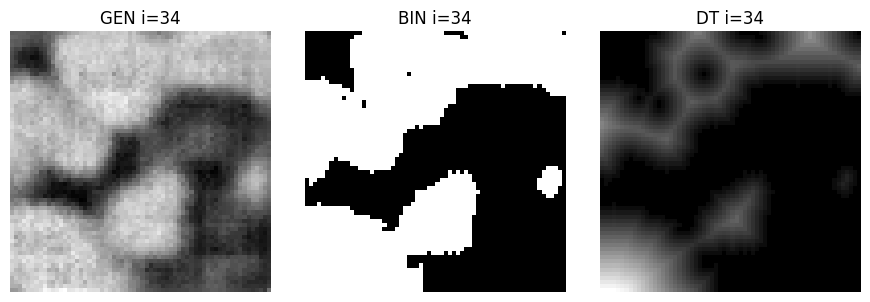

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.7608 seconds
[971/2000][0/1] D: -3.6710 G: 0.2055 T: 4.3199 W: 1.3730 Step: 971
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 96
Empty PD detected at sample 96 | dim=1 | Skipping padding and saving debug image...


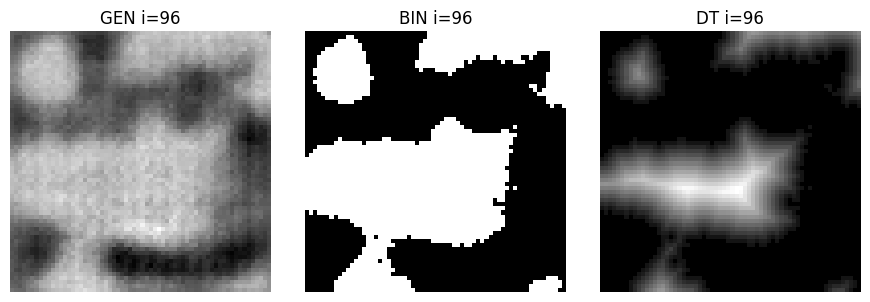

Empty PD detected at sample 294 | dim=1 | Skipping padding and saving debug image...
Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8830 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 210
Empty PD detected at sample 210 | dim=1 | Skipping padding and saving debug image...


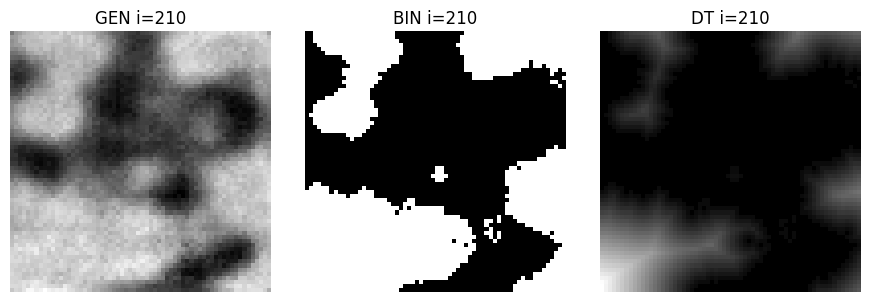

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.7779 seconds
[981/2000][0/1] D: -3.6772 G: 0.9035 T: 4.3208 W: 1.1579 Step: 981
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 82
Empty PD detected at sample 82 | dim=1 | Skipping padding and saving debug image...


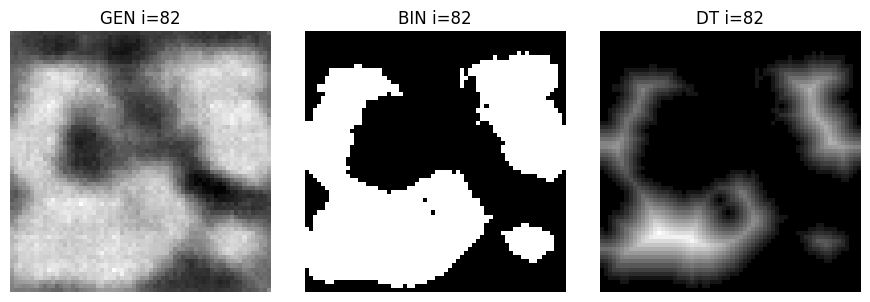

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8534 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 169
Empty PD detected at sample 169 | dim=1 | Skipping padding and saving debug image...


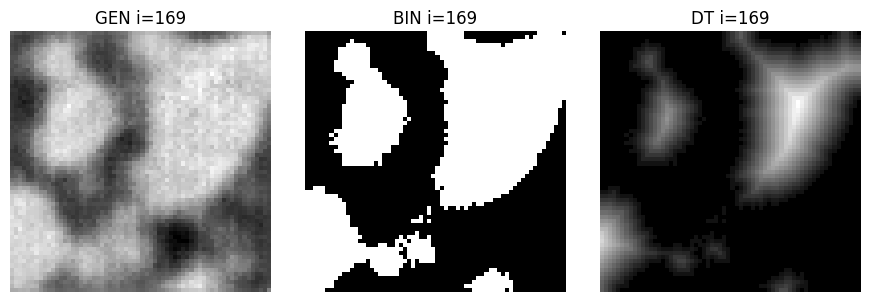

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.7795 seconds
[991/2000][0/1] D: -3.6536 G: 0.0109 T: 4.3258 W: 1.2620 Step: 991
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 42
Empty PD detected at sample 42 | dim=1 | Skipping padding and saving debug image...


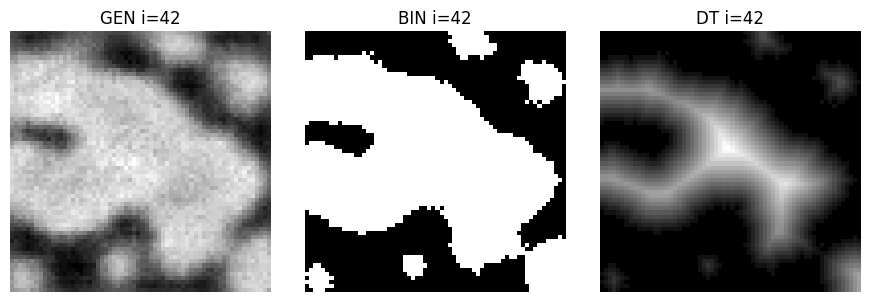

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8737 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 212
Empty PD detected at sample 212 | dim=1 | Skipping padding and saving debug image...


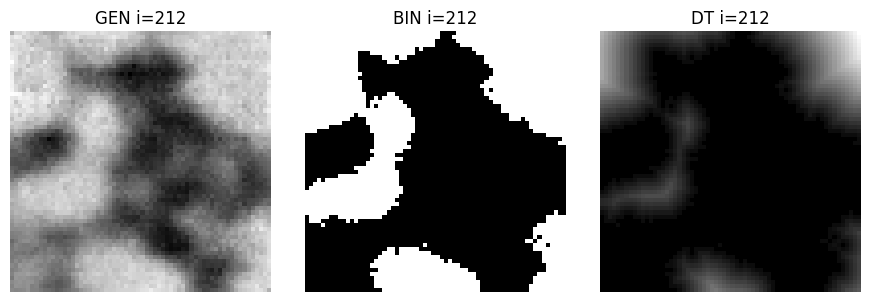

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8560 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 299
Empty PD detected at sample 299 | dim=1 | Skipping padding and saving debug image...


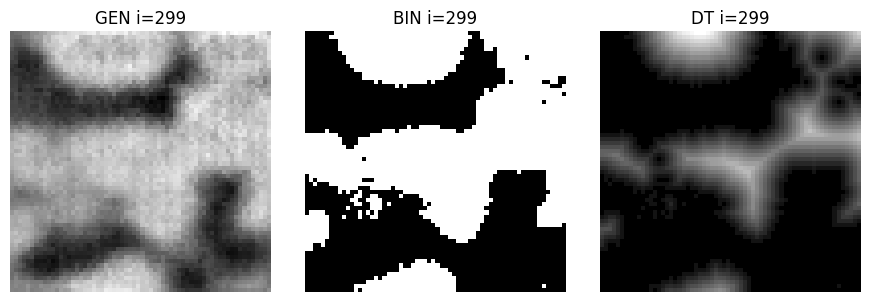

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[1001/2000][0/1] D: -3.6852 G: -0.0474 T: 4.3215 W: 1.1723 Step: 1001
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 61
Empty PD detected at sample 61 | dim=1 | Skipping padding and saving debug image...


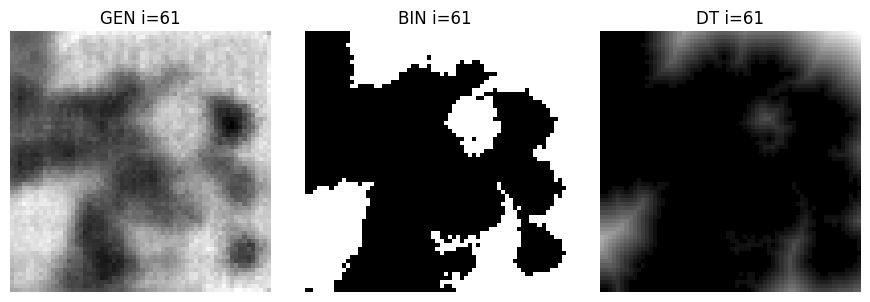

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8668 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 165
Empty PD detected at sample 165 | dim=1 | Skipping padding and saving debug image...


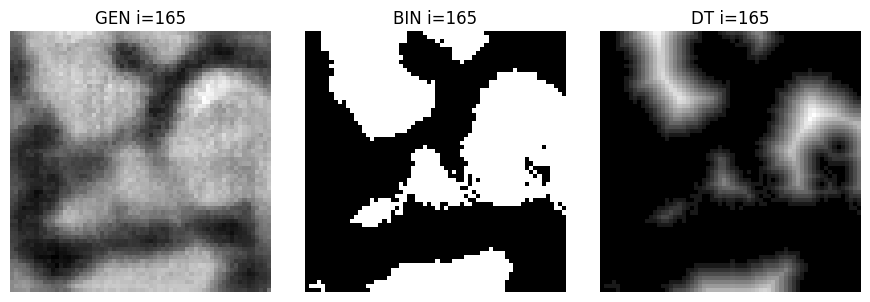

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8640 seconds
[1011/2000][0/1] D: -3.7620 G: 0.7521 T: 4.3141 W: 1.2276 Step: 1011
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 39
Empty PD detected at sample 39 | dim=1 | Skipping padding and saving debug image...


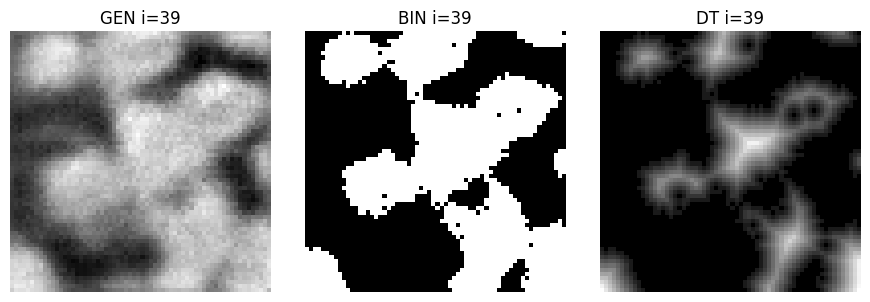

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8780 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 100
Empty PD detected at sample 100 | dim=1 | Skipping padding and saving debug image...


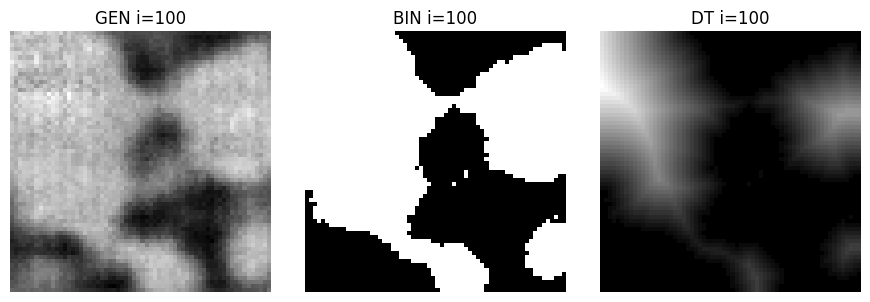

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.7884 seconds
[1021/2000][0/1] D: -3.7729 G: -0.6940 T: 4.3192 W: 1.1139 Step: 1021
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 291
Empty PD detected at sample 291 | dim=1 | Skipping padding and saving debug image...


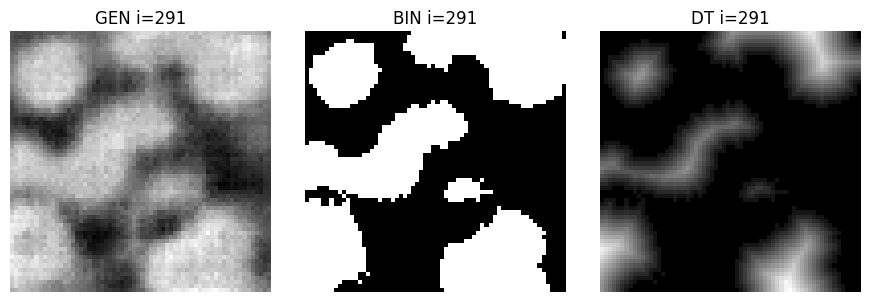

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.7490 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 69
Empty PD detected at sample 69 | dim=1 | Skipping padding and saving debug image...


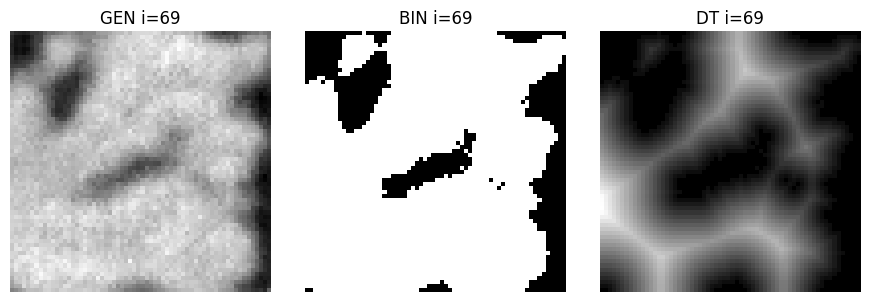

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8649 seconds
[1031/2000][0/1] D: -3.8129 G: 1.1955 T: 4.3127 W: 1.3376 Step: 1031
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 61
Empty PD detected at sample 61 | dim=1 | Skipping padding and saving debug image...


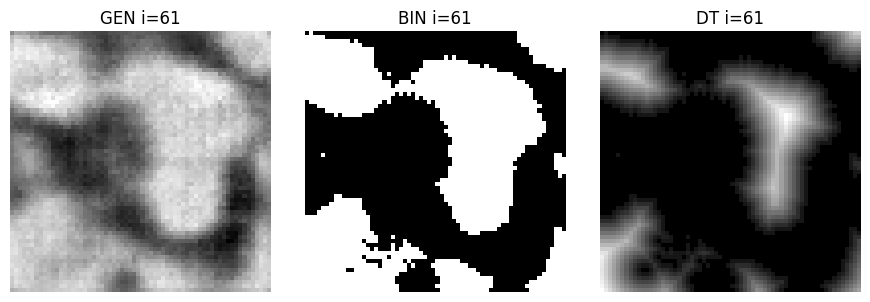

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.7822 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 250
Empty PD detected at sample 250 | dim=1 | Skipping padding and saving debug image...


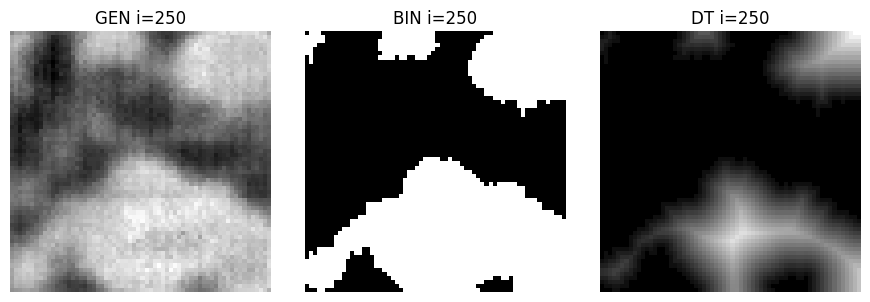

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8332 seconds
[1041/2000][0/1] D: -3.5857 G: -0.2042 T: 4.3194 W: 1.1126 Step: 1041
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 9
Empty PD detected at sample 9 | dim=1 | Skipping padding and saving debug image...


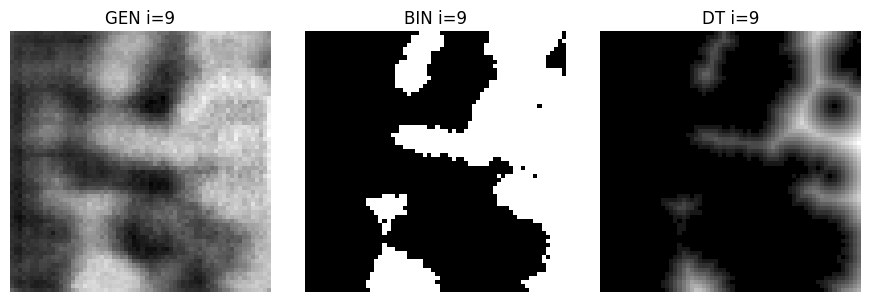

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8782 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 253
Empty PD detected at sample 253 | dim=1 | Skipping padding and saving debug image...


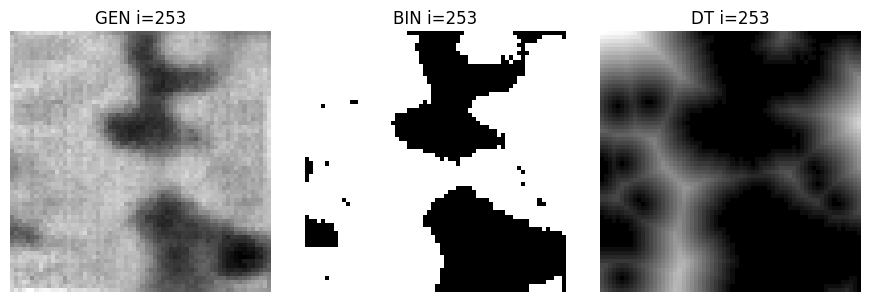

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8276 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 58
Empty PD detected at sample 58 | dim=1 | Skipping padding and saving debug image...


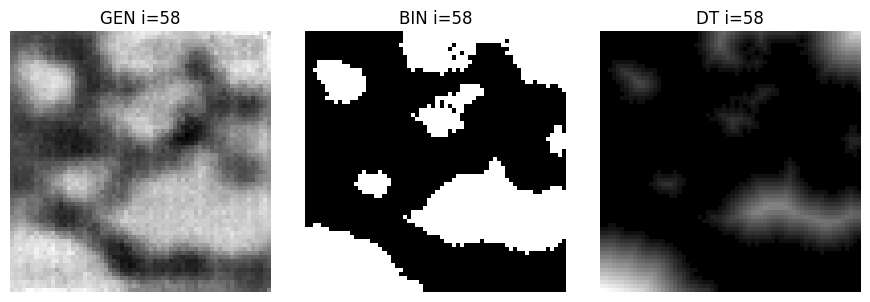

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[1051/2000][0/1] D: -3.7216 G: 0.6006 T: 4.3177 W: 1.3413 Step: 1051
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 223
Empty PD detected at sample 223 | dim=1 | Skipping padding and saving debug image...


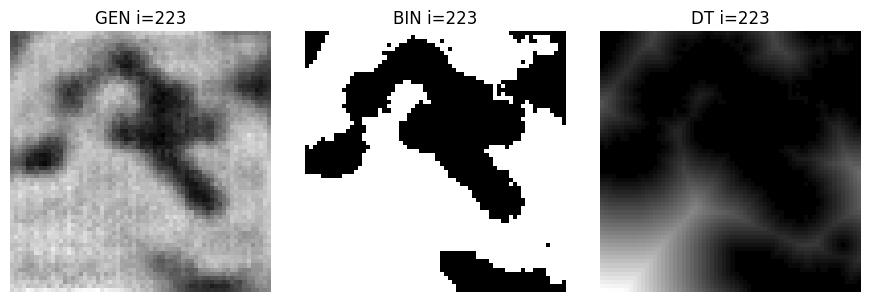

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8438 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 276
Empty PD detected at sample 276 | dim=1 | Skipping padding and saving debug image...


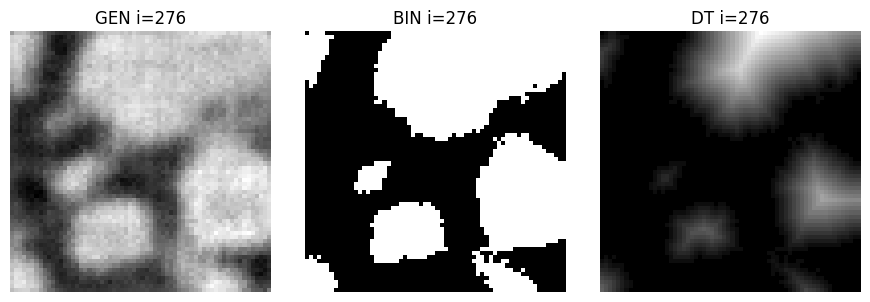

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8537 seconds
[1061/2000][0/1] D: -3.8442 G: 0.1844 T: 4.3230 W: 1.1869 Step: 1061
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 153
Empty PD detected at sample 153 | dim=1 | Skipping padding and saving debug image...


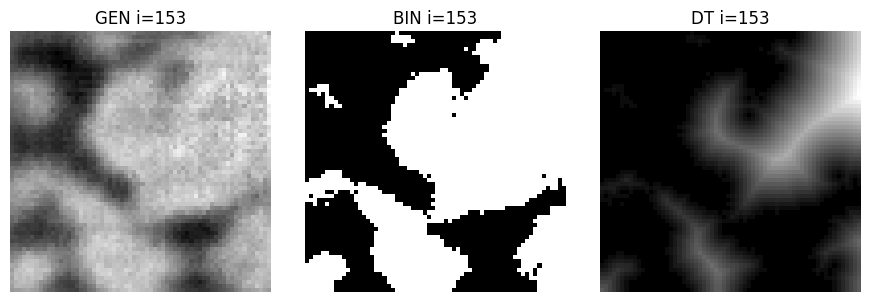

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8838 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 142
Empty PD detected at sample 142 | dim=1 | Skipping padding and saving debug image...


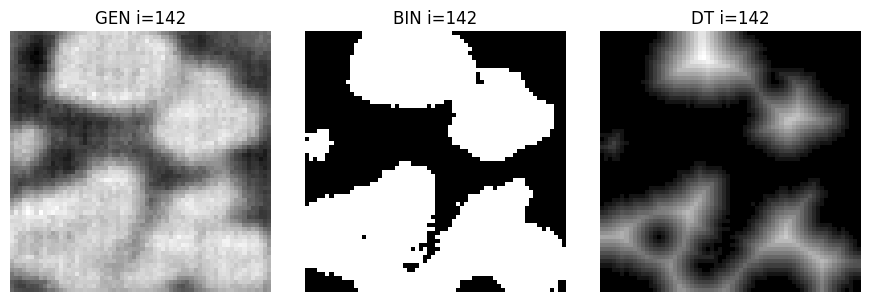

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 6.8774 seconds
[1071/2000][0/1] D: -3.9086 G: 0.4497 T: 4.3170 W: 1.2090 Step: 1071


In [ ]:
experiments = [
    # {"notebook": "Archpool-Copy1.py", "comment": "WGAN-GP default 324 (64x64, n=324)"},
    {"notebook": "Archpool-Copy2.py", "comment": "TOPOGAN 324 (64x64, n=324) water=median"},
    {"notebook": "Archpool-Copy3.py", "comment": "TOPOGAN 324 (64x64, n=324) water=mean, topo_weight=0.0005, rate=0.5"},
    {"notebook": "Archpool-Copy4.py", "comment": "TOPOGAN 324 (64x64, n=324) water=mean, topo_weight=0.005, rate=0.5"},
    # Add more as needed
]

for exp in experiments:
    notebook = exp["notebook"]
    comment = exp["comment"]
    print(f"\n🔥 Running {notebook} - {comment}")
    %cd "C:\TopoGAN-ECCV2020"
    get_ipython().run_line_magic('run', notebook)
    
    settings = return_settings()

    raw_data_path, pds_path = settings["Path"]["data_path"], settings["Path"]["pds_path"]
    if not os.path.exists(pds_path):
        print("Precomputing pds")  # PDs - Persistence Diagrams

        print(raw_data_path, "\n", pds_path)
        precompute_pds(raw_data_path, pds_path)
        print(f"✅ Completed {exp['notebook']}\n{'-'*50}")
        
    parser = Argparser(settings)
    general = return_general(0)
    G_arch = return_arch(2)  # DCGAN
    D_arch = return_arch(3)  # DCGAN
    data_params = return_data_settings(0)
    adv_params = return_advanced_params()

    print("TRAINING ON DATASET: ", settings["Path"]["data_path"])
    
    import os
    from datetime import datetime
    from pathlib import Path

    # Get the filename: YYYY-MM-DD_branchname.json
    date_str = datetime.now().strftime("%Y-%m-%d")
    branch_name = settings["Basic"]["branch_name"]
    filename = f"{date_str}_{branch_name}.json"

    # Full save path
    save_dir = Path(settings["Path"]["save_path"]) / branch_name
    os.makedirs(save_dir, exist_ok=True)
    save_file_path = os.path.join(save_dir, filename)

    # Assemble the full run config
    run_config = {
        #     "args": vars(parser),
        "settings": settings,
        "general": general,
        "generator_arch": G_arch,
        "discriminator_arch": D_arch,
        "data_params": data_params,
        "advanced_params": adv_params,
    }

    # Save to JSON
    with open(save_file_path, "w") as f:
        json.dump(run_config, f, indent=4)

    print(f"✅ Run configuration saved to: {save_file_path}")
    
    train()
    print(f"Training finished for {exp}")

# Plotting

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_persistence_diagram(
    mat, title="Persistence Diagram", show=True, save_path=None
):
    """
    Plot a persistence diagram given a matrix of birth-death pairs.

    Parameters:
        mat (np.ndarray): Array of shape (N, 2), where each row is (birth, death)
        title (str): Plot title
        show (bool): Whether to display the plot
        save_path (str or None): If given, saves the plot to this path
    """
    if mat.ndim != 2 or mat.shape[1] != 2:
        raise ValueError(
            "mat must be a 2D array with shape (N, 2), representing (birth, death) pairs."
        )

    births, deaths = mat[:, 0], mat[:, 1]

    plt.figure(figsize=(6, 6))
    plt.scatter(births, deaths, c="blue", alpha=0.6, edgecolors="k")
    max_val = max(np.max(births), np.max(deaths)) * 1.05
    plt.plot([0, max_val], [0, max_val], "r--", label="Diagonal (birth=death)")
    plt.xlabel("Birth")
    plt.ylabel("Death")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.axis("equal")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()


def plot_persistence_diagram_from_file(
    file_path, title="Persistence Diagram", show=True, save_path=None
):
    def read_matrix_binary(path, dtype="d"):
        file_in = open(path, "rb")
        dims = struct.unpack("I", file_in.read(4))[0]
        if dims == 0:
            return None
        shape = struct.unpack(str(dims) + "I", file_in.read(4 * dims))
        mat = struct.unpack(
            str(np.prod(shape)) + dtype,
            file_in.read(dlength_dict[dtype] * np.prod(shape)),
        )
        mat = np.reshape(mat, shape)
        return mat

    pd_matrix = read_matrix_binary(file_path)
    return plot_persistence_diagram(pd_matrix, title, show, save_path)

In [ ]:
# from pathlib import Path

# pds_path = Path("C:\TopoGAN-ECCV2020\Data\cremi\pds_64x64_downscaled_from_256")
# pd_names = [
#     "crop_00000.png.dat",
#     "crop_00001.png.dat",
#     "crop_00002.png.dat",
#     "crop_00003.png.dat",
# ]

# for name in pd_names:
#     path = pds_path / name
#     plot_persistence_diagram_from_file(path, title="PD_" + name)

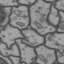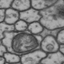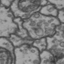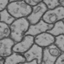

In [ ]:
%cd C:\TopoGAN-ECCV2020

In [ ]:
%run inference.ipynb

In [ ]:
from datetime import datetime
from pathlib import Path

experiment_name = "release_test_20250517_214006_64x64"
training_dataset_path = Path(r"C:\TopoGAN-ECCV2020\Data\cremi\64x64")
weights_path = Path(f"C:/TopoGAN-ECCV2020/Data/LOG/{experiment_name}/models")
generations_path = Path(f"C:/TopoGAN-ECCV2020/Data/generations/cremi/{experiment_name}")
step = 2000

# Get current datetime and format it as a string
current_time = datetime.now().strftime("%Y.%m.%d_%H.%M.%S")

# Add datetime to the end of the generations_path stem
new_name = f"{generations_path.stem}_{current_time}{generations_path.suffix}"
generations_path = generations_path.with_name(new_name)

gan_kwargs = {
    "general": general,
    "adv_params": adv_params,
    "G_arch": G_arch,
    "D_arch": D_arch,
}

generate_images(
    GAN,
    weights_path,
    generations_path,
    gan_kwargs=gan_kwargs,
    step=step,
    num_samples=1000,
    fix_with_topo=False,
)

os.chdir(HOME_DIR)
fid = compute_fid([str(generations_path), str(training_dataset_path)])
print("fid")
save_to_log(fid, experiment_name)

In [ ]:
os.chdir(HOME_DIR)

In [ ]:
compute_fid([str(generations_path), str(training_dataset_path)])

In [ ]:
compute_fid([str(generations_path), str(generations_path)])

# Experiment runner

In [ ]:
# import os
# import sys

# import numpy

# # Add OpenBLAS bin to the beginning of the PATH
# os.environ["PATH"] = r"C:\TopoGAN-ECCV2020\OpenBLAS\bin;" + os.environ.get("PATH", "")

# # # 1) register the folder that contains _persis_homo_optimal.pyd *and* any other DLLs it needs
# # os.add_dll_directory(r"C:\Users\MIKEC\PycharmProjects\topology\TopoGAN-ECCV2020\persis_lib_cpp")

# # 2) add the same folder to sys.path so Python can find the .pyd module by name
# # sys.path.insert(0, r"C:\Users\MIKEC\PycharmProjects\topology\TopoGAN-ECCV2020\persis_lib_cpp")

# # python library compile from cpp
# sys.path.insert(0, "./persis_lib_cpp")
# import os

# from persis_homo_optimal import *

# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Добавьте это в первой ячейке
# TOPOLOGICAL_GAN = True
# START_TOPO_LOSS_FROM_EPOCH = -1

# %run Archpool.ipynb
# %run Argparser.ipynb
# %run GAN.ipynb


# def precompute_pds(dir_in, dir_out):
#     adv_params = return_advanced_params()
#     et = Edges_(adv_params, False)
#     FileIO.compute_pd_save(dir_in, dir_out, "png", adv_params, 1, True)


# %run experiment_engine.ipynb
# %run inference.ipynb

# %run Archpool.ipynb
# %run Argparser.ipynb
# %run GAN.ipynb
# %run fid/inception.ipynb
# %run fid/fid_score.ipynb

# os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# HOME_DIR = "C:\TopoGAN-ECCV2020"

In [ ]:
# from pathlib import Path

# experiment_names = [
#     "release_test_20250514_165411_64x64_downscaled_from_128_n350",
#     # Add more here
# ]

# # Define only the root (everything else will be extracted from JSON)
# base_path = Path(r"C:/TopoGAN-ECCV2020/Data")

# # run_experiments_from_logs(
# #     experiment_names=experiment_names,
# #     GAN=GAN,
# #     generate_images=generate_images,
# #     compute_fid=compute_fid,
# #     HOME_DIR=HOME_DIR,
# #     base_log_path=base_path / "LOG",
# #     base_generation_path_root=base_path / "generations",
# #     num_samples=100,
# #     fix_with_topo=False,
# # )

# run_experiments_from_logs(
#     experiment_names=experiment_names,
#     GAN=GAN,
#     generate_images=generate_images,
#     compute_fid=compute_fid,
#     HOME_DIR=HOME_DIR,
#     base_log_path=base_path / "LOG",
#     base_generation_path_root=base_path / "generations",
#     base_data_path=base_path,
#     step=1950,
#     num_samples=100,
#     fix_with_topo=False,
# )